# Regresión Lineal Múltiple
## Factores socioeconómicos y demográficos asociados al crecimiento de la densidad comercial municipal en México, 2020–2025

### FASE 1 — Configuración y carga de datos

En esta primera fase se prepara el entorno de trabajo, se carga la base maestra construida y validada previamente, y se verifica que las variables necesarias para la regresión lineal múltiple estén disponibles y no presenten problemas de estructura, duplicados o valores faltantes.

La unidad de análisis es el municipio y la base contiene información de corte transversal para 2,440 municipios comparables entre 2020 y 2025.

El modelo múltiple base utilizará como variable dependiente el crecimiento porcentual acumulado de la densidad comercial minorista entre 2020 y 2025, y como variables explicativas la razón de dependencia, el grado promedio de escolaridad, la tasa de informalidad y el porcentaje de población en situación de pobreza.

In [1]:
# ============================================================
# FASE 1 — CONFIGURACIÓN Y CARGA DE DATOS
# 1.1 Importación de librerías
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats

# Configuración de visualización de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ============================================================
# 1.2 Identificación automática de la raíz del proyecto
# ============================================================

ruta_actual = Path.cwd()

if ruta_actual.name.lower() == "notebooks":
    PROJECT_ROOT = ruta_actual.parent
else:
    PROJECT_ROOT = ruta_actual

print("Directorio actual:")
print(ruta_actual)

print("\nRaíz del proyecto:")
print(PROJECT_ROOT)


Directorio actual:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\notebooks

Raíz del proyecto:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico


In [3]:
# ============================================================
# 1.3 Localización de la base maestra
# ============================================================

candidatos = [
    PROJECT_ROOT / "data" / "processed" / "base_maestra_econometrica.csv",
    PROJECT_ROOT / "data" / "raw" / "base_maestra_econometrica.csv",
    PROJECT_ROOT / "base_maestra_econometrica.csv",
]

DATA_PATH = None

for ruta in candidatos:
    if ruta.exists():
        DATA_PATH = ruta
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró 'base_maestra_econometrica.csv'. "
        "Revisa que el archivo esté en data/processed/, "
        "data/raw/ o en la raíz del proyecto."
    )

print("Base maestra localizada correctamente:")
print(DATA_PATH)

Base maestra localizada correctamente:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\data\processed\base_maestra_econometrica.csv


In [4]:
# ============================================================
# 1.4 Carga de la base maestra
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    dtype={"CVEGEO": "string"}
)

print("Base cargada correctamente.")
print(f"Observaciones: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

display(df.head())

Base cargada correctamente.
Observaciones: 2,440
Variables: 15


,CVEGEO,entidad,municipio,EST_RETAIL_2020,EST_RETAIL_2025,POB_2020,POB_2025,DENSIDAD_RETAIL_2020,DENSIDAD_RETAIL_2025,CREC_DENSIDAD_RETAIL_2020_2025,CREC_LOG_DENSIDAD_RETAIL_2020_2025,RAZ_DEP_2020,GRAPROES_2020,TASA_INFORMALIDAD_2020,POBREZA_2020
0,01001,AGUASCALIENTES,Aguascalientes,16577,18552,968960,1029221,17.1080,18.0253,5.3615,5.2227,48.8200,10.8400,42.5954,23.6823
1,01002,AGUASCALIENTES,Asientos,412,579,52700,57713,7.8178,10.0324,28.3271,24.9412,62.8000,8.5400,72.7677,40.1319
2,01003,AGUASCALIENTES,Calvillo,940,1062,59333,60886,15.8428,17.4424,10.0970,9.6192,63.3500,8.0500,62.8550,45.7559
3,01004,AGUASCALIENTES,Cosío,170,256,17369,18719,9.7876,13.6759,39.7279,33.4527,60.1300,9.0800,55.5494,37.0392
4,01005,AGUASCALIENTES,Jesús María,1753,2088,132642,141363,13.2160,14.7705,11.7619,11.1201,54.2000,10.2200,49.6232,26.3418


In [5]:
# ============================================================
# 1.5 Definición de variables para la regresión múltiple
# ============================================================

Y = "CREC_DENSIDAD_RETAIL_2020_2025"

X = [
    "RAZ_DEP_2020",
    "GRAPROES_2020",
    "TASA_INFORMALIDAD_2020",
    "POBREZA_2020"
]

variables_modelo = [Y] + X

print("Variable dependiente:")
print(f"Y  = {Y}")

print("\nVariables explicativas:")
for i, variable in enumerate(X, start=1):
    print(f"X{i} = {variable}")

Variable dependiente:
Y  = CREC_DENSIDAD_RETAIL_2020_2025

Variables explicativas:
X1 = RAZ_DEP_2020
X2 = GRAPROES_2020
X3 = TASA_INFORMALIDAD_2020
X4 = POBREZA_2020


In [6]:
# ============================================================
# 1.6 Auditoría de las variables del modelo
# ============================================================

print("=" * 70)
print("AUDITORÍA DE LA BASE PARA REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dimensiones de la base
# ------------------------------------------------------------

print(f"\nObservaciones totales: {df.shape[0]:,}")
print(f"Variables totales: {df.shape[1]}")

# ------------------------------------------------------------
# 2. Verificación de columnas requeridas
# ------------------------------------------------------------

columnas_faltantes = [
    variable for variable in variables_modelo
    if variable not in df.columns
]

if columnas_faltantes:
    print("\n⚠ Variables faltantes:")
    print(columnas_faltantes)
else:
    print("\n✓ Todas las variables necesarias están disponibles.")

# ------------------------------------------------------------
# 3. Duplicados en CVEGEO
# ------------------------------------------------------------

duplicados_cvegeo = df["CVEGEO"].duplicated().sum()

print(f"\nDuplicados en CVEGEO: {duplicados_cvegeo}")

# ------------------------------------------------------------
# 4. Valores faltantes
# ------------------------------------------------------------

nulos = df[variables_modelo].isna().sum()

print("\nValores faltantes:")
display(nulos.to_frame(name="Nulos"))

# ------------------------------------------------------------
# 5. Valores infinitos
# ------------------------------------------------------------

variables_numericas = df[variables_modelo].select_dtypes(include=np.number)

infinitos = np.isinf(variables_numericas).sum()

print("\nValores infinitos:")
display(infinitos.to_frame(name="Infinitos"))

# ------------------------------------------------------------
# 6. Tipos de datos
# ------------------------------------------------------------

print("\nTipos de datos:")
display(df[variables_modelo].dtypes.to_frame(name="Tipo"))

# ------------------------------------------------------------
# 7. Resultado general
# ------------------------------------------------------------

if (
    len(columnas_faltantes) == 0
    and duplicados_cvegeo == 0
    and nulos.sum() == 0
    and infinitos.sum() == 0
):
    print("\n✓ La base cumple las condiciones iniciales para el modelado múltiple.")
else:
    print("\n⚠ Se detectaron elementos que deben revisarse antes de estimar el modelo.")

AUDITORÍA DE LA BASE PARA REGRESIÓN LINEAL MÚLTIPLE

Observaciones totales: 2,440
Variables totales: 15

✓ Todas las variables necesarias están disponibles.

Duplicados en CVEGEO: 0

Valores faltantes:


,Nulos
CREC_DENSIDAD_RETAIL_2020_2025,0
RAZ_DEP_2020,0
GRAPROES_2020,0
TASA_INFORMALIDAD_2020,0
POBREZA_2020,0



Valores infinitos:


,Infinitos
CREC_DENSIDAD_RETAIL_2020_2025,0
RAZ_DEP_2020,0
GRAPROES_2020,0
TASA_INFORMALIDAD_2020,0
POBREZA_2020,0



Tipos de datos:


,Tipo
CREC_DENSIDAD_RETAIL_2020_2025,float64
RAZ_DEP_2020,float64
GRAPROES_2020,float64
TASA_INFORMALIDAD_2020,float64
POBREZA_2020,float64



✓ La base cumple las condiciones iniciales para el modelado múltiple.


In [7]:
# ============================================================
# 1.7 Construcción de la base analítica
# ============================================================

columnas_identificacion = [
    "CVEGEO",
    "entidad",
    "municipio"
]

df_modelo = df[
    columnas_identificacion + variables_modelo
].copy()

print("Base analítica creada correctamente.")
print(f"Observaciones: {df_modelo.shape[0]:,}")
print(f"Variables: {df_modelo.shape[1]}")

display(df_modelo.head())

Base analítica creada correctamente.
Observaciones: 2,440
Variables: 8


,CVEGEO,entidad,municipio,CREC_DENSIDAD_RETAIL_2020_2025,RAZ_DEP_2020,GRAPROES_2020,TASA_INFORMALIDAD_2020,POBREZA_2020
0,01001,AGUASCALIENTES,Aguascalientes,5.3615,48.8200,10.8400,42.5954,23.6823
1,01002,AGUASCALIENTES,Asientos,28.3271,62.8000,8.5400,72.7677,40.1319
2,01003,AGUASCALIENTES,Calvillo,10.0970,63.3500,8.0500,62.8550,45.7559
3,01004,AGUASCALIENTES,Cosío,39.7279,60.1300,9.0800,55.5494,37.0392
4,01005,AGUASCALIENTES,Jesús María,11.7619,54.2000,10.2200,49.6232,26.3418


In [8]:
# ============================================================
# 1.8 Verificación final de la muestra de modelado
# ============================================================

n_total = len(df_modelo)
n_completos = df_modelo[variables_modelo].dropna().shape[0]

print(f"Municipios en la base analítica: {n_total:,}")
print(f"Municipios con información completa para el modelo: {n_completos:,}")
print(f"Municipios excluidos por información faltante: {n_total - n_completos:,}")

if n_total == n_completos:
    print("\n✓ La regresión múltiple podrá utilizar la muestra completa.")

Municipios en la base analítica: 2,440
Municipios con información completa para el modelo: 2,440
Municipios excluidos por información faltante: 0

✓ La regresión múltiple podrá utilizar la muestra completa.


### Cierre de la Fase 1

La base maestra fue cargada correctamente y se definieron las variables que integrarán la especificación inicial de regresión lineal múltiple.

Antes del modelado se verificó la estructura de la información, la unicidad de la clave municipal y la presencia de valores faltantes o infinitos en las variables seleccionadas. También se construyó una base analítica independiente para trabajar únicamente con las variables necesarias para esta etapa, sin modificar la base maestra original.

Con estas verificaciones se establece la muestra que será utilizada en las siguientes fases del análisis.

# FASE 2 — Definición y especificación econométrica del modelo múltiple

El objetivo de esta fase es establecer formalmente la regresión lineal múltiple que se utilizará para analizar la relación conjunta entre las características municipales seleccionadas y el crecimiento de la densidad comercial minorista entre 2020 y 2025.

A diferencia de las regresiones lineales simples, en las que cada variable explicativa se analizó por separado, el modelo múltiple permitirá estimar la asociación de cada variable con el crecimiento comercial mientras las demás variables incluidas en la especificación se mantienen constantes.

El propósito no es establecer relaciones causales, sino evaluar asociaciones parciales entre las características demográficas y socioeconómicas de los municipios y la evolución de su densidad comercial.

## 2.1. Especificación del modelo

La especificación inicial de regresión lineal múltiple es:

\[
Y_i =
\beta_0
+\beta_1 X_{1i}
+\beta_2 X_{2i}
+\beta_3 X_{3i}
+\beta_4 X_{4i}
+\varepsilon_i
\]

Aplicada a las variables del proyecto:

\[
CREC\_DENSIDAD_i =
\beta_0
+\beta_1 RAZ\_DEP_i
+\beta_2 GRAPROES_i
+\beta_3 INFORMALIDAD_i
+\beta_4 POBREZA_i
+\varepsilon_i
\]

donde:

- \(CREC\_DENSIDAD_i\) representa el crecimiento porcentual acumulado de la densidad comercial minorista del municipio \(i\) entre 2020 y 2025.
- \(RAZ\_DEP_i\) corresponde a la razón de dependencia observada en 2020.
- \(GRAPROES_i\) representa el grado promedio de escolaridad en 2020.
- \(INFORMALIDAD_i\) corresponde a la tasa de informalidad laboral en 2020.
- \(POBREZA_i\) representa el porcentaje de población en situación de pobreza en 2020.
- \(\beta_0\) es el intercepto del modelo.
- \(\beta_1,\ldots,\beta_4\) son los coeficientes parciales de regresión.
- \(\varepsilon_i\) representa los factores no observados que afectan el crecimiento comercial y que no están incluidos explícitamente en el modelo.

## 2.2. Interpretación de los coeficientes IMPORTANTE

Los coeficientes de la regresión múltiple se interpretan como asociaciones parciales. Esto significa que el coeficiente de cada variable representa su relación con el crecimiento de la densidad comercial después de considerar simultáneamente las demás variables incluidas en el modelo.

Por ejemplo, \(\beta_4\), correspondiente a pobreza, indicará el cambio promedio asociado en el crecimiento porcentual de la densidad comercial ante un incremento de un punto porcentual en pobreza, manteniendo constantes la razón de dependencia, la escolaridad y la informalidad.

De manera equivalente, el coeficiente de escolaridad permitirá evaluar su relación con el crecimiento comercial entre municipios comparables en términos de razón de dependencia, informalidad y pobreza.

Esta interpretación constituye una diferencia importante respecto a las regresiones simples desarrolladas previamente, debido a que ahora cada coeficiente refleja la información adicional que aporta una variable después de controlar estadísticamente por las demás variables incluidas en la especificación.

## 2.3. Hipótesis global del modelo

La significancia conjunta de las variables explicativas se evaluará posteriormente mediante la prueba \(F\).

La hipótesis nula establece que todas las pendientes son simultáneamente iguales a cero:

\[
H_0:
\beta_1=
\beta_2=
\beta_3=
\beta_4=0
\]

La hipótesis alternativa establece que al menos uno de los coeficientes es distinto de cero:

\[
H_1:
\exists\,\beta_j \neq 0
\]

Si el valor-p asociado a la prueba \(F\) es inferior al nivel de significancia establecido, se rechazará la hipótesis nula y se concluirá que el conjunto de variables explicativas aporta información estadísticamente significativa sobre la variabilidad del crecimiento de la densidad comercial.

## 2.4. Hipótesis individuales de los coeficientes

Además de evaluar el modelo en conjunto, se analizará individualmente cada coeficiente mediante pruebas \(t\).

Para cada variable explicativa \(X_j\):

\[
H_0:\beta_j=0
\]

frente a:

\[
H_1:\beta_j\neq0
\]

Se utilizará inicialmente un nivel de significancia de:

\[
\alpha=0.05
\]

Un valor-p inferior a 0.05 proporcionará evidencia estadística para rechazar la hipótesis nula correspondiente.

La significancia estadística se interpretará conjuntamente con la magnitud y dirección del coeficiente, sus intervalos de confianza y la capacidad explicativa general del modelo. Una variable estadísticamente significativa no necesariamente implica una contribución económicamente grande ni una relación causal.

## 2.5. Referencia empírica previa Este apartado tiene mucho valor porque conecta la primera y la segunda entrega.

Las regresiones lineales simples desarrolladas previamente proporcionan un punto de referencia para evaluar los cambios que puedan producirse en la especificación múltiple.

En los modelos simples se observaron los siguientes patrones:

- razón de dependencia: asociación prácticamente nula y no significativa;
- escolaridad: asociación negativa y estadísticamente significativa;
- informalidad: asociación positiva y estadísticamente significativa;
- pobreza: asociación positiva y estadísticamente significativa.

Estos resultados no se imponen al modelo múltiple. Al incorporar las variables simultáneamente, los coeficientes pueden modificar su magnitud, significancia e incluso su signo debido a la relación existente entre las propias variables explicativas.

La comparación entre los resultados simples y múltiples permitirá identificar qué variables conservan una asociación propia con el crecimiento comercial una vez consideradas las demás características municipales.

In [10]:
# ============================================================
# FASE 2 — DEFINICIÓN DEL MODELO
# 2.6 Especificación de la fórmula econométrica
# ============================================================

formula_modelo = (
    "CREC_DENSIDAD_RETAIL_2020_2025 ~ "
    "RAZ_DEP_2020 + "
    "GRAPROES_2020 + "
    "TASA_INFORMALIDAD_2020 + "
    "POBREZA_2020"
)

print("Especificación del modelo múltiple:")
print(formula_modelo)

Especificación del modelo múltiple:
CREC_DENSIDAD_RETAIL_2020_2025 ~ RAZ_DEP_2020 + GRAPROES_2020 + TASA_INFORMALIDAD_2020 + POBREZA_2020


In [11]:
# ============================================================
# 2.7 Tabla conceptual de las variables del modelo
# ============================================================

tabla_variables = pd.DataFrame({
    "Símbolo": [
        "Y",
        "X1",
        "X2",
        "X3",
        "X4"
    ],
    "Variable": [
        "CREC_DENSIDAD_RETAIL_2020_2025",
        "RAZ_DEP_2020",
        "GRAPROES_2020",
        "TASA_INFORMALIDAD_2020",
        "POBREZA_2020"
    ],
    "Dimensión": [
        "Comercial",
        "Demográfica",
        "Educativa",
        "Laboral",
        "Socioeconómica"
    ],
    "Rol": [
        "Dependiente",
        "Explicativa",
        "Explicativa",
        "Explicativa",
        "Explicativa"
    ]
})

display(tabla_variables)

,Símbolo,Variable,Dimensión,Rol
0,Y,CREC_DENSIDAD_RETAIL_2020_2025,Comercial,Dependiente
1,X1,RAZ_DEP_2020,Demográfica,Explicativa
2,X2,GRAPROES_2020,Educativa,Explicativa
3,X3,TASA_INFORMALIDAD_2020,Laboral,Explicativa
4,X4,POBREZA_2020,Socioeconómica,Explicativa


## 2.8. Alcance de la interpretación

La estimación se realiza con datos municipales de corte transversal. Por esta razón, los coeficientes se interpretarán como asociaciones parciales condicionadas a las demás variables incluidas en el modelo.

El análisis no permite establecer causalidad de manera automática. Pueden existir factores económicos, territoriales, institucionales o comerciales no incorporados en la especificación que estén relacionados tanto con las variables explicativas como con el crecimiento de la densidad comercial.

Por ello, expresiones como "manteniendo constantes las demás variables incluidas en el modelo" serán preferibles a interpretaciones causales como "provoca", "genera" o "produce".

### Cierre de la Fase 2

Se estableció una especificación inicial de regresión lineal múltiple con cuatro variables explicativas que representan dimensiones demográficas, educativas, laborales y socioeconómicas de los municipios.

La principal diferencia respecto a las regresiones simples consiste en que cada coeficiente será interpretado como una asociación parcial, es decir, considerando simultáneamente las demás variables incluidas en el modelo.

También se definieron las hipótesis globales e individuales que serán evaluadas una vez realizada la estimación. La siguiente fase revisará nuevamente las características descriptivas y la estructura de correlaciones de la muestra antes de estimar el modelo múltiple.

# FASE 3 — Verificación de la base analítica

Antes de estimar la regresión múltiple se realiza una verificación final de la base analítica. El propósito es confirmar que la muestra utilizada en el modelo conserva las 2,440 observaciones previamente validadas y que las variables seleccionadas presentan valores consistentes con su definición.

Esta fase complementa la auditoría inicial realizada durante la carga de datos. No busca repetir el proceso de construcción de la base maestra, sino comprobar que el conjunto de datos que llegará directamente al modelo econométrico se encuentra completo y correctamente estructurado.

In [12]:
# ============================================================
# FASE 3 — VERIFICACIÓN DE LA BASE ANALÍTICA
# 3.1 Dimensiones y unicidad de la muestra
# ============================================================

n_observaciones = df_modelo.shape[0]
n_variables = df_modelo.shape[1]
n_municipios_unicos = df_modelo["CVEGEO"].nunique()
duplicados = df_modelo["CVEGEO"].duplicated().sum()

print("VERIFICACIÓN DE LA MUESTRA ANALÍTICA")
print("=" * 55)

print(f"Observaciones: {n_observaciones:,}")
print(f"Variables: {n_variables}")
print(f"Municipios únicos: {n_municipios_unicos:,}")
print(f"Duplicados en CVEGEO: {duplicados}")

VERIFICACIÓN DE LA MUESTRA ANALÍTICA
Observaciones: 2,440
Variables: 8
Municipios únicos: 2,440
Duplicados en CVEGEO: 0


In [13]:
# ============================================================
# 3.2 Integridad de las variables del modelo
# ============================================================

verificacion_integridad = pd.DataFrame({
    "N": df_modelo[variables_modelo].count(),
    "Nulos": df_modelo[variables_modelo].isna().sum(),
    "Infinitos": [
        np.isinf(df_modelo[var]).sum()
        for var in variables_modelo
    ],
    "Tipo": df_modelo[variables_modelo].dtypes.astype(str)
})

display(verificacion_integridad)

,N,Nulos,Infinitos,Tipo
CREC_DENSIDAD_RETAIL_2020_2025,2440,0,0,float64
RAZ_DEP_2020,2440,0,0,float64
GRAPROES_2020,2440,0,0,float64
TASA_INFORMALIDAD_2020,2440,0,0,float64
POBREZA_2020,2440,0,0,float64


In [14]:
# ============================================================
# 3.3 Revisión de rangos de las variables
# ============================================================

tabla_rangos = pd.DataFrame({
    "Mínimo": df_modelo[variables_modelo].min(),
    "Máximo": df_modelo[variables_modelo].max()
})

display(tabla_rangos)

,Mínimo,Máximo
CREC_DENSIDAD_RETAIL_2020_2025,-62.9541,465.2009
RAZ_DEP_2020,33.7600,115.8900
GRAPROES_2020,3.4000,14.5500
TASA_INFORMALIDAD_2020,27.5840,100.0000
POBREZA_2020,5.4510,99.6467


In [15]:
# ============================================================
# 3.4 Verificación de condiciones básicas de consistencia
# ============================================================

checks = {
    "Pobreza entre 0 y 100":
        df_modelo["POBREZA_2020"].between(0, 100).all(),

    "Informalidad entre 0 y 100":
        df_modelo["TASA_INFORMALIDAD_2020"].between(0, 100).all(),

    "Escolaridad no negativa":
        (df_modelo["GRAPROES_2020"] >= 0).all(),

    "Razón de dependencia no negativa":
        (df_modelo["RAZ_DEP_2020"] >= 0).all(),

    "Variable dependiente finita":
        np.isfinite(
            df_modelo["CREC_DENSIDAD_RETAIL_2020_2025"]
        ).all()
}

tabla_checks = pd.DataFrame.from_dict(
    checks,
    orient="index",
    columns=["Cumple"]
)

display(tabla_checks)

,Cumple
Pobreza entre 0 y 100,True
Informalidad entre 0 y 100,True
Escolaridad no negativa,True
Razón de dependencia no negativa,True
Variable dependiente finita,True


In [16]:
# ============================================================
# 3.5 Muestra efectiva disponible para estimación
# ============================================================

df_estimacion = df_modelo.dropna(
    subset=variables_modelo
).copy()

print(f"Muestra analítica inicial: {len(df_modelo):,}")
print(f"Muestra efectiva para MCO: {len(df_estimacion):,}")
print(
    "Observaciones excluidas: "
    f"{len(df_modelo) - len(df_estimacion):,}"
)

if len(df_estimacion) == len(df_modelo):
    print("\n✓ El modelo utilizará la muestra analítica completa.")

Muestra analítica inicial: 2,440
Muestra efectiva para MCO: 2,440
Observaciones excluidas: 0

✓ El modelo utilizará la muestra analítica completa.


In [17]:
# ============================================================
# 3.6 Verificación de identificación municipal
# ============================================================

display(
    df_estimacion[
        ["CVEGEO", "entidad", "municipio"]
    ].head(10)
)

print(
    "\nNúmero de entidades representadas:",
    df_estimacion["entidad"].nunique()
)

,CVEGEO,entidad,municipio
0,01001,AGUASCALIENTES,Aguascalientes
1,01002,AGUASCALIENTES,Asientos
2,01003,AGUASCALIENTES,Calvillo
3,01004,AGUASCALIENTES,Cosío
4,01005,AGUASCALIENTES,Jesús María
5,01006,AGUASCALIENTES,Pabellón de Arteaga
6,01007,AGUASCALIENTES,Rincón de Romos
7,01008,AGUASCALIENTES,San José de Gracia
8,01009,AGUASCALIENTES,Tepezalá
9,01010,AGUASCALIENTES,El Llano



Número de entidades representadas: 32


### Cierre de la Fase 3

La verificación de la base analítica confirmó que la muestra utilizada para la regresión múltiple conserva la estructura municipal establecida durante la preparación de los datos.

Se revisaron la unicidad de las observaciones, la integridad de las variables seleccionadas, sus rangos y las condiciones básicas de consistencia necesarias antes de realizar la estimación.

Con esta revisión se define la muestra efectiva que será utilizada en las siguientes etapas del análisis econométrico.

# FASE 4 — Estadística descriptiva y correlaciones

Antes de estimar la regresión lineal múltiple se revisan las principales características estadísticas de las variables incluidas en el modelo y la estructura de relaciones lineales entre ellas.

El análisis descriptivo permite verificar nuevamente la escala, dispersión, forma de las distribuciones y presencia de observaciones extremas. Por su parte, el análisis de correlación permite examinar tanto la relación de cada variable explicativa con el crecimiento de la densidad comercial como las relaciones existentes entre las propias variables explicativas.

Este último aspecto adquiere especial importancia en regresión múltiple, ya que correlaciones elevadas entre predictores pueden anticipar posibles problemas de multicolinealidad, los cuales serán evaluados formalmente mediante el VIF en una fase posterior.

In [18]:
# ============================================================
# FASE 4 — ESTADÍSTICA DESCRIPTIVA Y CORRELACIONES
# 4.1 Estadísticos descriptivos
# ============================================================

def moda_resumen(serie):
    frecuencias = serie.value_counts(dropna=True)

    if frecuencias.empty:
        return np.nan

    frecuencia_max = frecuencias.iloc[0]

    # Si todos los valores aparecen una sola vez,
    # la moda no resulta informativa.
    if frecuencia_max == 1:
        return "Sin moda informativa"

    modas = frecuencias[
        frecuencias == frecuencia_max
    ].index.tolist()

    if len(modas) <= 5:
        return ", ".join([f"{valor:.4f}" for valor in modas])

    return f"{len(modas)} valores modales"


descriptivos = []

for variable in variables_modelo:

    serie = df_estimacion[variable]

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    descriptivos.append({
        "Variable": variable,
        "N": serie.count(),
        "Media": serie.mean(),
        "Mediana": serie.median(),
        "Moda": moda_resumen(serie),
        "Desv. estándar": serie.std(),
        "Varianza": serie.var(),
        "Mínimo": serie.min(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "Máximo": serie.max(),
        "Asimetría": serie.skew(),
        "Curtosis_exceso": serie.kurt()
    })

tabla_descriptivos = pd.DataFrame(descriptivos)

display(tabla_descriptivos)

,Variable,N,Media,Mediana,Moda,Desv. estándar,Varianza,Mínimo,Q1,Q3,IQR,Máximo,Asimetría,Curtosis_exceso
0,CREC_DENSIDAD_RETAIL_2020_2025,2440,15.5741,13.4451,Sin moda informativa,25.1008,630.0480,-62.9541,3.7572,24.2004,20.4432,465.2009,5.6955,82.1301
1,RAZ_DEP_2020,2440,62.2382,61.3950,"60.2300, 58.6800, 60.1500, 55.1800, 63.0600",10.9453,119.8000,33.7600,54.6900,68.5900,13.9000,115.8900,0.6590,1.0747
2,GRAPROES_2020,2440,7.8263,7.7100,7.5400,1.4858,2.2075,3.4000,6.8000,8.7400,1.9400,14.5500,0.3314,0.1874
3,TASA_INFORMALIDAD_2020,2440,77.2779,78.4451,100.0000,14.8981,221.9547,27.5840,66.9186,88.7278,21.8092,100.0000,-0.3601,-0.5008
4,POBREZA_2020,2440,62.0265,62.7451,Sin moda informativa,21.8600,477.8579,5.4510,45.6825,80.3394,34.6570,99.6467,-0.2209,-0.8645


La ASIMETRIA Y CURTOSIS: La variable dependiente tiene valores extremos importantes. Mantenerlas nos permite evaluar la distribución con mayor profundidad sin complicar demasiado el análisis.

In [19]:
# ============================================================
# 4.2 Identificación de observaciones potencialmente atípicas
#     mediante la regla de 1.5 × IQR
# ============================================================

resultados_outliers = []

for variable in variables_modelo:

    serie = df_estimacion[variable]

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outlier = (
        (serie < limite_inferior) |
        (serie > limite_superior)
    )

    n_outliers = mascara_outlier.sum()

    resultados_outliers.append({
        "Variable": variable,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "N atípicos": n_outliers,
        "% atípicos": 100 * n_outliers / len(serie)
    })

tabla_outliers = pd.DataFrame(resultados_outliers)

display(tabla_outliers)

,Variable,Límite inferior,Límite superior,N atípicos,% atípicos
0,CREC_DENSIDAD_RETAIL_2020_2025,-26.9076,54.8652,121,4.9590
1,RAZ_DEP_2020,33.8400,89.4400,41,1.6803
2,GRAPROES_2020,3.8900,11.6500,20,0.8197
3,TASA_INFORMALIDAD_2020,34.2047,121.4416,4,0.1639
4,POBREZA_2020,-6.3029,132.3249,0,0.0000


In [21]:
# ============================================================
# 4.3 Directorio para gráficas
# ============================================================

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "graficas_Regresion_multiple"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Directorio de gráficas_Regresion_multiple:")
print(OUTPUT_DIR)

Directorio de gráficas_Regresion_multiple:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple


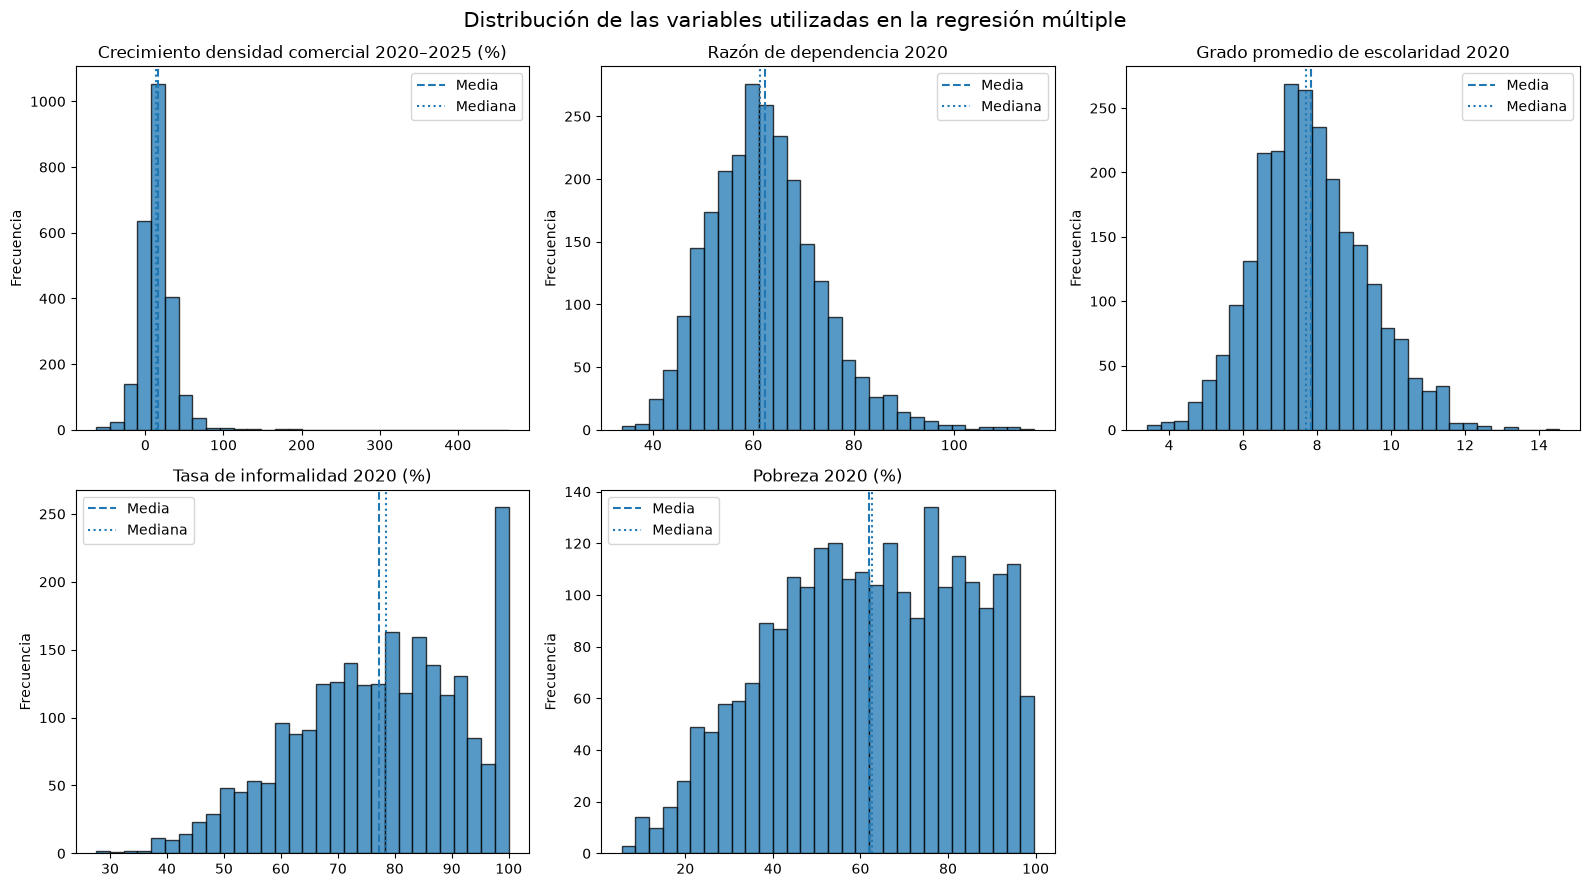

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\histogramas_variables_regresion_multiple.png


In [22]:
# ============================================================
# 4.4 Histogramas de las variables del modelo
# ============================================================

etiquetas = {
    "CREC_DENSIDAD_RETAIL_2020_2025":
        "Crecimiento densidad comercial 2020–2025 (%)",

    "RAZ_DEP_2020":
        "Razón de dependencia 2020",

    "GRAPROES_2020":
        "Grado promedio de escolaridad 2020",

    "TASA_INFORMALIDAD_2020":
        "Tasa de informalidad 2020 (%)",

    "POBREZA_2020":
        "Pobreza 2020 (%)"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, variable in zip(axes, variables_modelo):

    ax.hist(
        df_estimacion[variable],
        bins=30,
        edgecolor="black",
        alpha=0.75
    )

    ax.axvline(
        df_estimacion[variable].mean(),
        linestyle="--",
        linewidth=1.5,
        label="Media"
    )

    ax.axvline(
        df_estimacion[variable].median(),
        linestyle=":",
        linewidth=1.5,
        label="Mediana"
    )

    ax.set_title(etiquetas[variable])
    ax.set_ylabel("Frecuencia")
    ax.legend()

# Eliminar panel sobrante
for ax in axes[len(variables_modelo):]:
    ax.remove()

plt.suptitle(
    "Distribución de las variables utilizadas en la regresión múltiple",
    fontsize=15
)

plt.tight_layout()

ruta_hist = (
    OUTPUT_DIR /
    "histogramas_variables_regresion_multiple.png"
)

plt.savefig(
    ruta_hist,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfica guardada en: {ruta_hist}")

C:\Users\nashe\AppData\Local\Temp\ipykernel_15692\3874622773.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\nashe\AppData\Local\Temp\ipykernel_15692\3874622773.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\nashe\AppData\Local\Temp\ipykernel_15692\3874622773.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\nashe\AppData\Local\Temp\ipykernel_15692\3874622773.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
C:\Users\nashe\AppData\Local\Temp\ipykernel_

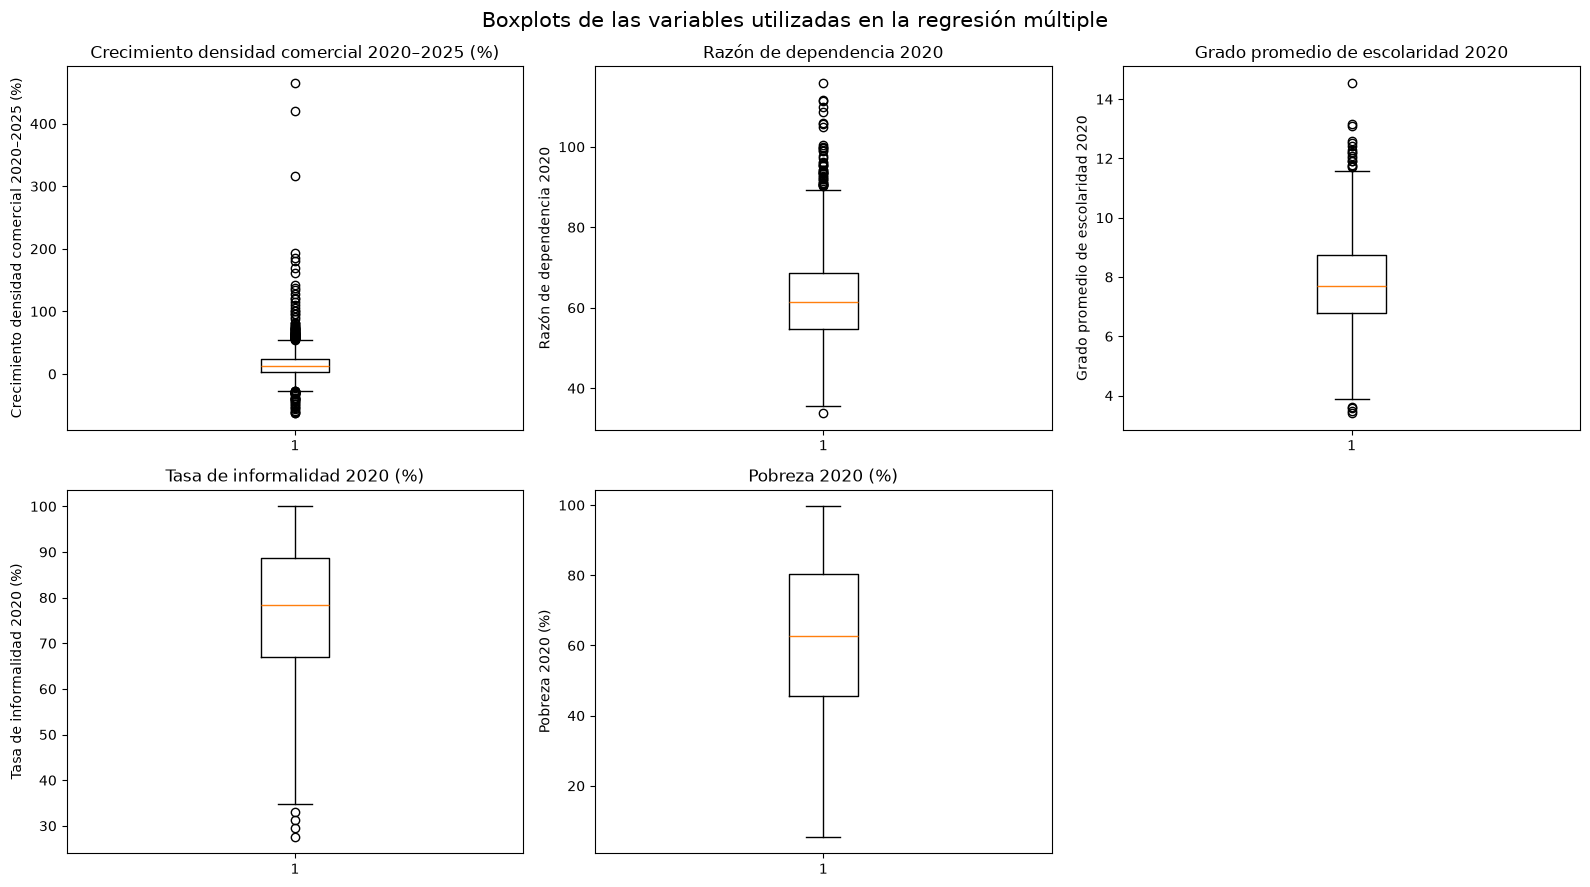

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\boxplots_variables_regresion_multiple.png


In [23]:
# ============================================================
# 4.5 Boxplots de las variables del modelo
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, variable in zip(axes, variables_modelo):

    ax.boxplot(
        df_estimacion[variable],
        vert=True
    )

    ax.set_title(etiquetas[variable])
    ax.set_ylabel(etiquetas[variable])

for ax in axes[len(variables_modelo):]:
    ax.remove()

plt.suptitle(
    "Boxplots de las variables utilizadas en la regresión múltiple",
    fontsize=15
)

plt.tight_layout()

ruta_box = (
    OUTPUT_DIR /
    "boxplots_variables_regresion_multiple.png"
)

plt.savefig(
    ruta_box,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfica guardada en: {ruta_box}")

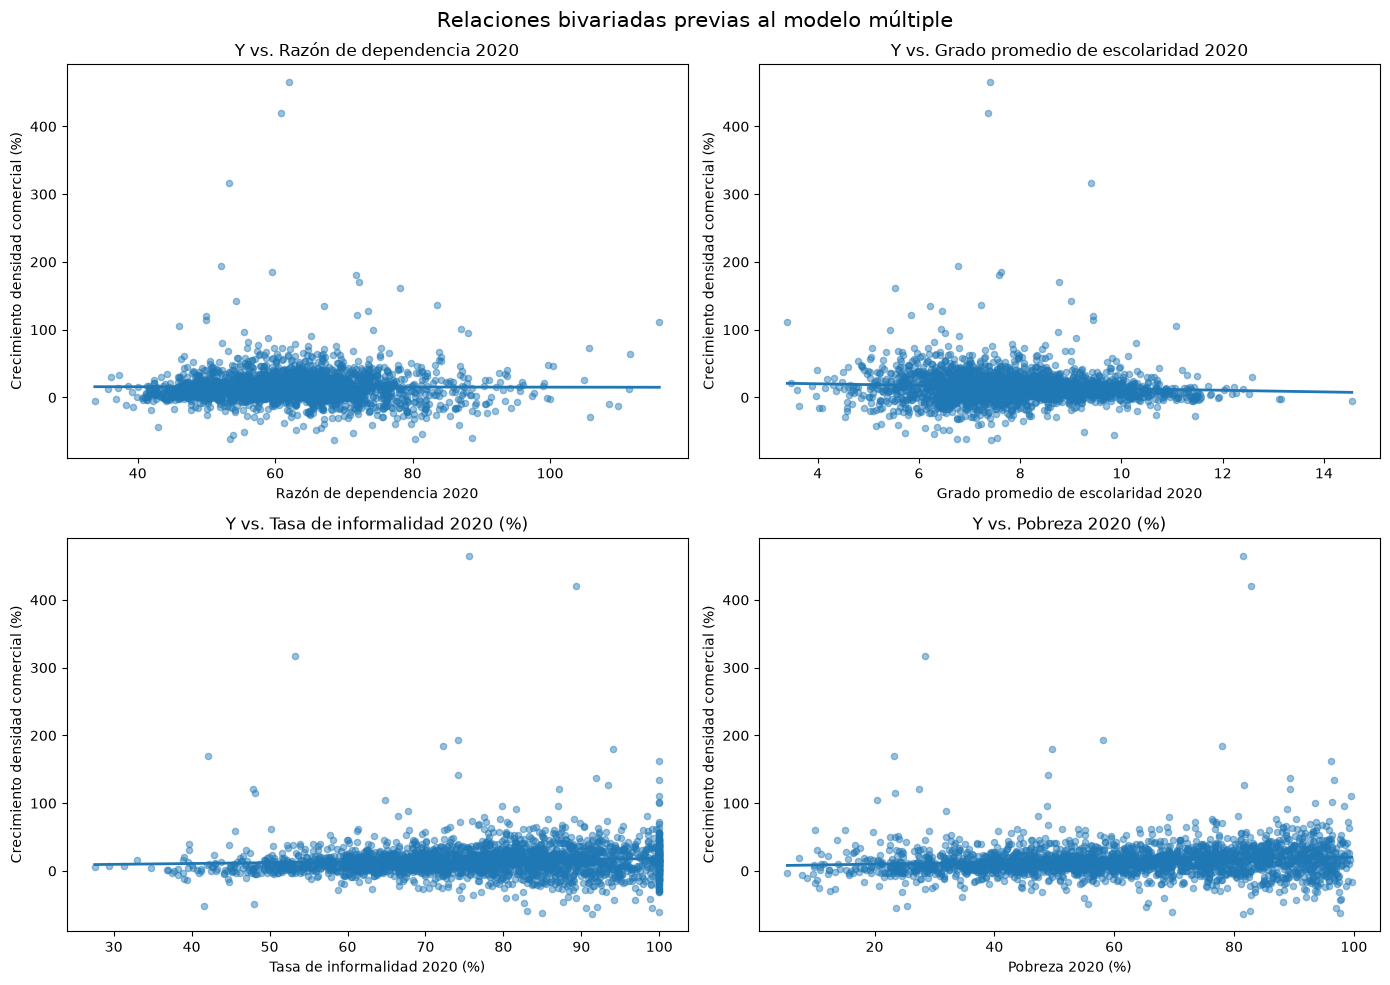

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\dispersion_variables_regresion_multiple.png


In [24]:
# ============================================================
# 4.6 Diagramas de dispersión:
#     variable dependiente vs. variables explicativas
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, variable in zip(axes, X):

    x = df_estimacion[variable]
    y = df_estimacion[Y]

    ax.scatter(
        x,
        y,
        alpha=0.45,
        s=20
    )

    # Recta lineal de referencia
    pendiente, intercepto = np.polyfit(x, y, 1)

    x_linea = np.linspace(
        x.min(),
        x.max(),
        100
    )

    y_linea = (
        intercepto +
        pendiente * x_linea
    )

    ax.plot(
        x_linea,
        y_linea,
        linewidth=2
    )

    ax.set_xlabel(etiquetas[variable])
    ax.set_ylabel(
        "Crecimiento densidad comercial (%)"
    )

    ax.set_title(
        f"Y vs. {etiquetas[variable]}"
    )

plt.suptitle(
    "Relaciones bivariadas previas al modelo múltiple",
    fontsize=15
)

plt.tight_layout()

ruta_scatter = (
    OUTPUT_DIR /
    "dispersion_variables_regresion_multiple.png"
)

plt.savefig(
    ruta_scatter,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfica guardada en: {ruta_scatter}")

In [25]:
# ============================================================
# 4.7 Correlación de Pearson:
#     Y frente a cada variable explicativa
# ============================================================

resultados_pearson = []

for variable in X:

    r, p = stats.pearsonr(
        df_estimacion[Y],
        df_estimacion[variable]
    )

    resultados_pearson.append({
        "Variable explicativa": variable,
        "r de Pearson": r,
        "Valor-p": p
    })

tabla_pearson_yx = pd.DataFrame(
    resultados_pearson
)

display(tabla_pearson_yx)

,Variable explicativa,r de Pearson,Valor-p
0,RAZ_DEP_2020,-0.0043,0.8300
1,GRAPROES_2020,-0.0709,0.0005
2,TASA_INFORMALIDAD_2020,0.0734,0.0003
3,POBREZA_2020,0.1142,0.0000


In [26]:
# ============================================================
# 4.8 Matriz de correlaciones entre todas las variables
# ============================================================

matriz_correlacion = (
    df_estimacion[variables_modelo]
    .corr(method="pearson")
)

display(
    matriz_correlacion.round(4)
)

,CREC_DENSIDAD_RETAIL_2020_2025,RAZ_DEP_2020,GRAPROES_2020,TASA_INFORMALIDAD_2020,POBREZA_2020
CREC_DENSIDAD_RETAIL_2020_2025,1.0000,-0.0043,-0.0709,0.0734,0.1142
RAZ_DEP_2020,-0.0043,1.0000,-0.7393,0.6859,0.5374
GRAPROES_2020,-0.0709,-0.7393,1.0000,-0.7484,-0.6985
TASA_INFORMALIDAD_2020,0.0734,0.6859,-0.7484,1.0000,0.7148
POBREZA_2020,0.1142,0.5374,-0.6985,0.7148,1.0000


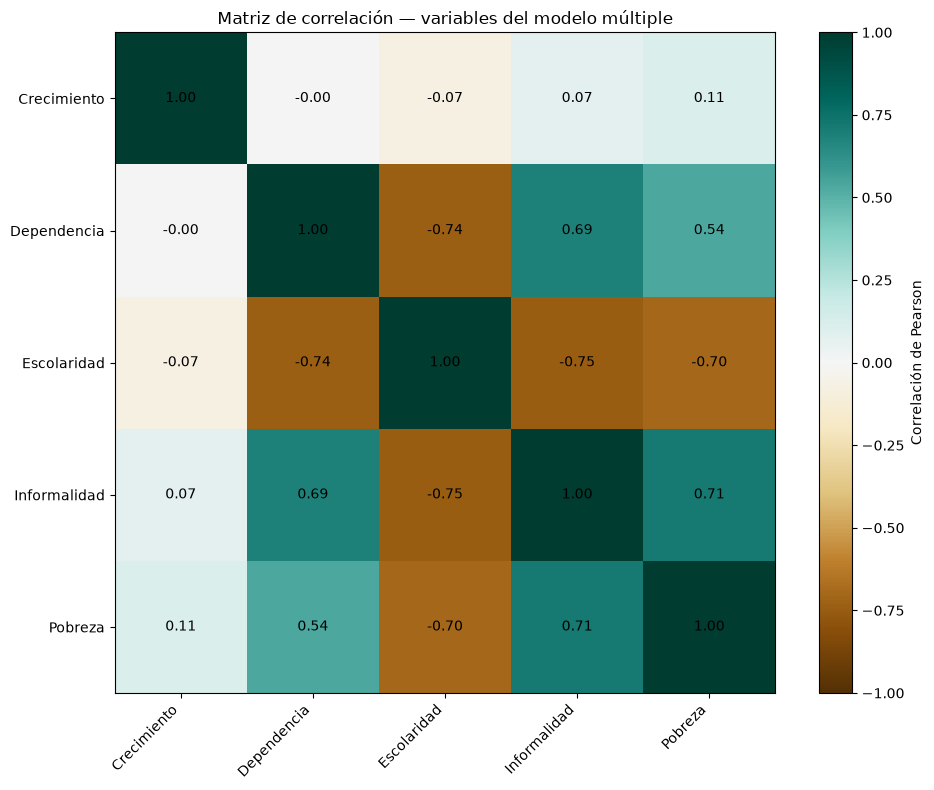

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\matriz_correlacion_regresion_multiple.png


In [27]:
# ============================================================
# 4.9 Visualización de la matriz de correlaciones
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

imagen = ax.imshow(
    matriz_correlacion,
    vmin=-1,
    vmax=1,
    cmap="BrBG"
)

ax.set_xticks(
    range(len(matriz_correlacion.columns))
)

ax.set_yticks(
    range(len(matriz_correlacion.index))
)

nombres_cortos = [
    "Crecimiento",
    "Dependencia",
    "Escolaridad",
    "Informalidad",
    "Pobreza"
]

ax.set_xticklabels(
    nombres_cortos,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    nombres_cortos
)

for i in range(len(matriz_correlacion)):
    for j in range(len(matriz_correlacion.columns)):

        valor = matriz_correlacion.iloc[i, j]

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(
    imagen,
    ax=ax,
    label="Correlación de Pearson"
)

ax.set_title(
    "Matriz de correlación — variables del modelo múltiple"
)

plt.tight_layout()

ruta_corr = (
    OUTPUT_DIR /
    "matriz_correlacion_regresion_multiple.png"
)

plt.savefig(
    ruta_corr,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfica guardada en: {ruta_corr}")

In [28]:
# ============================================================
# 4.10 Correlaciones entre variables explicativas
# ============================================================

correlaciones_x = (
    df_estimacion[X]
    .corr(method="pearson")
)

pares_correlacion = []

for i in range(len(X)):

    for j in range(i + 1, len(X)):

        variable_1 = X[i]
        variable_2 = X[j]

        r = correlaciones_x.loc[
            variable_1,
            variable_2
        ]

        pares_correlacion.append({
            "Variable 1": variable_1,
            "Variable 2": variable_2,
            "r": r,
            "|r|": abs(r)
        })

tabla_correlaciones_x = (
    pd.DataFrame(pares_correlacion)
    .sort_values(
        "|r|",
        ascending=False
    )
    .reset_index(drop=True)
)

display(tabla_correlaciones_x)

,Variable 1,Variable 2,r,|r|
0,GRAPROES_2020,TASA_INFORMALIDAD_2020,-0.7484,0.7484
1,RAZ_DEP_2020,GRAPROES_2020,-0.7393,0.7393
2,TASA_INFORMALIDAD_2020,POBREZA_2020,0.7148,0.7148
3,GRAPROES_2020,POBREZA_2020,-0.6985,0.6985
4,RAZ_DEP_2020,TASA_INFORMALIDAD_2020,0.6859,0.6859
5,RAZ_DEP_2020,POBREZA_2020,0.5374,0.5374


### Cierre de la Fase 4

El análisis descriptivo permitió revisar la distribución, dispersión y presencia de observaciones potencialmente atípicas en las variables que integrarán la regresión múltiple.

El análisis de correlación permitió examinar tanto las asociaciones bivariadas entre el crecimiento de la densidad comercial y cada predictor como las relaciones existentes entre las propias variables explicativas.

Las correlaciones entre predictores se utilizarán únicamente como una primera señal de posibles relaciones compartidas entre variables. La presencia y magnitud de la multicolinealidad se evaluarán posteriormente mediante indicadores específicos, particularmente el Factor de Inflación de la Varianza (VIF).

Con esta revisión descriptiva y correlacional, la base queda preparada para iniciar la estimación del modelo mediante Mínimos Cuadrados Ordinarios.

El análisis descriptivo confirma que las variables presentan comportamientos heterogéneos entre los municipios. El crecimiento de la densidad comercial destaca por su fuerte dispersión y por la presencia de observaciones con valores considerablemente elevados, mientras que las variables explicativas muestran distribuciones más concentradas, aunque con diferencias importantes entre ellas.

Las relaciones bivariadas con la variable dependiente son débiles. La razón de dependencia presenta una correlación prácticamente nula y no significativa; la escolaridad muestra una asociación negativa débil, mientras que informalidad y pobreza presentan asociaciones positivas también débiles. Pobreza registra la correlación individual de mayor magnitud con el crecimiento comercial, aunque su valor continúa siendo reducido.

En contraste, las correlaciones entre las propias variables explicativas son considerablemente mayores. Destacan las relaciones entre escolaridad e informalidad (\(r=-0.7484\)), razón de dependencia y escolaridad (\(r=-0.7393\)), e informalidad y pobreza (\(r=0.7148\)). Esto sugiere que algunos predictores comparten una cantidad importante de información.

Estos resultados no permiten concluir todavía que exista un problema de multicolinealidad, pero justifican realizar posteriormente un diagnóstico formal mediante el Factor de Inflación de la Varianza (VIF) y la tolerancia. La siguiente fase estimará el modelo múltiple por Mínimos Cuadrados Ordinarios para evaluar cómo cambian las relaciones cuando las cuatro variables se consideran simultáneamente.

# FASE 5 — Estimación del modelo múltiple por MCO

En esta fase se estima la regresión lineal múltiple mediante el método de Mínimos Cuadrados Ordinarios (MCO).

El modelo incorpora simultáneamente las cuatro variables explicativas seleccionadas con el propósito de estimar la asociación parcial de cada una con el crecimiento de la densidad comercial municipal.

La especificación es:

\[
Y_i =
\beta_0
+\beta_1 RAZ\_DEP_i
+\beta_2 GRAPROES_i
+\beta_3 INFORMALIDAD_i
+\beta_4 POBREZA_i
+\varepsilon_i
\]

Los parámetros se estiman buscando los valores que minimizan la suma de los residuos al cuadrado:

\[
\min_{\beta_0,\ldots,\beta_4}
\sum_{i=1}^{n}
(Y_i-\hat{Y}_i)^2
\]

En esta etapa se obtiene la estimación inicial por MCO. La interpretación económica, las pruebas de significancia, la bondad de ajuste y los diagnósticos del modelo se desarrollarán en las fases posteriores.

In [29]:
# ============================================================
# FASE 5 — ESTIMACIÓN DEL MODELO MÚLTIPLE POR MCO
# 5.1 Estimación del modelo
# ============================================================

modelo_mco = smf.ols(
    formula=formula_modelo,
    data=df_estimacion
).fit()

print("Modelo de regresión lineal múltiple estimado correctamente.")
print(f"Observaciones utilizadas: {int(modelo_mco.nobs):,}")

Modelo de regresión lineal múltiple estimado correctamente.
Observaciones utilizadas: 2,440


In [30]:
# ============================================================
# 5.2 Resumen completo de la estimación MCO
# ============================================================

print(modelo_mco.summary())

                                  OLS Regression Results                                  
Dep. Variable:     CREC_DENSIDAD_RETAIL_2020_2025   R-squared:                       0.021
Model:                                        OLS   Adj. R-squared:                  0.020
Method:                             Least Squares   F-statistic:                     13.36
Date:                            Tue, 22 Sep 2026   Prob (F-statistic):           9.06e-11
Time:                                    15:54:33   Log-Likelihood:                -11299.
No. Observations:                            2440   AIC:                         2.261e+04
Df Residuals:                                2435   BIC:                         2.264e+04
Df Model:                                       4                                         
Covariance Type:                        nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]

In [31]:
# ============================================================
# 5.3 Tabla de coeficientes estimados
# ============================================================

intervalos = modelo_mco.conf_int(alpha=0.05)

tabla_coeficientes = pd.DataFrame({
    "Coeficiente": modelo_mco.params,
    "Error estándar": modelo_mco.bse,
    "t": modelo_mco.tvalues,
    "Valor-p": modelo_mco.pvalues,
    "IC 95% inferior": intervalos[0],
    "IC 95% superior": intervalos[1]
})

tabla_coeficientes.index.name = "Parámetro"

display(
    tabla_coeficientes.round(4)
)

,Coeficiente,Error estándar,t,Valor-p,IC 95% inferior,IC 95% superior
Parámetro,,,,,,
Intercept,31.1577,9.4694,3.2903,0.0010,12.5887,49.7267
RAZ_DEP_2020,-0.3247,0.0718,-4.5243,0.0000,-0.4655,-0.1840
GRAPROES_2020,-1.1026,0.6172,-1.7863,0.0742,-2.3130,0.1078
TASA_INFORMALIDAD_2020,0.0626,0.0585,1.0707,0.2844,-0.0521,0.1773
POBREZA_2020,0.1357,0.0353,3.8425,0.0001,0.0664,0.2049


In [32]:
# ============================================================
# 5.4 Ecuación estimada del modelo
# ============================================================

coef = modelo_mco.params

print("Ecuación estimada:")
print()

print(
    "CREC_DENSIDAD_RETAIL_2020_2025 = "
    f"{coef['Intercept']:.4f} "
    f"{coef['RAZ_DEP_2020']:+.4f}·RAZ_DEP_2020 "
    f"{coef['GRAPROES_2020']:+.4f}·GRAPROES_2020 "
    f"{coef['TASA_INFORMALIDAD_2020']:+.4f}·TASA_INFORMALIDAD_2020 "
    f"{coef['POBREZA_2020']:+.4f}·POBREZA_2020"
)

Ecuación estimada:

CREC_DENSIDAD_RETAIL_2020_2025 = 31.1577 -0.3247·RAZ_DEP_2020 -1.1026·GRAPROES_2020 +0.0626·TASA_INFORMALIDAD_2020 +0.1357·POBREZA_2020


In [33]:
# ============================================================
# 5.5 Estructura del modelo estimado
# ============================================================

n = int(modelo_mco.nobs)
k_parametros = len(modelo_mco.params)
k_predictores = k_parametros - 1

print(f"Número de observaciones (n): {n:,}")
print(f"Número de variables explicativas: {k_predictores}")
print(f"Número total de parámetros, incluido intercepto: {k_parametros}")
print(f"Grados de libertad del modelo: {int(modelo_mco.df_model)}")
print(f"Grados de libertad residuales: {int(modelo_mco.df_resid):,}")

Número de observaciones (n): 2,440
Número de variables explicativas: 4
Número total de parámetros, incluido intercepto: 5
Grados de libertad del modelo: 4
Grados de libertad residuales: 2,435


In [35]:
# ============================================================
# 5.6 Valores ajustados y residuos
# ============================================================

df_estimacion["Y_OBSERVADO"] = modelo_mco.model.endog
df_estimacion["Y_AJUSTADO_MCO"] = modelo_mco.fittedvalues
df_estimacion["RESIDUO_MCO"] = modelo_mco.resid

print("Valores ajustados y residuos incorporados a df_estimacion.")

display(
    df_estimacion[
        [
            "CVEGEO",
            "municipio",
            Y,
            "Y_AJUSTADO_MCO",
            "RESIDUO_MCO"
        ]
    ].head()
)

Valores ajustados y residuos incorporados a df_estimacion.


,CVEGEO,municipio,CREC_DENSIDAD_RETAIL_2020_2025,Y_AJUSTADO_MCO,RESIDUO_MCO
0,01001,Aguascalientes,5.3615,9.2338,-3.8723
1,01002,Asientos,28.3271,11.3516,16.9755
2,01003,Calvillo,10.0970,11.8556,-1.7586
3,01004,Cosío,39.7279,10.1253,29.6026
4,01005,Jesús María,11.7619,8.9714,2.7906


In [36]:
# ============================================================
# 5.7 Verificación básica de los residuos MCO
# ============================================================

suma_residuos = modelo_mco.resid.sum()
media_residuos = modelo_mco.resid.mean()

print(f"Suma de residuos: {suma_residuos:.10f}")
print(f"Media de residuos: {media_residuos:.10f}")

Suma de residuos: -0.0000000000
Media de residuos: -0.0000000000


In [37]:
# ============================================================
# 5.8 Verificación de la muestra utilizada por MCO
# ============================================================

n_base = len(df_estimacion)
n_mco = int(modelo_mco.nobs)

print(f"Observaciones disponibles: {n_base:,}")
print(f"Observaciones utilizadas por MCO: {n_mco:,}")
print(f"Observaciones excluidas durante la estimación: {n_base - n_mco:,}")

if n_base == n_mco:
    print("\n✓ MCO utilizó la muestra analítica completa.")

Observaciones disponibles: 2,440
Observaciones utilizadas por MCO: 2,440
Observaciones excluidas durante la estimación: 0

✓ MCO utilizó la muestra analítica completa.


Cierre de la Fase 5

El modelo de regresión lineal múltiple fue estimado mediante Mínimos Cuadrados Ordinarios utilizando la muestra completa de 2,440 municipios. La especificación incorpora simultáneamente razón de dependencia, escolaridad, informalidad y pobreza como variables explicativas del crecimiento de la densidad comercial minorista.

La estimación produjo los coeficientes correspondientes a las cuatro variables y permitió obtener los valores ajustados y residuos para cada municipio. Las comprobaciones básicas de MCO fueron consistentes: no se excluyeron observaciones durante la estimación y la media y suma de los residuos resultaron prácticamente iguales a cero.

Los resultados muestran diferencias respecto a las regresiones simples, lo cual justifica analizar con mayor detalle la interpretación de los coeficientes cuando las variables se consideran simultáneamente. La significancia estadística, la capacidad explicativa y los posibles efectos de la relación entre predictores serán evaluados de manera específica en las fases siguientes.

# FASE 6 — Interpretación de coeficientes

El objetivo de esta fase es interpretar la dirección y magnitud de los coeficientes obtenidos en la regresión lineal múltiple.

A diferencia de una regresión simple, cada coeficiente del modelo múltiple representa una asociación parcial. Esto significa que la relación entre una variable explicativa y el crecimiento de la densidad comercial se interpreta manteniendo constantes las demás variables incluidas en la especificación.

La ecuación estimada es:

\[
\widehat{Y} =
31.1577
-0.3247\,RAZ\_DEP
-1.1026\,GRAPROES
+0.0626\,INFORMALIDAD
+0.1357\,POBREZA
\]

donde la variable dependiente corresponde al crecimiento porcentual acumulado de la densidad comercial minorista entre 2020 y 2025.

En esta etapa se interpretan los coeficientes puntuales. La incertidumbre estadística de estas estimaciones será evaluada posteriormente mediante pruebas t, valores-p e intervalos de confianza.

## 6.1. Intercepto

El intercepto estimado es:

\[
\hat{\beta}_0=31.1577
\]

Este valor representa el crecimiento esperado de la densidad comercial cuando razón de dependencia, escolaridad, informalidad y pobreza toman simultáneamente el valor de cero.

Sin embargo, esta combinación no representa una situación observable dentro de la muestra municipal analizada. Por ejemplo, niveles de escolaridad, pobreza e informalidad iguales a cero se encuentran fuera del rango relevante de los datos utilizados.

Por esta razón, el intercepto es necesario para la especificación matemática del modelo, pero no se le atribuye una interpretación económica sustantiva en este análisis.

## 6.2. Razón de dependencia

El coeficiente estimado para la razón de dependencia es:

\[
\hat{\beta}_1=-0.3247
\]

Manteniendo constantes escolaridad, informalidad y pobreza, un aumento de una unidad en la razón de dependencia se asocia, en promedio, con una disminución aproximada de **0.325 puntos porcentuales** en el crecimiento acumulado de la densidad comercial.

Como referencia de magnitud, una diferencia de 10 puntos en la razón de dependencia estaría asociada, bajo la especificación lineal estimada, con aproximadamente:

\[
10(-0.3247)=-3.247
\]

puntos porcentuales de diferencia en el crecimiento de la densidad comercial, manteniendo constantes las demás variables.

La dirección estimada de la asociación es, por tanto, negativa. Su significancia estadística se evaluará formalmente en la siguiente fase.

## 6.3. Grado promedio de escolaridad

El coeficiente estimado para escolaridad es:

\[
\hat{\beta}_2=-1.1026
\]

Manteniendo constantes razón de dependencia, informalidad y pobreza, un año adicional en el grado promedio de escolaridad municipal se asocia con aproximadamente **1.103 puntos porcentuales menos de crecimiento acumulado de la densidad comercial**.

El signo negativo indica una relación inversa dentro de la especificación múltiple: al comparar municipios con niveles similares de dependencia, informalidad y pobreza, aquellos con mayor escolaridad presentan, en promedio, un menor crecimiento de la densidad comercial.

Este resultado describe una asociación condicional dentro del modelo y no debe interpretarse como evidencia de que una mayor escolaridad reduzca causalmente el crecimiento comercial.

## 6.4. Tasa de informalidad

El coeficiente estimado para la tasa de informalidad es:

\[
\hat{\beta}_3=0.0626
\]

Manteniendo constantes razón de dependencia, escolaridad y pobreza, un incremento de un punto porcentual en la tasa de informalidad se asocia, en promedio, con un aumento aproximado de **0.063 puntos porcentuales** en el crecimiento de la densidad comercial.

Para facilitar la interpretación de la magnitud, una diferencia de 10 puntos porcentuales en informalidad correspondería, según el modelo estimado, a aproximadamente:

\[
10(0.0626)=0.626
\]

puntos porcentuales adicionales de crecimiento comercial, manteniendo constantes las demás variables.

La asociación estimada es positiva, aunque su relevancia estadística deberá determinarse posteriormente mediante la prueba individual del coeficiente.

## 6.5. Pobreza

El coeficiente estimado para pobreza es:

\[
\hat{\beta}_4=0.1357
\]

Manteniendo constantes razón de dependencia, escolaridad e informalidad, un incremento de un punto porcentual en la proporción de población en situación de pobreza se asocia, en promedio, con un incremento aproximado de **0.136 puntos porcentuales** en el crecimiento acumulado de la densidad comercial.

Una diferencia de 10 puntos porcentuales en pobreza estaría asociada con aproximadamente:

\[
10(0.1357)=1.357
\]

puntos porcentuales adicionales de crecimiento comercial, manteniendo constantes las demás características incluidas en el modelo.

El signo positivo describe la relación parcial estimada dentro de esta especificación. Este resultado no implica que un aumento de la pobreza produzca crecimiento comercial, ya que el modelo identifica asociaciones estadísticas y puede existir influencia de factores municipales no incorporados en la regresión.

In [38]:
# ============================================================
# FASE 6 — INTERPRETACIÓN DE COEFICIENTES
# 6.6 Tabla resumen de coeficientes
# ============================================================

tabla_interpretacion = pd.DataFrame({
    "Variable": [
        "Razón de dependencia",
        "Escolaridad",
        "Informalidad",
        "Pobreza"
    ],
    "Coeficiente": [
        modelo_mco.params["RAZ_DEP_2020"],
        modelo_mco.params["GRAPROES_2020"],
        modelo_mco.params["TASA_INFORMALIDAD_2020"],
        modelo_mco.params["POBREZA_2020"]
    ],
    "Unidad de cambio en X": [
        "1 punto",
        "1 año",
        "1 punto porcentual",
        "1 punto porcentual"
    ]
})

tabla_interpretacion["Dirección"] = np.where(
    tabla_interpretacion["Coeficiente"] > 0,
    "Positiva",
    "Negativa"
)

display(tabla_interpretacion.round(4))

,Variable,Coeficiente,Unidad de cambio en X,Dirección
0,Razón de dependencia,-0.3247,1 punto,Negativa
1,Escolaridad,-1.1026,1 año,Negativa
2,Informalidad,0.0626,1 punto porcentual,Positiva
3,Pobreza,0.1357,1 punto porcentual,Positiva


In [39]:
# ============================================================
# 6.7 Coeficientes estandarizados
# ============================================================

desv_y = df_estimacion[Y].std()

betas_estandarizados = []

for variable in X:

    beta = modelo_mco.params[variable]
    desv_x = df_estimacion[variable].std()

    beta_std = beta * (
        desv_x / desv_y
    )

    betas_estandarizados.append({
        "Variable": variable,
        "Beta estandarizado": beta_std
    })

tabla_beta_std = pd.DataFrame(
    betas_estandarizados
)

tabla_beta_std["Magnitud absoluta"] = (
    tabla_beta_std["Beta estandarizado"].abs()
)

tabla_beta_std = (
    tabla_beta_std
    .sort_values(
        "Magnitud absoluta",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    tabla_beta_std.round(4)
)

,Variable,Beta estandarizado,Magnitud absoluta
0,RAZ_DEP_2020,-0.1416,0.1416
1,POBREZA_2020,0.1182,0.1182
2,GRAPROES_2020,-0.0653,0.0653
3,TASA_INFORMALIDAD_2020,0.0372,0.0372


In [41]:
# ============================================================
# 6.8 Comparación de coeficientes:
#     regresión simple vs. regresión múltiple
# ============================================================

coeficientes_simples = {
    "RAZ_DEP_2020": -0.0100,
    "GRAPROES_2020": -1.1986,
    "TASA_INFORMALIDAD_2020": 0.1236,
    "POBREZA_2020": 0.1312
}

comparacion_coef = []

for variable in X:

    beta_simple = coeficientes_simples[variable]
    beta_multiple = modelo_mco.params[variable]

    comparacion_coef.append({
        "Variable": variable,
        "Beta simple": beta_simple,
        "Beta múltiple": beta_multiple,
        "Cambio (múltiple - simple)": beta_multiple - beta_simple
    })

tabla_comparacion_coef = pd.DataFrame(comparacion_coef)

display(tabla_comparacion_coef.round(4))

,Variable,Beta simple,Beta múltiple,Cambio (múltiple - simple)
0,RAZ_DEP_2020,-0.0100,-0.3247,-0.3147
1,GRAPROES_2020,-1.1986,-1.1026,0.0960
2,TASA_INFORMALIDAD_2020,0.1236,0.0626,-0.0610
3,POBREZA_2020,0.1312,0.1357,0.0045


## 6.9. Alcance de la interpretación

Los coeficientes estimados representan asociaciones parciales dentro de la especificación propuesta. La expresión "manteniendo constantes las demás variables" se refiere únicamente a las variables incorporadas explícitamente en el modelo.

No puede asumirse que el modelo controla todas las diferencias relevantes entre los municipios. Factores como estructura productiva, urbanización, ingreso, conectividad, condiciones regionales o características del mercado local pueden encontrarse fuera de la especificación.

Por esta razón, los coeficientes no se interpretan como efectos causales. El análisis permite cuantificar asociaciones condicionadas a las variables observadas incluidas en la regresión.

### Cierre de la Fase 6

La interpretación de los coeficientes muestra que, una vez consideradas simultáneamente las cuatro características municipales, razón de dependencia y escolaridad presentan asociaciones parciales negativas con el crecimiento de la densidad comercial, mientras que informalidad y pobreza mantienen asociaciones positivas.

Los coeficientes representan cambios promedio en el crecimiento comercial asociados con variaciones de cada predictor, manteniendo constantes las demás variables incluidas en la regresión.

La comparación preliminar con las regresiones simples muestra que la incorporación simultánea de las variables modifica la magnitud de algunos coeficientes, particularmente en razón de dependencia e informalidad. Este comportamiento será evaluado con mayor detalle al analizar la significancia estadística y la posible presencia de multicolinealidad.

La siguiente fase evaluará formalmente si el modelo es significativo en conjunto y cuáles coeficientes presentan evidencia estadística suficiente de una asociación distinta de cero.

la incorporación simultánea de las variables modifica de manera importante algunos coeficientes, especialmente razón de dependencia e informalidad, mientras que pobreza muestra una notable estabilidad entre la especificación simple y múltiple.

# FASE 7 — Significancia global e individual

La evaluación de significancia estadística se realiza en dos niveles.

En primer lugar, la prueba \(F\) permite determinar si las variables explicativas, consideradas conjuntamente, aportan información estadísticamente significativa para explicar la variación del crecimiento de la densidad comercial.

En segundo lugar, las pruebas \(t\) permiten evaluar individualmente si el coeficiente asociado a cada variable explicativa es estadísticamente distinto de cero, manteniendo constantes las demás variables incluidas en el modelo.

Para esta evaluación se utiliza un nivel de significancia de:

\[
\alpha=0.05
\]

En esta fase se analiza la inferencia MCO convencional. Posteriormente se comprobará la estabilidad de las conclusiones mediante errores estándar robustos.

In [42]:
# ============================================================
# FASE 7 — SIGNIFICANCIA GLOBAL E INDIVIDUAL
# 7.1 Prueba F de significancia global
# ============================================================

alpha = 0.05

f_stat = modelo_mco.fvalue
p_f = modelo_mco.f_pvalue

decision_f = (
    "Rechazar H0"
    if p_f < alpha
    else "No rechazar H0"
)

print("PRUEBA F — SIGNIFICANCIA GLOBAL")
print("=" * 50)

print(f"Estadístico F: {f_stat:.4f}")
print(f"Valor-p: {p_f:.6e}")
print(f"Nivel de significancia: {alpha}")
print(f"Decisión: {decision_f}")

PRUEBA F — SIGNIFICANCIA GLOBAL
Estadístico F: 13.3571
Valor-p: 9.062690e-11
Nivel de significancia: 0.05
Decisión: Rechazar H0


## 7.2. Interpretación de la significancia global

La prueba \(F\) arroja un estadístico de aproximadamente:

\[
F=13.36
\]

con un valor-p de:

\[
p=9.06\times10^{-11}
\]

Dado que el valor-p es considerablemente menor que 0.05, se rechaza la hipótesis nula de que los cuatro coeficientes de pendiente sean simultáneamente iguales a cero.

Esto indica que, consideradas en conjunto, las variables razón de dependencia, escolaridad, informalidad y pobreza aportan información estadísticamente significativa sobre el crecimiento de la densidad comercial municipal.

Sin embargo, la significancia global del modelo no implica que todas las variables sean significativas individualmente ni que el modelo tenga una elevada capacidad explicativa. Estas cuestiones deben evaluarse por separado mediante las pruebas \(t\) y los indicadores de bondad de ajuste.

In [43]:
# ============================================================
# 7.3 Pruebas t individuales
# ============================================================

variables_explicativas = [
    "RAZ_DEP_2020",
    "GRAPROES_2020",
    "TASA_INFORMALIDAD_2020",
    "POBREZA_2020"
]

resultados_t = []

for variable in variables_explicativas:

    beta = modelo_mco.params[variable]
    se = modelo_mco.bse[variable]
    t = modelo_mco.tvalues[variable]
    p = modelo_mco.pvalues[variable]

    ic_inf = modelo_mco.conf_int().loc[variable, 0]
    ic_sup = modelo_mco.conf_int().loc[variable, 1]

    if p < alpha:
        decision = "Significativa"
    else:
        decision = "No significativa"

    resultados_t.append({
        "Variable": variable,
        "Coeficiente": beta,
        "Error estándar": se,
        "t": t,
        "Valor-p": p,
        "IC 95% inferior": ic_inf,
        "IC 95% superior": ic_sup,
        "Decisión al 5%": decision
    })

tabla_significancia = pd.DataFrame(resultados_t)

display(
    tabla_significancia.round(4)
)

,Variable,Coeficiente,Error estándar,t,Valor-p,IC 95% inferior,IC 95% superior,Decisión al 5%
0,RAZ_DEP_2020,-0.3247,0.0718,-4.5243,0.0000,-0.4655,-0.1840,Significativa
1,GRAPROES_2020,-1.1026,0.6172,-1.7863,0.0742,-2.3130,0.1078,No significativa
2,TASA_INFORMALIDAD_2020,0.0626,0.0585,1.0707,0.2844,-0.0521,0.1773,No significativa
3,POBREZA_2020,0.1357,0.0353,3.8425,0.0001,0.0664,0.2049,Significativa


## 7.4. Interpretación de la significancia individual

Los resultados muestran que la significancia observada en las regresiones simples cambia cuando las cuatro variables se incorporan simultáneamente al modelo.

La razón de dependencia presenta ahora un coeficiente negativo y estadísticamente significativo. En contraste, escolaridad e informalidad, que habían resultado significativas en las regresiones simples, dejan de presentar evidencia suficiente de una asociación parcial distinta de cero al nivel de 5%.

Pobreza mantiene una asociación positiva y estadísticamente significativa después de controlar por razón de dependencia, escolaridad e informalidad.

Estos cambios muestran que la significancia bivariada de una variable no necesariamente se conserva cuando se consideran simultáneamente otras características relacionadas con ella. Parte de la información que una variable representaba en una regresión simple puede encontrarse compartida con otros predictores dentro del modelo múltiple.

La posible influencia de las correlaciones existentes entre las variables explicativas será evaluada posteriormente mediante el diagnóstico formal de multicolinealidad.

In [44]:
# ============================================================
# 7.5 Comparación de significancia:
#     modelo simple vs. modelo múltiple
# ============================================================

p_simples = {
    "RAZ_DEP_2020": 0.8350,
    "GRAPROES_2020": 0.0001,
    "TASA_INFORMALIDAD_2020": 0.0003,
    "POBREZA_2020": 0.0000001  # solo para clasificación < 0.001
}

comparacion_significancia = []

for variable in X:

    p_simple = p_simples[variable]
    p_multiple = modelo_mco.pvalues[variable]

    sig_simple = (
        "Sí" if p_simple < alpha else "No"
    )

    sig_multiple = (
        "Sí" if p_multiple < alpha else "No"
    )

    comparacion_significancia.append({
        "Variable": variable,
        "Significativa simple": sig_simple,
        "Significativa múltiple": sig_multiple,
        "p múltiple": p_multiple
    })

tabla_comparacion_significancia = pd.DataFrame(
    comparacion_significancia
)

display(
    tabla_comparacion_significancia.round(4)
)

,Variable,Significativa simple,Significativa múltiple,p múltiple
0,RAZ_DEP_2020,No,Sí,0.0000
1,GRAPROES_2020,Sí,No,0.0742
2,TASA_INFORMALIDAD_2020,Sí,No,0.2844
3,POBREZA_2020,Sí,Sí,0.0001


## 7.6. Significancia global frente a significancia individual

No existe contradicción entre encontrar un modelo globalmente significativo y observar que algunas variables individuales no resultan significativas.

La prueba \(F\) evalúa la hipótesis conjunta de que todos los coeficientes de pendiente sean iguales a cero. Por tanto, un resultado significativo indica que el conjunto de variables contiene información estadísticamente relevante para explicar la variable dependiente.

Las pruebas \(t\), en cambio, evalúan cada coeficiente de manera individual, condicionando su efecto a la presencia de los demás predictores.

En este modelo, la prueba \(F\) indica significancia conjunta, mientras que las pruebas \(t\) muestran que la evidencia individual se concentra principalmente en razón de dependencia y pobreza bajo la inferencia MCO convencional.

## 7.7. Conservación inicial de las variables

La ausencia de significancia individual de escolaridad e informalidad no constituye, por sí sola, una razón suficiente para eliminarlas inmediatamente del modelo.

Antes de modificar la especificación es necesario evaluar si las variables presentan multicolinealidad, si los errores estándar son sensibles a heterocedasticidad y si existen observaciones influyentes que estén afectando las estimaciones.

Además, la selección de variables debe considerar su justificación conceptual y no depender exclusivamente de un criterio automático basado en valores-p.

Por esta razón, las cuatro variables se conservan en la especificación base hasta completar los diagnósticos econométricos.

In [45]:
# ============================================================
# 7.8 Resumen de decisiones de significancia
# ============================================================

tabla_decisiones = tabla_significancia[
    [
        "Variable",
        "Coeficiente",
        "t",
        "Valor-p",
        "Decisión al 5%"
    ]
].copy()

display(
    tabla_decisiones.round(4)
)

,Variable,Coeficiente,t,Valor-p,Decisión al 5%
0,RAZ_DEP_2020,-0.3247,-4.5243,0.0000,Significativa
1,GRAPROES_2020,-1.1026,-1.7863,0.0742,No significativa
2,TASA_INFORMALIDAD_2020,0.0626,1.0707,0.2844,No significativa
3,POBREZA_2020,0.1357,3.8425,0.0001,Significativa


### Cierre de la Fase 7

La prueba \(F\) muestra que el modelo de regresión múltiple es estadísticamente significativo en conjunto, por lo que se rechaza la hipótesis de que las cuatro pendientes sean simultáneamente iguales a cero.

A nivel individual, razón de dependencia y pobreza presentan coeficientes estadísticamente significativos al 5% bajo la inferencia MCO convencional. Escolaridad e informalidad no alcanzan dicho nivel de significancia cuando las cuatro variables se consideran simultáneamente.

La comparación con las regresiones simples muestra cambios importantes: razón de dependencia pasa de no significativa a significativa, mientras que escolaridad e informalidad pierden significancia. Pobreza mantiene una asociación positiva y significativa en ambas especificaciones.

Estos resultados muestran la importancia de considerar conjuntamente las características municipales. Sin embargo, todavía no es conveniente modificar la especificación del modelo, ya que es necesario evaluar la capacidad explicativa, la multicolinealidad y la estabilidad de la inferencia antes de tomar decisiones sobre la permanencia de las variables.

# FASE 8 — R² y R² ajustado

El objetivo de esta fase es evaluar la capacidad explicativa del modelo de regresión múltiple mediante el coeficiente de determinación \(R^2\) y el coeficiente de determinación ajustado \(R^2_{aj}\).

El \(R^2\) mide la proporción de la variabilidad observada en el crecimiento de la densidad comercial que es representada conjuntamente por las variables explicativas incluidas en el modelo.

Por su parte, el \(R^2\) ajustado incorpora una penalización por el número de predictores utilizados. Esta característica resulta especialmente útil en regresión múltiple, ya que permite valorar si la incorporación de varias variables realmente aporta capacidad explicativa adicional y no solamente incrementa de manera mecánica el \(R^2\).

In [46]:
# ============================================================
# FASE 8 — R² Y R² AJUSTADO
# 8.1 Coeficiente de determinación
# ============================================================

r2 = modelo_mco.rsquared
r2_ajustado = modelo_mco.rsquared_adj

variabilidad_explicada = r2 * 100
variabilidad_no_explicada = (1 - r2) * 100

print("CAPACIDAD EXPLICATIVA DEL MODELO")
print("=" * 50)

print(f"R²: {r2:.6f}")
print(f"R² ajustado: {r2_ajustado:.6f}")

print(
    f"\nVariabilidad explicada por el modelo: "
    f"{variabilidad_explicada:.2f}%"
)

print(
    f"Variabilidad no explicada por el modelo: "
    f"{variabilidad_no_explicada:.2f}%"
)

CAPACIDAD EXPLICATIVA DEL MODELO
R²: 0.021471
R² ajustado: 0.019863

Variabilidad explicada por el modelo: 2.15%
Variabilidad no explicada por el modelo: 97.85%


## 8.2. Interpretación del R²

El coeficiente de determinación del modelo es aproximadamente:

\[
R^2=0.021
\]

Esto significa que razón de dependencia, escolaridad, informalidad y pobreza, consideradas conjuntamente dentro de la especificación lineal propuesta, explican alrededor del **2.1% de la variabilidad observada en el crecimiento de la densidad comercial municipal entre 2020 y 2025**.

En consecuencia, aproximadamente el 97.9% de la variabilidad permanece fuera de la explicación proporcionada por estas cuatro variables dentro del modelo.

El resultado indica que la capacidad explicativa del modelo es reducida. Aunque la prueba \(F\) mostró que el modelo es estadísticamente significativo en conjunto, la proporción de variabilidad representada continúa siendo pequeña.

Esto confirma que significancia estadística y capacidad explicativa responden a preguntas diferentes: el modelo puede identificar asociaciones estadísticamente detectables sin explicar una parte amplia de las diferencias observadas entre municipios.

In [47]:
# ============================================================
# 8.3 Comprobación del R² ajustado
# ============================================================

n = int(modelo_mco.nobs)
k = int(modelo_mco.df_model)

r2_aj_manual = (
    1
    - (1 - r2)
    * ((n - 1) / (n - k - 1))
)

print(f"Número de observaciones: {n:,}")
print(f"Número de predictores: {k}")

print(f"\nR²: {r2:.6f}")
print(f"R² ajustado de statsmodels: {r2_ajustado:.6f}")
print(f"R² ajustado calculado manualmente: {r2_aj_manual:.6f}")

Número de observaciones: 2,440
Número de predictores: 4

R²: 0.021471
R² ajustado de statsmodels: 0.019863
R² ajustado calculado manualmente: 0.019863


## 8.4. Interpretación del R² ajustado

El \(R^2\) ajustado es aproximadamente:

\[
R^2_{aj}\approx0.020
\]

Esto indica que, después de considerar el número de variables explicativas incorporadas en la regresión, la capacidad explicativa del modelo permanece cercana al **2%**.

La pequeña diferencia entre \(R^2\) y \(R^2\) ajustado muestra que la penalización asociada a la inclusión de cuatro predictores es reducida, principalmente debido al tamaño amplio de la muestra.

Sin embargo, el resultado también confirma que la baja capacidad explicativa no se debe simplemente al ajuste por número de variables: aun después de considerar las cuatro características municipales de manera conjunta, la mayor parte de la heterogeneidad del crecimiento comercial continúa sin ser representada por el modelo.

In [48]:
# ============================================================
# 8.5 Comparación de capacidad explicativa:
#     mejor modelo simple vs. modelo múltiple
# ============================================================

r2_simple_pobreza = 0.0130

comparacion_r2 = pd.DataFrame({
    "Modelo": [
        "Regresión simple — Pobreza",
        "Regresión múltiple"
    ],
    "R²": [
        r2_simple_pobreza,
        r2
    ]
})

comparacion_r2["Variabilidad explicada (%)"] = (
    comparacion_r2["R²"] * 100
)

display(
    comparacion_r2.round(4)
)

mejora_absoluta = (
    r2 - r2_simple_pobreza
)

print(
    "\nIncremento absoluto en R²: "
    f"{mejora_absoluta:.4f}"
)

print(
    "Incremento en puntos porcentuales de variabilidad explicada: "
    f"{mejora_absoluta * 100:.2f}"
)

,Modelo,R²,Variabilidad explicada (%)
0,Regresión simple — Pobreza,0.0130,1.3000
1,Regresión múltiple,0.0215,2.1471



Incremento absoluto en R²: 0.0085
Incremento en puntos porcentuales de variabilidad explicada: 0.85


## 8.6. Comparación con la regresión simple

El mejor modelo de regresión simple había sido el correspondiente a pobreza, con un coeficiente de determinación cercano a:

\[
R^2=0.013
\]

La incorporación simultánea de razón de dependencia, escolaridad, informalidad y pobreza incrementa el \(R^2\) hasta aproximadamente:

\[
R^2=0.021
\]

Por tanto, el modelo múltiple representa una proporción mayor de la variabilidad que cualquiera de las regresiones simples consideradas individualmente.

Sin embargo, la mejora absoluta es reducida. El incremento respecto al modelo simple de pobreza es de aproximadamente 0.008 en \(R^2\), equivalente a cerca de **0.8 puntos porcentuales adicionales de variabilidad explicada**.

Por ello, la incorporación de varios predictores mejora el ajuste relativo, pero no modifica la conclusión general de que las variables seleccionadas explican solamente una fracción pequeña de las diferencias de crecimiento comercial observadas entre municipios.

## 8.7. Alcance del bajo R²

Un valor reducido de \(R^2\) no implica que los coeficientes estimados sean necesariamente incorrectos ni que el modelo carezca de utilidad.

En este proyecto, el modelo tiene una finalidad tanto inferencial como predictiva. Desde la perspectiva inferencial, la regresión múltiple permite estudiar qué asociaciones permanecen después de considerar simultáneamente varias características municipales.

Desde la perspectiva predictiva, en cambio, el bajo porcentaje de variabilidad explicada anticipa que las cuatro variables probablemente no serán suficientes para generar predicciones altamente precisas del crecimiento comercial.

Esta segunda cuestión deberá comprobarse mediante una evaluación fuera de muestra y métricas específicas de error, por lo que no puede concluirse únicamente a partir del \(R^2\) obtenido dentro de la muestra.

In [49]:
# ============================================================
# 8.8 Resumen de capacidad explicativa
# ============================================================

tabla_ajuste = pd.DataFrame({
    "Indicador": [
        "R²",
        "R² ajustado",
        "Variabilidad explicada (%)",
        "Variabilidad no explicada (%)"
    ],
    "Resultado": [
        r2,
        r2_ajustado,
        r2 * 100,
        (1 - r2) * 100
    ]
})

display(
    tabla_ajuste.round(4)
)

,Indicador,Resultado
0,R²,0.0215
1,R² ajustado,0.0199
2,Variabilidad explicada (%),2.1471
3,Variabilidad no explicada (%),97.8529


# FASE 9 — Diagnóstico de multicolinealidad

La multicolinealidad aparece cuando dos o más variables explicativas contienen información lineal fuertemente relacionada. En una regresión múltiple, esta situación puede dificultar la separación de la asociación individual de cada predictor con la variable dependiente.

Una alta correlación entre variables explicativas no necesariamente invalida el modelo, pero puede aumentar los errores estándar, reducir la precisión de los coeficientes y provocar cambios en su significancia cuando las variables se incorporan simultáneamente.

En esta fase se evalúa formalmente la multicolinealidad mediante:

- la matriz de correlaciones entre predictores;
- el Factor de Inflación de la Varianza (VIF);
- la tolerancia;
- el \(R^2\) de las regresiones auxiliares.

Las decisiones no se tomarán utilizando un único umbral automático. Los resultados se interpretarán conjuntamente con la estructura conceptual del modelo y con la estabilidad de los coeficientes estimados.

## 9.1. Factor de Inflación de la Varianza

El Factor de Inflación de la Varianza permite medir cuánto aumenta la varianza del coeficiente de una variable explicativa debido a su relación lineal con los demás predictores.

Para cada variable \(X_j\):

\[
VIF_j=\frac{1}{1-R_j^2}
\]

donde \(R_j^2\) corresponde al coeficiente de determinación obtenido al utilizar las demás variables explicativas para explicar \(X_j\).

Un VIF cercano a 1 indica poca información lineal compartida con los demás predictores. Valores más elevados indican que una parte importante de la información de esa variable puede ser representada por las demás variables del modelo.

Los puntos de corte como 5 o 10 se utilizan únicamente como referencias prácticas y no deben considerarse reglas absolutas. La evaluación debe complementarse con la teoría, las correlaciones y el comportamiento de los coeficientes.

In [50]:
# ============================================================
# FASE 9 — DIAGNÓSTICO DE MULTICOLINEALIDAD
# 9.2 Importación de herramientas
# ============================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("Herramienta VIF cargada correctamente.")

Herramienta VIF cargada correctamente.


In [51]:
# ============================================================
# 9.3 Cálculo del Factor de Inflación de la Varianza
# ============================================================

X_vif = df_estimacion[X].copy()

X_vif_const = sm.add_constant(X_vif)

resultados_vif = []

for i, variable in enumerate(X_vif_const.columns):

    vif = variance_inflation_factor(
        X_vif_const.values,
        i
    )

    resultados_vif.append({
        "Variable": variable,
        "VIF": vif
    })

tabla_vif_completa = pd.DataFrame(resultados_vif)

display(
    tabla_vif_completa.round(4)
)

,Variable,VIF
0,const,354.3063
1,RAZ_DEP_2020,2.4373
2,GRAPROES_2020,3.3217
3,TASA_INFORMALIDAD_2020,2.9987
4,POBREZA_2020,2.3533


In [52]:
# ============================================================
# 9.4 VIF, tolerancia y R² auxiliar
# ============================================================

tabla_vif = (
    tabla_vif_completa[
        tabla_vif_completa["Variable"] != "const"
    ]
    .copy()
    .reset_index(drop=True)
)

tabla_vif["Tolerancia"] = (
    1 / tabla_vif["VIF"]
)

tabla_vif["R² auxiliar"] = (
    1 - tabla_vif["Tolerancia"]
)

display(
    tabla_vif.round(4)
)

,Variable,VIF,Tolerancia,R² auxiliar
0,RAZ_DEP_2020,2.4373,0.4103,0.5897
1,GRAPROES_2020,3.3217,0.3011,0.6989
2,TASA_INFORMALIDAD_2020,2.9987,0.3335,0.6665
3,POBREZA_2020,2.3533,0.4249,0.5751


In [53]:
# ============================================================
# 9.5 Clasificación orientativa del VIF
# ============================================================

def clasificar_vif(vif):

    if vif < 5:
        return "Sin señal fuerte"

    elif vif < 10:
        return "Revisar con atención"

    else:
        return "Posible multicolinealidad severa"


tabla_vif["Evaluación orientativa"] = (
    tabla_vif["VIF"]
    .apply(clasificar_vif)
)

tabla_vif = tabla_vif.sort_values(
    "VIF",
    ascending=False
).reset_index(drop=True)

display(
    tabla_vif.round(4)
)

,Variable,VIF,Tolerancia,R² auxiliar,Evaluación orientativa
0,GRAPROES_2020,3.3217,0.3011,0.6989,Sin señal fuerte
1,TASA_INFORMALIDAD_2020,2.9987,0.3335,0.6665,Sin señal fuerte
2,RAZ_DEP_2020,2.4373,0.4103,0.5897,Sin señal fuerte
3,POBREZA_2020,2.3533,0.4249,0.5751,Sin señal fuerte


In [54]:
# ============================================================
# 9.6 Regresiones auxiliares para cada predictor
# ============================================================

resultados_auxiliares = []

for variable_objetivo in X:

    otras_variables = [
        variable
        for variable in X
        if variable != variable_objetivo
    ]

    X_aux = sm.add_constant(
        df_estimacion[otras_variables]
    )

    y_aux = df_estimacion[
        variable_objetivo
    ]

    modelo_aux = sm.OLS(
        y_aux,
        X_aux
    ).fit()

    resultados_auxiliares.append({
        "Variable explicada": variable_objetivo,
        "R² auxiliar": modelo_aux.rsquared,
        "VIF calculado": 1 / (
            1 - modelo_aux.rsquared
        )
    })

tabla_auxiliares = pd.DataFrame(
    resultados_auxiliares
)

display(
    tabla_auxiliares.round(4)
)

,Variable explicada,R² auxiliar,VIF calculado
0,RAZ_DEP_2020,0.5897,2.4373
1,GRAPROES_2020,0.6989,3.3217
2,TASA_INFORMALIDAD_2020,0.6665,2.9987
3,POBREZA_2020,0.5751,2.3533


## 9.7. Interpretación de la tolerancia

La tolerancia representa la proporción de variabilidad de una variable explicativa que no es explicada linealmente por los demás predictores.

Se calcula como:

\[
TOL_j=\frac{1}{VIF_j}
\]

Una tolerancia reducida indica que una proporción elevada de la información de la variable se encuentra compartida con otras variables explicativas.

Como referencias orientativas, valores de tolerancia inferiores a 0.20 suelen justificar una revisión más detallada y valores inferiores a 0.10 pueden indicar una situación más severa. Sin embargo, estos umbrales no deben utilizarse como reglas automáticas para eliminar variables.

## 9.8. Correlación y multicolinealidad

Las correlaciones bivariadas calculadas previamente mostraron asociaciones relativamente elevadas entre algunos predictores. Sin embargo, una matriz de correlaciones analiza las variables de dos en dos.

El VIF amplía este diagnóstico porque evalúa qué tan bien puede explicarse cada predictor mediante el conjunto de las demás variables independientes.

Por esta razón, una correlación elevada constituye una señal preliminar, mientras que el VIF y la tolerancia permiten evaluar de manera más directa la posible inflación de la varianza de los coeficientes.

In [55]:
# ============================================================
# 9.9 Condition Number reportado por el modelo
# ============================================================

condition_number = modelo_mco.condition_number

print(
    f"Condition Number del modelo: "
    f"{condition_number:,.2f}"
)

Condition Number del modelo: 2,257.60


In [56]:
# ============================================================
# 9.10 Condition Number con predictores estandarizados
# ============================================================

X_estandarizada = (
    df_estimacion[X]
    - df_estimacion[X].mean()
) / df_estimacion[X].std()

X_estandarizada_const = sm.add_constant(
    X_estandarizada
)

condition_number_std = np.linalg.cond(
    X_estandarizada_const.values
)

print(
    "Condition Number con predictores estandarizados: "
    f"{condition_number_std:.4f}"
)

Condition Number con predictores estandarizados: 3.7887


## 9.11. Criterio para posibles modificaciones del modelo

La presencia de un VIF elevado no implica automáticamente que una variable deba eliminarse.

La decisión de modificar una especificación debe considerar conjuntamente:

- la magnitud del VIF y la tolerancia;
- la relación conceptual entre los predictores;
- la estabilidad de los coeficientes;
- los errores estándar;
- la significancia estadística;
- el objetivo inferencial del modelo.

Eliminar una variable únicamente para reducir el VIF puede generar una especificación conceptualmente incompleta e incluso introducir sesgo por variable omitida.

Por esta razón, las cuatro variables se mantienen inicialmente en el modelo base y cualquier modificación deberá estar respaldada tanto por evidencia estadística como por una justificación económica.

In [57]:
# ============================================================
# 9.12 Tabla final del diagnóstico de multicolinealidad
# ============================================================

tabla_multicolinealidad = tabla_vif[
    [
        "Variable",
        "VIF",
        "Tolerancia",
        "R² auxiliar",
        "Evaluación orientativa"
    ]
].copy()

display(
    tabla_multicolinealidad.round(4)
)

,Variable,VIF,Tolerancia,R² auxiliar,Evaluación orientativa
0,GRAPROES_2020,3.3217,0.3011,0.6989,Sin señal fuerte
1,TASA_INFORMALIDAD_2020,2.9987,0.3335,0.6665,Sin señal fuerte
2,RAZ_DEP_2020,2.4373,0.4103,0.5897,Sin señal fuerte
3,POBREZA_2020,2.3533,0.4249,0.5751,Sin señal fuerte


### Cierre de la Fase 9

El diagnóstico de multicolinealidad muestra que las variables explicativas comparten una cantidad relevante de información, pero no presentan niveles suficientemente elevados como para considerar que exista un problema severo de multicolinealidad.

Los VIF se encuentran entre 2.3533 y 3.3217, mientras que las tolerancias oscilan entre 0.3011 y 0.4249. Escolaridad presenta el VIF más alto, seguida por informalidad, aunque ambas permanecen por debajo de los niveles que usualmente motivan una revisión más severa de la especificación.

Las regresiones auxiliares son consistentes con estos resultados. Si bien algunas variables pueden ser explicadas en una proporción importante por los demás predictores, dicha relación no alcanza niveles que justifiquen eliminar variables únicamente por este criterio.

El Condition Number del modelo original es elevado (\(2257.60\)); sin embargo, al estandarizar los predictores disminuye a 3.7887. Esta reducción indica que gran parte del valor inicial está asociada con diferencias de escala entre las variables y no con una dependencia lineal extrema.

En consecuencia, se mantiene la especificación base con las cuatro variables explicativas. Los cambios observados entre las regresiones simples y la regresión múltiple deben interpretarse como resultado de la información compartida entre los predictores y de la estimación de asociaciones parciales, más que como evidencia de multicolinealidad severa.

# FASE 10 — Validación de supuestos de la regresión múltiple

Una vez estimado el modelo y descartada la presencia de multicolinealidad severa, se evalúan los principales supuestos asociados con la regresión lineal múltiple.

El diagnóstico se concentra en cuatro aspectos:

1. linealidad y especificación funcional;
2. homoscedasticidad de los residuos;
3. normalidad de los residuos;
4. independencia de los errores.

La evaluación combina herramientas gráficas y pruebas estadísticas. Los resultados no se interpretarán de manera aislada, ya que una prueba formal puede detectar pequeñas desviaciones en muestras amplias sin que ello implique necesariamente que el modelo carezca de utilidad.

La presencia de alguna desviación tampoco conduce automáticamente a eliminar variables o descartar la regresión. Primero se identifica la naturaleza del problema y posteriormente se determina si es necesario utilizar procedimientos de inferencia robusta.

In [58]:
# ============================================================
# FASE 10 — VALIDACIÓN DE SUPUESTOS
# 10.1 Herramientas diagnósticas
# ============================================================

from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    linear_reset
)

from statsmodels.stats.stattools import (
    durbin_watson,
    jarque_bera
)

from statsmodels.nonparametric.smoothers_lowess import lowess

print("Herramientas de diagnóstico cargadas correctamente.")

Herramientas de diagnóstico cargadas correctamente.


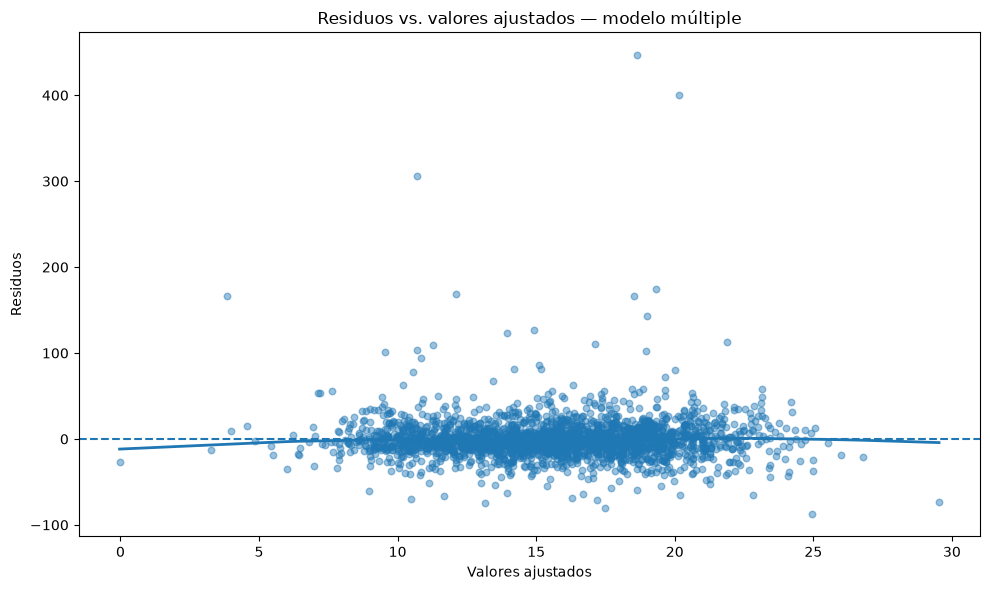

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\residuos_vs_ajustados_regresion_multiple.png


In [59]:
# ============================================================
# 10.2 Linealidad:
#      residuos vs. valores ajustados
# ============================================================

ajustados = modelo_mco.fittedvalues
residuos = modelo_mco.resid

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    ajustados,
    residuos,
    alpha=0.45,
    s=22
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5
)

# Curva LOWESS para detectar patrones sistemáticos
suavizado = lowess(
    residuos,
    ajustados,
    frac=0.30,
    return_sorted=True
)

ax.plot(
    suavizado[:, 0],
    suavizado[:, 1],
    linewidth=2
)

ax.set_xlabel("Valores ajustados")
ax.set_ylabel("Residuos")
ax.set_title(
    "Residuos vs. valores ajustados — modelo múltiple"
)

plt.tight_layout()

ruta_residuos_ajustados = (
    OUTPUT_DIR /
    "residuos_vs_ajustados_regresion_multiple.png"
)

plt.savefig(
    ruta_residuos_ajustados,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: "
    f"{ruta_residuos_ajustados}"
)

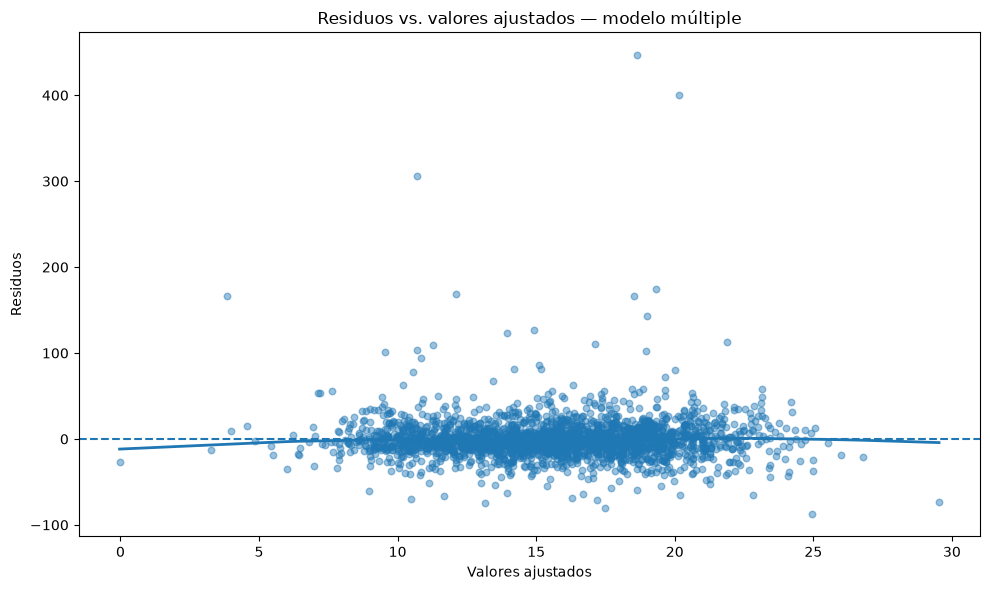

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\residuos_vs_ajustados_regresion_multiple.png


In [60]:
# ============================================================
# 10.2 Linealidad:
#      residuos vs. valores ajustados
# ============================================================

ajustados = modelo_mco.fittedvalues
residuos = modelo_mco.resid

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    ajustados,
    residuos,
    alpha=0.45,
    s=22
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5
)

# Curva LOWESS para detectar patrones sistemáticos
suavizado = lowess(
    residuos,
    ajustados,
    frac=0.30,
    return_sorted=True
)

ax.plot(
    suavizado[:, 0],
    suavizado[:, 1],
    linewidth=2
)

ax.set_xlabel("Valores ajustados")
ax.set_ylabel("Residuos")
ax.set_title(
    "Residuos vs. valores ajustados — modelo múltiple"
)

plt.tight_layout()

ruta_residuos_ajustados = (
    OUTPUT_DIR /
    "residuos_vs_ajustados_regresion_multiple.png"
)

plt.savefig(
    ruta_residuos_ajustados,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: "
    f"{ruta_residuos_ajustados}"
)

In [61]:
# ============================================================
# 10.4 Prueba de Breusch–Pagan / Koenker
# ============================================================

bp = het_breuschpagan(
    modelo_mco.resid,
    modelo_mco.model.exog,
    robust=True
)

lm_stat, lm_pvalue, f_stat_bp, f_pvalue_bp = bp

tabla_bp = pd.DataFrame({
    "Estadístico": [
        "LM Koenker",
        "F"
    ],
    "Valor": [
        lm_stat,
        f_stat_bp
    ],
    "Valor-p": [
        lm_pvalue,
        f_pvalue_bp
    ]
})

display(
    tabla_bp.round(6)
)

if lm_pvalue < 0.05:
    print(
        "\nResultado: se rechaza H0. "
        "Existe evidencia de heterocedasticidad."
    )
else:
    print(
        "\nResultado: no se rechaza H0. "
        "No existe evidencia estadística suficiente "
        "de heterocedasticidad."
    )

,Estadístico,Valor,Valor-p
0,LM Koenker,2.9731,0.5623
1,F,0.7426,0.5629



Resultado: no se rechaza H0. No existe evidencia estadística suficiente de heterocedasticidad.


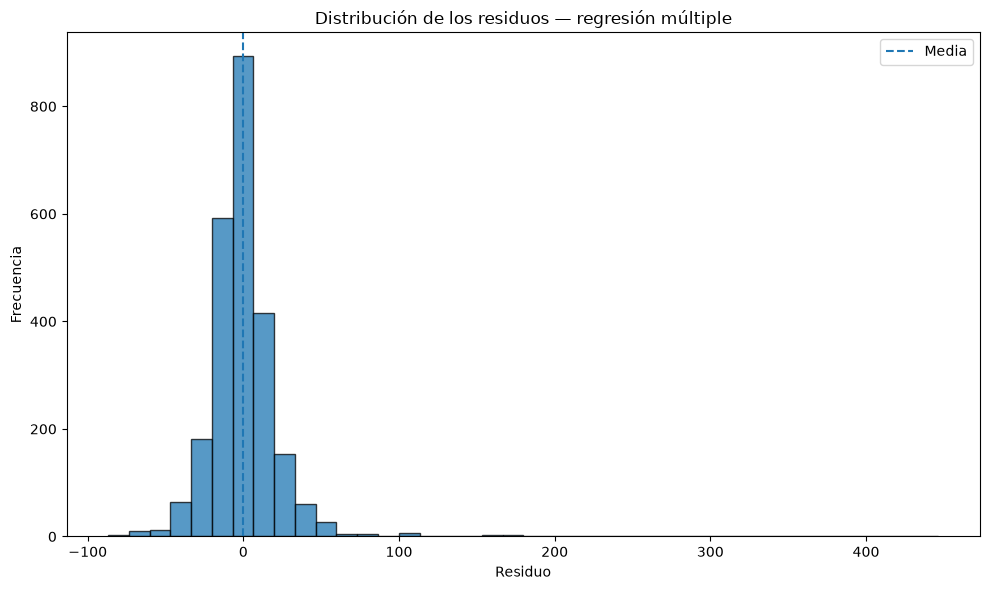

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\histograma_residuos_regresion_multiple.png


In [62]:
# ============================================================
# 10.5 Histograma de residuos
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    modelo_mco.resid,
    bins=40,
    edgecolor="black",
    alpha=0.75
)

ax.axvline(
    modelo_mco.resid.mean(),
    linestyle="--",
    linewidth=1.5,
    label="Media"
)

ax.set_xlabel("Residuo")
ax.set_ylabel("Frecuencia")

ax.set_title(
    "Distribución de los residuos — regresión múltiple"
)

ax.legend()

plt.tight_layout()

ruta_hist_residuos = (
    OUTPUT_DIR /
    "histograma_residuos_regresion_multiple.png"
)

plt.savefig(
    ruta_hist_residuos,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: "
    f"{ruta_hist_residuos}"
)

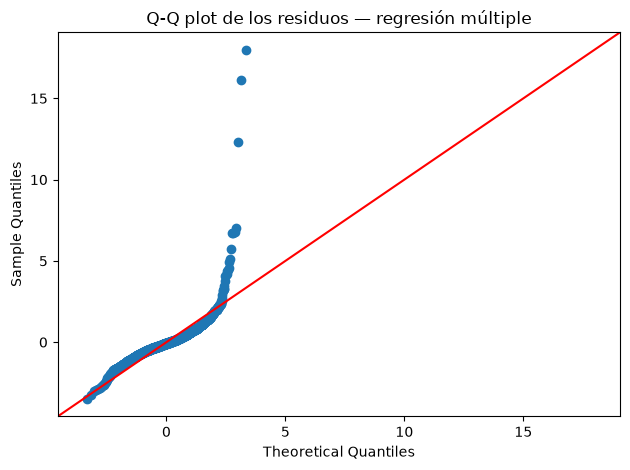

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\qqplot_residuos_regresion_multiple.png


In [63]:
# ============================================================
# 10.6 Q-Q plot de los residuos
# ============================================================

fig = sm.qqplot(
    modelo_mco.resid,
    line="45",
    fit=True
)

plt.title(
    "Q-Q plot de los residuos — regresión múltiple"
)

plt.tight_layout()

ruta_qq = (
    OUTPUT_DIR /
    "qqplot_residuos_regresion_multiple.png"
)

plt.savefig(
    ruta_qq,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: {ruta_qq}"
)

In [64]:
# ============================================================
# 10.7 Prueba de Shapiro-Wilk
# ============================================================

shapiro_stat, shapiro_p = stats.shapiro(
    modelo_mco.resid
)

print("PRUEBA DE SHAPIRO-WILK")
print("=" * 50)

print(
    f"Estadístico W: {shapiro_stat:.6f}"
)

print(
    f"Valor-p: {shapiro_p:.6e}"
)

if shapiro_p < 0.05:
    print(
        "\nResultado: se rechaza H0 de normalidad."
    )
else:
    print(
        "\nResultado: no se rechaza H0 de normalidad."
    )

PRUEBA DE SHAPIRO-WILK
Estadístico W: 0.708433
Valor-p: 4.396361e-54

Resultado: se rechaza H0 de normalidad.


In [65]:
# ============================================================
# 10.8 Jarque-Bera, asimetría y curtosis
# ============================================================

jb_stat, jb_p, skew_resid, kurt_resid = (
    jarque_bera(modelo_mco.resid)
)

tabla_normalidad = pd.DataFrame({
    "Indicador": [
        "Jarque-Bera",
        "Valor-p JB",
        "Asimetría",
        "Curtosis"
    ],
    "Resultado": [
        jb_stat,
        jb_p,
        skew_resid,
        kurt_resid
    ]
})

display(
    tabla_normalidad.round(4)
)

,Indicador,Resultado
0,Jarque-Bera,"729,940.8158"
1,Valor-p JB,0.0000
2,Asimetría,5.7869
3,Curtosis,86.9392


## 10.9. Alcance del supuesto de normalidad

La normalidad de los residuos no es una condición necesaria para obtener los coeficientes de MCO. Su relevancia se relaciona principalmente con determinadas propiedades de la inferencia estadística, especialmente en muestras pequeñas.

En una muestra amplia como la utilizada en este proyecto (\(N=2,440\)), las pruebas formales de normalidad pueden detectar desviaciones con facilidad. Por esta razón, sus resultados deben interpretarse conjuntamente con el histograma, el Q-Q plot, la asimetría y la curtosis.

Si se identifica una desviación importante de la normalidad, esto no implica automáticamente que deba descartarse el modelo. Será necesario valorar la presencia de observaciones extremas, la estabilidad de los coeficientes y el uso de métodos de inferencia robusta.

In [66]:
# ============================================================
# 10.10 Durbin-Watson
# ============================================================

dw = durbin_watson(
    modelo_mco.resid
)

print("DURBIN-WATSON")
print("=" * 50)

print(
    f"Estadístico Durbin-Watson: {dw:.4f}"
)

print(
    "\nReferencia interpretativa:"
    "\n  cercano a 2 -> ausencia de autocorrelación serial"
    "\n  cercano a 0 -> autocorrelación positiva"
    "\n  cercano a 4 -> autocorrelación negativa"
)

DURBIN-WATSON
Estadístico Durbin-Watson: 1.9100

Referencia interpretativa:
  cercano a 2 -> ausencia de autocorrelación serial
  cercano a 0 -> autocorrelación positiva
  cercano a 4 -> autocorrelación negativa


## 10.11. Interpretación de la independencia en datos municipales

El estadístico Durbin-Watson se reporta porque forma parte de los diagnósticos tradicionales de regresión y del criterio de evaluación del proyecto.

Sin embargo, su interpretación debe realizarse con cautela debido a que la base utilizada corresponde a datos de corte transversal municipal y no a una serie temporal.

En este contexto, un valor cercano a 2 indica que no se observa una señal evidente de autocorrelación serial asociada al orden de las observaciones. No obstante, este resultado no descarta la existencia de dependencia espacial.

Municipios geográficamente próximos pueden compartir mercados laborales, infraestructura, condiciones económicas o procesos comerciales. La evaluación formal de autocorrelación espacial requeriría información geográfica y pruebas específicas, como Moran's I, lo cual se encuentra fuera del alcance de la especificación actual.

In [68]:
# ============================================================
# 10.12 Resumen de pruebas de supuestos
# ============================================================

# ------------------------------------------------------------
# 1. RESET de Ramsey
# ------------------------------------------------------------

reset_test = linear_reset(
    modelo_mco,
    power=2,
    use_f=True
)

reset_f = float(np.asarray(reset_test.fvalue).squeeze())
reset_p = float(np.asarray(reset_test.pvalue).squeeze())

# ------------------------------------------------------------
# 2. Breusch-Pagan / Koenker
# ------------------------------------------------------------

bp = het_breuschpagan(
    modelo_mco.resid,
    modelo_mco.model.exog,
    robust=True
)

lm_stat, lm_pvalue, f_stat_bp, f_pvalue_bp = bp

# ------------------------------------------------------------
# 3. Shapiro-Wilk
# ------------------------------------------------------------

shapiro_stat, shapiro_p = stats.shapiro(
    modelo_mco.resid
)

# ------------------------------------------------------------
# 4. Jarque-Bera
# ------------------------------------------------------------

jb_stat, jb_p, skew_resid, kurt_resid = (
    jarque_bera(modelo_mco.resid)
)

# ------------------------------------------------------------
# 5. Durbin-Watson
# ------------------------------------------------------------

dw = durbin_watson(
    modelo_mco.resid
)

# ------------------------------------------------------------
# 6. Tabla resumen
# ------------------------------------------------------------

tabla_supuestos = pd.DataFrame({
    "Diagnóstico": [
        "RESET de Ramsey",
        "Breusch-Pagan/Koenker",
        "Shapiro-Wilk",
        "Jarque-Bera",
        "Durbin-Watson"
    ],

    "Estadístico": [
        reset_f,
        lm_stat,
        shapiro_stat,
        jb_stat,
        dw
    ],

    "Valor-p": [
        reset_p,
        lm_pvalue,
        shapiro_p,
        jb_p,
        np.nan
    ]
})

display(
    tabla_supuestos.round(6)
)

,Diagnóstico,Estadístico,Valor-p
0,RESET de Ramsey,0.8436,0.3585
1,Breusch-Pagan/Koenker,2.9731,0.5623
2,Shapiro-Wilk,0.7084,0.0000
3,Jarque-Bera,"729,940.8158",0.0000
4,Durbin-Watson,1.9100,NaN


Cierre de la Fase 10

La validación de los supuestos muestra resultados diferentes según el diagnóstico considerado. La prueba RESET de Ramsey no proporciona evidencia estadística de una mala especificación funcional (\(p=0.3585\)), mientras que la prueba de Breusch–Pagan/Koenker tampoco permite rechazar la hipótesis de varianza constante de los errores (\(p=0.5623\)).

El estadístico Durbin–Watson fue de 1.9100, valor próximo a 2 y compatible con ausencia de una señal relevante de autocorrelación serial. No obstante, debido a que las observaciones corresponden a municipios y no a una serie temporal, este resultado no permite descartar posibles patrones de dependencia espacial.

El supuesto que presenta la desviación más evidente es la normalidad de los residuos. La prueba de Shapiro–Wilk (\(p<0.001\)) y la prueba de Jarque–Bera (\(p<0.001\)) rechazan claramente la normalidad. Este resultado es consistente con una asimetría positiva de 5.7869, una curtosis de 86.9392 y con los patrones observados en el histograma y el Q-Q plot, particularmente en la cola derecha de la distribución.

En conjunto, los resultados no justifican descartar la especificación lineal ni sugieren un problema relevante de heterocedasticidad. Sin embargo, la fuerte no normalidad y la presencia visual de residuos extremos hacen necesario evaluar si determinados municipios ejercen una influencia desproporcionada sobre las estimaciones. Por esta razón, el siguiente paso consiste en realizar diagnósticos de influencia antes de establecer conclusiones definitivas sobre la estabilidad del modelo.

# FASE 11 — Diagnóstico de influencia

El análisis de residuos mostró la presencia de observaciones extremas, particularmente en la cola derecha de la distribución. Sin embargo, una observación extrema no necesariamente ejerce una influencia importante sobre los coeficientes de regresión.

Por esta razón, en esta fase se evalúa la influencia de cada municipio mediante cuatro diagnósticos complementarios:

1. residuos studentizados;
2. leverage;
3. distancia de Cook;
4. DFBETAS.

Cada indicador evalúa un aspecto diferente. Los residuos studentizados identifican observaciones con errores particularmente grandes; el leverage mide qué tan alejadas se encuentran las características explicativas de una observación respecto al resto de la muestra; la distancia de Cook combina información sobre residuo y leverage; y DFBETAS mide cuánto cambia cada coeficiente cuando una observación es excluida temporalmente.

Los puntos de corte utilizados funcionan como criterios de detección y no como reglas automáticas para eliminar municipios. Las observaciones identificadas se conservarán en el modelo principal y posteriormente se realizará un análisis de sensibilidad para evaluar la estabilidad de los resultados.

In [69]:
# ============================================================
# FASE 11 — DIAGNÓSTICO DE INFLUENCIA
# 11.1 Obtención de medidas de influencia
# ============================================================

influencia = modelo_mco.get_influence()

# Residuos studentizados externos
resid_student = influencia.resid_studentized_external

# Leverage
leverage = influencia.hat_matrix_diag

# Distancia de Cook
cooks_d, cooks_p = influencia.cooks_distance

# DFBETAS para todos los parámetros
dfbetas_array = influencia.dfbetas

print("Medidas de influencia calculadas correctamente.")

Medidas de influencia calculadas correctamente.


In [71]:
# ============================================================
# 11.2 Construcción de la base de diagnóstico
# ============================================================

df_influencia = df_estimacion[
    [
        "CVEGEO",
        "entidad",
        "municipio",
        Y
    ]
].copy()

df_influencia["Y_AJUSTADO"] = modelo_mco.fittedvalues.to_numpy()
df_influencia["RESIDUO"] = modelo_mco.resid.to_numpy()

df_influencia["RESIDUO_STUDENT"] = np.asarray(resid_student)
df_influencia["LEVERAGE"] = np.asarray(leverage)
df_influencia["COOK_D"] = np.asarray(cooks_d)

# DFBETAS
nombres_parametros = list(modelo_mco.params.index)

df_dfbetas = pd.DataFrame(
    dfbetas_array,
    columns=nombres_parametros,
    index=df_estimacion.index
)

# Para el diagnóstico principal nos interesa la influencia
# sobre las cuatro pendientes.
df_influencia["DFBETAS_MAX"] = (
    df_dfbetas[X]
    .abs()
    .max(axis=1)
    .to_numpy()
)

df_influencia["VARIABLE_DFBETAS_MAX"] = (
    df_dfbetas[X]
    .abs()
    .idxmax(axis=1)
    .to_numpy()
)

display(df_influencia.head())

,CVEGEO,entidad,municipio,CREC_DENSIDAD_RETAIL_2020_2025,Y_AJUSTADO,RESIDUO,RESIDUO_STUDENT,LEVERAGE,COOK_D,DFBETAS_MAX,VARIABLE_DFBETAS_MAX
0,01001,AGUASCALIENTES,Aguascalientes,5.3615,9.2338,-3.8723,-0.1560,0.0030,0.0000,0.0042,TASA_INFORMALIDAD_2020
1,01002,AGUASCALIENTES,Asientos,28.3271,11.3516,16.9755,0.6834,0.0011,0.0001,0.0139,POBREZA_2020
2,01003,AGUASCALIENTES,Calvillo,10.0970,11.8556,-1.7586,-0.0708,0.0014,0.0000,0.0017,TASA_INFORMALIDAD_2020
3,01004,AGUASCALIENTES,Cosío,39.7279,10.1253,29.6026,1.1924,0.0018,0.0005,0.0312,TASA_INFORMALIDAD_2020
4,01005,AGUASCALIENTES,Jesús María,11.7619,8.9714,2.7906,0.1124,0.0023,0.0000,0.0023,TASA_INFORMALIDAD_2020


In [72]:
# ============================================================
# 11.3 Umbrales orientativos de influencia
# ============================================================

n = int(modelo_mco.nobs)
p = len(modelo_mco.params)   # Incluye intercepto

lim_student = 3
lim_leverage = 2 * p / n
lim_cook = 4 / n
lim_dfbetas = 2 / np.sqrt(n)

tabla_umbrales = pd.DataFrame({
    "Diagnóstico": [
        "|Residuo studentizado|",
        "Leverage",
        "Cook's D",
        "|DFBETAS|"
    ],
    "Criterio": [
        "> 3",
        "2p/n",
        "4/n",
        "2/sqrt(n)"
    ],
    "Umbral": [
        lim_student,
        lim_leverage,
        lim_cook,
        lim_dfbetas
    ]
})

display(tabla_umbrales.round(6))

,Diagnóstico,Criterio,Umbral
0,|Residuo studentizado|,> 3,3.0000
1,Leverage,2p/n,0.0041
2,Cook's D,4/n,0.0016
3,|DFBETAS|,2/sqrt(n),0.0405


In [73]:
# ============================================================
# 11.4 Flags de observaciones potencialmente influyentes
# ============================================================

df_influencia["FLAG_STUDENT"] = (
    df_influencia["RESIDUO_STUDENT"].abs()
    > lim_student
)

df_influencia["FLAG_LEVERAGE"] = (
    df_influencia["LEVERAGE"]
    > lim_leverage
)

df_influencia["FLAG_COOK"] = (
    df_influencia["COOK_D"]
    > lim_cook
)

df_influencia["FLAG_DFBETAS"] = (
    df_influencia["DFBETAS_MAX"]
    > lim_dfbetas
)

df_influencia["FLAG_CUALQUIERA"] = (
    df_influencia[
        [
            "FLAG_STUDENT",
            "FLAG_LEVERAGE",
            "FLAG_COOK",
            "FLAG_DFBETAS"
        ]
    ]
    .any(axis=1)
)

resumen_influencia = pd.DataFrame({
    "Criterio": [
        "Residuo studentizado",
        "Leverage",
        "Cook's D",
        "DFBETAS",
        "Al menos un criterio"
    ],

    "N municipios": [
        df_influencia["FLAG_STUDENT"].sum(),
        df_influencia["FLAG_LEVERAGE"].sum(),
        df_influencia["FLAG_COOK"].sum(),
        df_influencia["FLAG_DFBETAS"].sum(),
        df_influencia["FLAG_CUALQUIERA"].sum()
    ]
})

resumen_influencia["% muestra"] = (
    100 * resumen_influencia["N municipios"] / n
)

display(resumen_influencia.round(4))

,Criterio,N municipios,% muestra
0,Residuo studentizado,24,0.9836
1,Leverage,160,6.5574
2,Cook's D,90,3.6885
3,DFBETAS,239,9.7951
4,Al menos un criterio,337,13.8115


In [74]:
# ============================================================
# 11.5 Valores máximos de influencia
# ============================================================

print("VALORES MÁXIMOS DE LOS DIAGNÓSTICOS")
print("=" * 55)

print(
    "Máximo |residuo studentizado|:",
    f"{df_influencia['RESIDUO_STUDENT'].abs().max():.4f}"
)

print(
    "Máximo leverage:",
    f"{df_influencia['LEVERAGE'].max():.6f}"
)

print(
    "Máximo Cook's D:",
    f"{df_influencia['COOK_D'].max():.6f}"
)

print(
    "Máximo |DFBETAS|:",
    f"{df_influencia['DFBETAS_MAX'].max():.6f}"
)

VALORES MÁXIMOS DE LOS DIAGNÓSTICOS
Máximo |residuo studentizado|: 19.3041
Máximo leverage: 0.018155
Máximo Cook's D: 0.078790
Máximo |DFBETAS|: 0.495073


In [75]:
# ============================================================
# 11.6 Municipios con mayor Cook's Distance
# ============================================================

top_cook = (
    df_influencia[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            Y,
            "Y_AJUSTADO",
            "RESIDUO_STUDENT",
            "LEVERAGE",
            "COOK_D",
            "DFBETAS_MAX"
        ]
    ]
    .sort_values(
        "COOK_D",
        ascending=False
    )
    .head(15)
)

display(top_cook.round(4))

,CVEGEO,entidad,municipio,CREC_DENSIDAD_RETAIL_2020_2025,Y_AJUSTADO,RESIDUO_STUDENT,LEVERAGE,COOK_D,DFBETAS_MAX
1704,21148,PUEBLA,Santa Isabel Cholula,465.2009,18.6493,19.3041,0.0012,0.0788,0.4951
1926,26054,SONORA,San Javier,170.1428,3.8527,6.7795,0.0077,0.0704,0.4250
1997,28036,TAMAULIPAS,San Nicolás,420.0000,20.1363,17.0295,0.0012,0.0637,0.2660
945,19010,NUEVO LEÓN,El Carmen,317.0675,10.6863,12.7420,0.0017,0.0522,0.2333
433,12078,GUERRERO,Cochoapa el Grande,110.8380,9.5326,4.1167,0.0130,0.0442,0.3807
2276,31001,YUCATÁN,Abalá,193.2865,19.3124,7.0812,0.0028,0.0279,0.3110
1776,22003,QUERÉTARO,Arroyo Seco,180.3117,12.0937,6.8419,0.0027,0.0248,0.2516
1467,20481,OAXACA,Santiago Nuyoó,136.8722,13.9526,4.9794,0.0036,0.0176,0.2358
98,07024,CHIAPAS,Chanal,63.8973,7.6209,2.2835,0.0147,0.0156,0.2616
1510,20524,OAXACA,Santo Domingo Yodohino,-43.5320,29.5356,-2.9574,0.0084,0.0148,0.2454


In [76]:
# ============================================================
# 11.7 Municipios con mayor DFBETAS
# ============================================================

top_dfbetas = (
    df_influencia[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "DFBETAS_MAX",
            "VARIABLE_DFBETAS_MAX",
            "COOK_D",
            "LEVERAGE",
            "RESIDUO_STUDENT"
        ]
    ]
    .sort_values(
        "DFBETAS_MAX",
        ascending=False
    )
    .head(15)
)

display(top_dfbetas.round(4))

,CVEGEO,entidad,municipio,DFBETAS_MAX,VARIABLE_DFBETAS_MAX,COOK_D,LEVERAGE,RESIDUO_STUDENT
1704,21148,PUEBLA,Santa Isabel Cholula,0.4951,POBREZA_2020,0.0788,0.0012,19.3041
1926,26054,SONORA,San Javier,0.4250,TASA_INFORMALIDAD_2020,0.0704,0.0077,6.7795
433,12078,GUERRERO,Cochoapa el Grande,0.3807,RAZ_DEP_2020,0.0442,0.0130,4.1167
2276,31001,YUCATÁN,Abalá,0.3110,GRAPROES_2020,0.0279,0.0028,7.0812
1997,28036,TAMAULIPAS,San Nicolás,0.2660,RAZ_DEP_2020,0.0637,0.0012,17.0295
98,07024,CHIAPAS,Chanal,0.2616,RAZ_DEP_2020,0.0156,0.0147,2.2835
1776,22003,QUERÉTARO,Arroyo Seco,0.2516,TASA_INFORMALIDAD_2020,0.0248,0.0027,6.8419
1510,20524,OAXACA,Santo Domingo Yodohino,0.2454,RAZ_DEP_2020,0.0148,0.0084,-2.9574
1467,20481,OAXACA,Santiago Nuyoó,0.2358,RAZ_DEP_2020,0.0176,0.0036,4.9794
945,19010,NUEVO LEÓN,El Carmen,0.2333,TASA_INFORMALIDAD_2020,0.0522,0.0017,12.7420


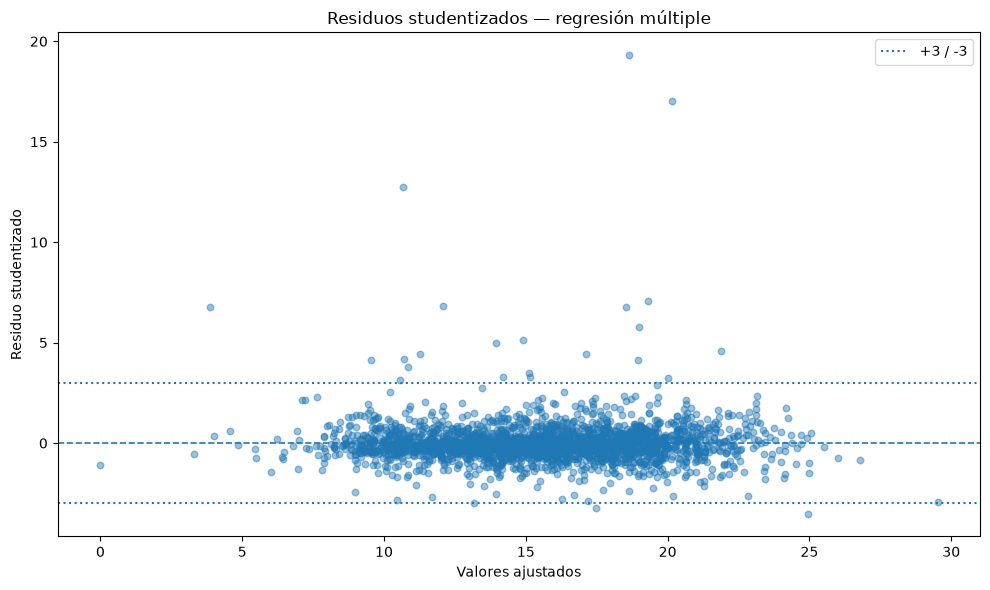

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\residuos_studentizados_regresion_multiple.png


In [77]:
# ============================================================
# 11.8 Residuos studentizados vs. valores ajustados
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_influencia["Y_AJUSTADO"],
    df_influencia["RESIDUO_STUDENT"],
    alpha=0.45,
    s=22
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.axhline(
    3,
    linestyle=":",
    linewidth=1.5,
    label="+3 / -3"
)

ax.axhline(
    -3,
    linestyle=":",
    linewidth=1.5
)

ax.set_xlabel("Valores ajustados")
ax.set_ylabel("Residuo studentizado")

ax.set_title(
    "Residuos studentizados — regresión múltiple"
)

ax.legend()

plt.tight_layout()

ruta_student = (
    OUTPUT_DIR /
    "residuos_studentizados_regresion_multiple.png"
)

plt.savefig(
    ruta_student,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfica guardada en: {ruta_student}")

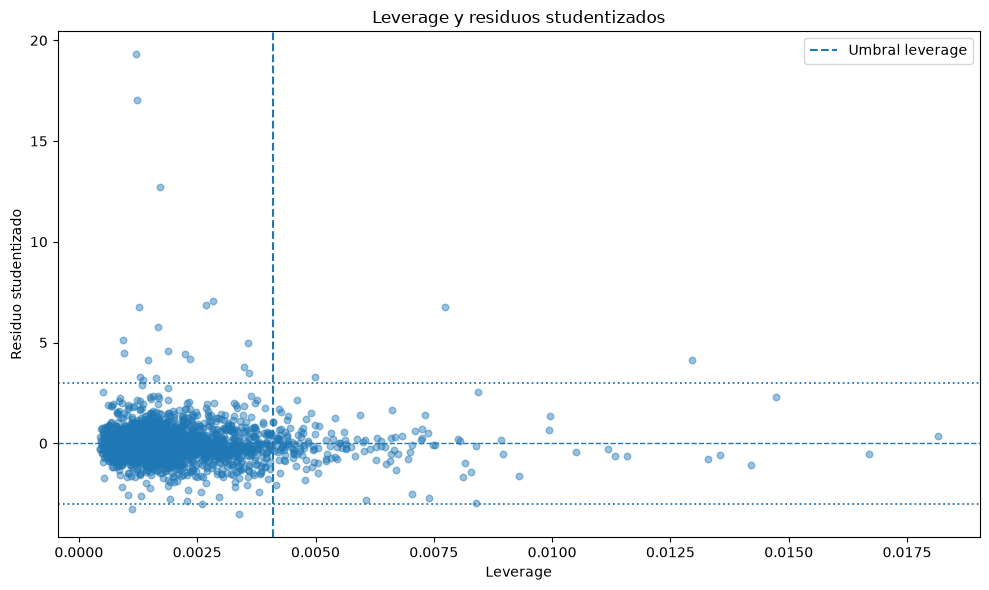

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\leverage_residuos_regresion_multiple.png


In [78]:
# ============================================================
# 11.9 Leverage vs. residuos studentizados
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df_influencia["LEVERAGE"],
    df_influencia["RESIDUO_STUDENT"],
    alpha=0.45,
    s=22
)

ax.axvline(
    lim_leverage,
    linestyle="--",
    linewidth=1.5,
    label="Umbral leverage"
)

ax.axhline(
    3,
    linestyle=":",
    linewidth=1.3
)

ax.axhline(
    -3,
    linestyle=":",
    linewidth=1.3
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("Leverage")
ax.set_ylabel("Residuo studentizado")

ax.set_title(
    "Leverage y residuos studentizados"
)

ax.legend()

plt.tight_layout()

ruta_leverage = (
    OUTPUT_DIR /
    "leverage_residuos_regresion_multiple.png"
)

plt.savefig(
    ruta_leverage,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfica guardada en: {ruta_leverage}")

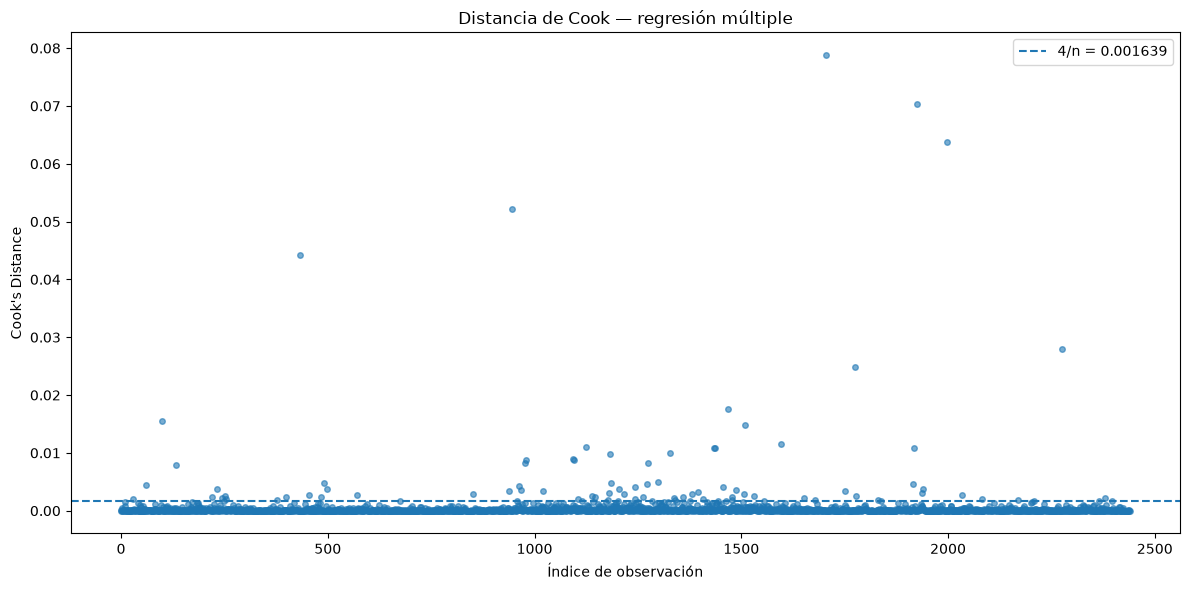

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\cooks_distance_regresion_multiple.png


In [79]:
# ============================================================
# 11.10 Distancia de Cook
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    np.arange(n),
    df_influencia["COOK_D"],
    s=16,
    alpha=0.60
)

ax.axhline(
    lim_cook,
    linestyle="--",
    linewidth=1.5,
    label=f"4/n = {lim_cook:.6f}"
)

ax.set_xlabel("Índice de observación")
ax.set_ylabel("Cook's Distance")

ax.set_title(
    "Distancia de Cook — regresión múltiple"
)

ax.legend()

plt.tight_layout()

ruta_cook = (
    OUTPUT_DIR /
    "cooks_distance_regresion_multiple.png"
)

plt.savefig(
    ruta_cook,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfica guardada en: {ruta_cook}")

## 11.11. Diferencia entre observación extrema e influyente

Una observación con un residuo muy grande no necesariamente modifica de manera importante los coeficientes del modelo.

De manera similar, una observación con leverage elevado no necesariamente es problemática si se ajusta razonablemente bien a la relación estimada.

La influencia depende de la combinación entre la posición de la observación en el espacio de las variables explicativas y su discrepancia respecto al valor predicho.

Por esta razón, los residuos studentizados, leverage, distancia de Cook y DFBETAS se analizan de manera complementaria y no como criterios independientes para eliminar observaciones.

In [80]:
# ============================================================
# 11.12 Análisis de sensibilidad basado en DFBETAS
# ============================================================

indices_influyentes_dfbetas = (
    df_influencia.index[
        df_influencia["FLAG_DFBETAS"]
    ]
)

df_sensibilidad = (
    df_estimacion
    .drop(index=indices_influyentes_dfbetas)
    .copy()
)

modelo_sensibilidad = smf.ols(
    formula=formula_modelo,
    data=df_sensibilidad
).fit()

print("ANÁLISIS DE SENSIBILIDAD")
print("=" * 55)

print(
    f"Muestra original: "
    f"{len(df_estimacion):,}"
)

print(
    f"Observaciones excluidas temporalmente: "
    f"{len(indices_influyentes_dfbetas):,}"
)

print(
    f"Muestra de sensibilidad: "
    f"{len(df_sensibilidad):,}"
)

ANÁLISIS DE SENSIBILIDAD
Muestra original: 2,440
Observaciones excluidas temporalmente: 239
Muestra de sensibilidad: 2,201


In [81]:
# ============================================================
# 11.13 Comparación:
#       modelo completo vs. sensibilidad
# ============================================================

comparacion_sensibilidad = []

for variable in X:

    beta_original = modelo_mco.params[variable]
    beta_sens = modelo_sensibilidad.params[variable]

    p_original = modelo_mco.pvalues[variable]
    p_sens = modelo_sensibilidad.pvalues[variable]

    comparacion_sensibilidad.append({
        "Variable": variable,
        "Beta original": beta_original,
        "Beta sensibilidad": beta_sens,
        "Cambio beta": beta_sens - beta_original,
        "p original": p_original,
        "p sensibilidad": p_sens,
        "Signo estable": (
            np.sign(beta_original)
            == np.sign(beta_sens)
        )
    })

tabla_sensibilidad = pd.DataFrame(
    comparacion_sensibilidad
)

display(
    tabla_sensibilidad.round(4)
)

,Variable,Beta original,Beta sensibilidad,Cambio beta,p original,p sensibilidad,Signo estable
0,RAZ_DEP_2020,-0.3247,-0.2758,0.0490,0.0000,0.0000,True
1,GRAPROES_2020,-1.1026,-1.0016,0.1010,0.0742,0.0117,True
2,TASA_INFORMALIDAD_2020,0.0626,0.0856,0.0230,0.2844,0.0219,True
3,POBREZA_2020,0.1357,0.1510,0.0153,0.0001,0.0000,True


In [82]:
# ============================================================
# 11.14 Comparación del ajuste
# ============================================================

tabla_ajuste_sensibilidad = pd.DataFrame({
    "Modelo": [
        "Muestra completa",
        "Sensibilidad sin casos DFBETAS"
    ],

    "N": [
        int(modelo_mco.nobs),
        int(modelo_sensibilidad.nobs)
    ],

    "R²": [
        modelo_mco.rsquared,
        modelo_sensibilidad.rsquared
    ],

    "R² ajustado": [
        modelo_mco.rsquared_adj,
        modelo_sensibilidad.rsquared_adj
    ],

    "F": [
        modelo_mco.fvalue,
        modelo_sensibilidad.fvalue
    ],

    "p F": [
        modelo_mco.f_pvalue,
        modelo_sensibilidad.f_pvalue
    ]
})

display(
    tabla_ajuste_sensibilidad.round(4)
)

,Modelo,N,R²,R² ajustado,F,p F
0,Muestra completa,2440,0.0215,0.0199,13.3571,0.0000
1,Sensibilidad sin casos DFBETAS,2201,0.0734,0.0717,43.4581,0.0000


## 11.15. Uso del análisis de sensibilidad

La estimación realizada después de excluir temporalmente observaciones identificadas mediante DFBETAS no sustituye al modelo principal.

Su propósito es determinar si las conclusiones dependen de un grupo reducido de municipios con influencia elevada.

El modelo principal continúa utilizando la muestra completa de 2,440 municipios, salvo que existiera evidencia clara de errores de medición o problemas de calidad de datos que justificaran excluir observaciones.

Si los coeficientes mantienen signos y conclusiones similares en el análisis de sensibilidad, se considerará que los resultados presentan una estabilidad razonable frente a las observaciones influyentes.

Cierre de la Fase 11

El diagnóstico de influencia confirma la presencia de municipios con comportamientos alejados de los patrones predominantes de la muestra. Se identificaron 24 observaciones con residuos studentizados superiores a \(|3|\), 160 con leverage elevado, 90 mediante el criterio de distancia de Cook y 239 mediante DFBETAS. En total, 337 municipios cumplen al menos uno de los criterios de revisión.

Los diagnósticos no justifican la eliminación automática de estas observaciones. Los casos identificados pueden representar dinámicas municipales reales y su exclusión modificaría de manera importante la muestra analizada. Por esta razón, las 2,440 observaciones se conservan en el modelo principal.

El análisis de sensibilidad, realizado mediante la exclusión temporal de los 239 casos señalados por DFBETAS, muestra que los signos de los cuatro coeficientes permanecen estables. La razón de dependencia y la escolaridad mantienen asociaciones negativas, mientras que informalidad y pobreza conservan asociaciones positivas.

No obstante, la significancia estadística presenta mayor sensibilidad. Escolaridad pasa de \(p=0.0742\) a \(p=0.0117\), mientras que informalidad cambia de \(p=0.2844\) a \(p=0.0219\). Dependencia y pobreza permanecen estadísticamente significativas en ambas estimaciones.

También se observa un incremento del \(R^2\), de 0.0215 a 0.0734, al retirar temporalmente los casos influyentes. Este cambio confirma que determinados municipios contribuyen de manera importante a la dispersión que el modelo tiene dificultades para representar. Sin embargo, la regresión de sensibilidad no sustituye al modelo principal, ya que su finalidad es únicamente evaluar la estabilidad de las estimaciones.

En conjunto, los resultados muestran una estabilidad razonable en la dirección de las asociaciones, pero una sensibilidad mayor en la inferencia correspondiente a escolaridad e informalidad. Por ello, resulta necesario complementar la evaluación con errores estándar robustos antes de establecer las conclusiones inferenciales finales.

# FASE 12 — Inferencia robusta HC3

El objetivo de esta fase es evaluar la estabilidad de la inferencia estadística mediante errores estándar robustos HC3.

La estimación por Mínimos Cuadrados Ordinarios proporciona los mismos coeficientes independientemente de que se utilice la matriz de covarianza convencional o una matriz robusta. Lo que cambia es la estimación de la incertidumbre asociada a dichos coeficientes y, por tanto, sus errores estándar, estadísticos \(t\), valores-p e intervalos de confianza.

Aunque la prueba de Breusch–Pagan/Koenker no proporcionó evidencia estadística de heterocedasticidad en el modelo múltiple, el análisis previo mostró residuos fuertemente no normales y observaciones influyentes. Por esta razón, HC3 se utiliza como una comprobación adicional de robustez inferencial.

La finalidad no es sustituir automáticamente la estimación convencional, sino determinar si las conclusiones sobre significancia estadística permanecen estables bajo una estimación más resistente de la matriz de covarianza.

## 12.1. Errores estándar robustos HC3

Los errores estándar HC3 pertenecen a la familia de estimadores de covarianza robustos frente a heterocedasticidad.

A diferencia de los errores estándar convencionales, HC3 incorpora una corrección relacionada con el leverage de cada observación. De forma simplificada, utiliza términos del tipo:

\[
\frac{e_i^2}{(1-h_{ii})^2}
\]

donde \(e_i\) es el residuo de la observación y \(h_{ii}\) representa su leverage.

Esta corrección hace que las observaciones con mayor leverage reciban un tratamiento más conservador al calcular la incertidumbre de los coeficientes.

Es importante señalar que HC3 no modifica los coeficientes estimados mediante MCO. Su efecto se concentra en los errores estándar, los estadísticos de prueba, los valores-p y los intervalos de confianza.

In [83]:
# ============================================================
# FASE 12 — INFERENCIA ROBUSTA HC3
# 12.2 Estimación con matriz de covarianza HC3
# ============================================================

modelo_hc3 = modelo_mco.get_robustcov_results(
    cov_type="HC3"
)

print("Inferencia robusta HC3 calculada correctamente.")
print(f"Tipo de covarianza: {modelo_hc3.cov_type}")

Inferencia robusta HC3 calculada correctamente.
Tipo de covarianza: HC3


In [84]:
# ============================================================
# 12.3 Resultados de la inferencia robusta HC3
# ============================================================

nombres_parametros = modelo_mco.params.index

params_hc3 = pd.Series(
    modelo_hc3.params,
    index=nombres_parametros
)

se_hc3 = pd.Series(
    modelo_hc3.bse,
    index=nombres_parametros
)

t_hc3 = pd.Series(
    modelo_hc3.tvalues,
    index=nombres_parametros
)

p_hc3 = pd.Series(
    modelo_hc3.pvalues,
    index=nombres_parametros
)

ic_hc3_array = modelo_hc3.conf_int(alpha=0.05)

ic_hc3 = pd.DataFrame(
    ic_hc3_array,
    index=nombres_parametros,
    columns=[
        "IC 95% inferior",
        "IC 95% superior"
    ]
)

tabla_hc3 = pd.DataFrame({
    "Coeficiente": params_hc3,
    "SE HC3": se_hc3,
    "t HC3": t_hc3,
    "Valor-p HC3": p_hc3,
    "IC 95% inferior": ic_hc3["IC 95% inferior"],
    "IC 95% superior": ic_hc3["IC 95% superior"]
})

tabla_hc3.index.name = "Parámetro"

display(
    tabla_hc3.round(4)
)

,Coeficiente,SE HC3,t HC3,Valor-p HC3,IC 95% inferior,IC 95% superior
Parámetro,,,,,,
Intercept,31.1577,9.2870,3.3550,0.0008,12.9465,49.3689
RAZ_DEP_2020,-0.3247,0.0856,-3.7913,0.0002,-0.4927,-0.1568
GRAPROES_2020,-1.1026,0.5537,-1.9915,0.0465,-2.1883,-0.0169
TASA_INFORMALIDAD_2020,0.0626,0.0638,0.9811,0.3266,-0.0625,0.1878
POBREZA_2020,0.1357,0.0373,3.6332,0.0003,0.0625,0.2089


In [85]:
# ============================================================
# 12.4 Comparación de inferencia convencional vs. HC3
# ============================================================

comparacion_hc3 = []

for variable in X:

    comparacion_hc3.append({
        "Variable": variable,

        "Beta": modelo_mco.params[variable],

        "SE convencional":
            modelo_mco.bse[variable],

        "SE HC3":
            se_hc3[variable],

        "p convencional":
            modelo_mco.pvalues[variable],

        "p HC3":
            p_hc3[variable],

        "Significativa convencional":
            "Sí" if modelo_mco.pvalues[variable] < 0.05 else "No",

        "Significativa HC3":
            "Sí" if p_hc3[variable] < 0.05 else "No"
    })

tabla_comparacion_hc3 = pd.DataFrame(
    comparacion_hc3
)

display(
    tabla_comparacion_hc3.round(4)
)

,Variable,Beta,SE convencional,SE HC3,p convencional,p HC3,Significativa convencional,Significativa HC3
0,RAZ_DEP_2020,-0.3247,0.0718,0.0856,0.0000,0.0002,Sí,Sí
1,GRAPROES_2020,-1.1026,0.6172,0.5537,0.0742,0.0465,No,Sí
2,TASA_INFORMALIDAD_2020,0.0626,0.0585,0.0638,0.2844,0.3266,No,No
3,POBREZA_2020,0.1357,0.0353,0.0373,0.0001,0.0003,Sí,Sí


In [86]:
# ============================================================
# 12.5 Cambio de los errores estándar
# ============================================================

tabla_cambio_se = pd.DataFrame({
    "Variable": X,

    "SE convencional": [
        modelo_mco.bse[var]
        for var in X
    ],

    "SE HC3": [
        se_hc3[var]
        for var in X
    ]
})

tabla_cambio_se["Razón HC3 / convencional"] = (
    tabla_cambio_se["SE HC3"]
    / tabla_cambio_se["SE convencional"]
)

tabla_cambio_se["Cambio SE (%)"] = (
    (
        tabla_cambio_se[
            "Razón HC3 / convencional"
        ] - 1
    ) * 100
)

display(
    tabla_cambio_se.round(4)
)

,Variable,SE convencional,SE HC3,Razón HC3 / convencional,Cambio SE (%)
0,RAZ_DEP_2020,0.0718,0.0856,1.1933,19.3323
1,GRAPROES_2020,0.6172,0.5537,0.8970,-10.3003
2,TASA_INFORMALIDAD_2020,0.0585,0.0638,1.0913,9.1302
3,POBREZA_2020,0.0353,0.0373,1.0576,5.7624


In [87]:
# ============================================================
# 12.6 Prueba conjunta robusta HC3
# ============================================================

nombres = list(modelo_mco.params.index)

R = np.zeros(
    (len(X), len(nombres))
)

for fila, variable in enumerate(X):
    columna = nombres.index(variable)
    R[fila, columna] = 1

prueba_global_hc3 = modelo_hc3.f_test(R)

f_hc3 = float(
    np.asarray(
        prueba_global_hc3.fvalue
    ).squeeze()
)

p_f_hc3 = float(
    np.asarray(
        prueba_global_hc3.pvalue
    ).squeeze()
)

print("PRUEBA GLOBAL ROBUSTA HC3")
print("=" * 50)

print(f"F robusto: {f_hc3:.4f}")
print(f"Valor-p robusto: {p_f_hc3:.6e}")

if p_f_hc3 < 0.05:
    print(
        "\nDecisión: rechazar H0. "
        "El conjunto de pendientes es "
        "estadísticamente significativo."
    )
else:
    print(
        "\nDecisión: no rechazar H0."
    )

PRUEBA GLOBAL ROBUSTA HC3
F robusto: 9.7093
Valor-p robusto: 8.642500e-08

Decisión: rechazar H0. El conjunto de pendientes es estadísticamente significativo.


In [88]:
# ============================================================
# 12.7 Comparación de intervalos de confianza
# ============================================================

ic_conv = modelo_mco.conf_int(alpha=0.05)

comparacion_ic = []

for variable in X:

    comparacion_ic.append({
        "Variable": variable,

        "IC conv. inferior":
            ic_conv.loc[variable, 0],

        "IC conv. superior":
            ic_conv.loc[variable, 1],

        "IC HC3 inferior":
            ic_hc3.loc[
                variable,
                "IC 95% inferior"
            ],

        "IC HC3 superior":
            ic_hc3.loc[
                variable,
                "IC 95% superior"
            ]
    })

tabla_ic_comparacion = pd.DataFrame(
    comparacion_ic
)

display(
    tabla_ic_comparacion.round(4)
)

,Variable,IC conv. inferior,IC conv. superior,IC HC3 inferior,IC HC3 superior
0,RAZ_DEP_2020,-0.4655,-0.1840,-0.4927,-0.1568
1,GRAPROES_2020,-2.3130,0.1078,-2.1883,-0.0169
2,TASA_INFORMALIDAD_2020,-0.0521,0.1773,-0.0625,0.1878
3,POBREZA_2020,0.0664,0.2049,0.0625,0.2089


In [89]:
# ============================================================
# 12.8 Comparación inferencial:
#      MCO, HC3 y análisis de sensibilidad
# ============================================================

comparacion_final_inferencia = []

for variable in X:

    comparacion_final_inferencia.append({
        "Variable": variable,

        "Beta principal":
            modelo_mco.params[variable],

        "p MCO":
            modelo_mco.pvalues[variable],

        "p HC3":
            p_hc3[variable],

        "Beta sensibilidad":
            modelo_sensibilidad.params[variable],

        "p sensibilidad":
            modelo_sensibilidad.pvalues[variable]
    })

tabla_inferencia_integrada = pd.DataFrame(
    comparacion_final_inferencia
)

display(
    tabla_inferencia_integrada.round(4)
)

,Variable,Beta principal,p MCO,p HC3,Beta sensibilidad,p sensibilidad
0,RAZ_DEP_2020,-0.3247,0.0000,0.0002,-0.2758,0.0000
1,GRAPROES_2020,-1.1026,0.0742,0.0465,-1.0016,0.0117
2,TASA_INFORMALIDAD_2020,0.0626,0.2844,0.3266,0.0856,0.0219
3,POBREZA_2020,0.1357,0.0001,0.0003,0.1510,0.0000


Cierre de la Fase 12

La estimación con errores estándar robustos HC3 mantiene sin cambios los coeficientes del modelo, pero modifica la estimación de su incertidumbre. La prueba conjunta robusta continúa rechazando la hipótesis de que todas las pendientes sean simultáneamente iguales a cero (\(F=9.7093\), \(p<0.001\)), por lo que la significancia global del modelo permanece estable.

A nivel individual, la razón de dependencia conserva una asociación negativa y estadísticamente significativa (\(p=0.0002\)), mientras que pobreza mantiene una asociación positiva y significativa (\(p=0.0003\)). Estos dos resultados muestran la mayor estabilidad frente a los distintos procedimientos de inferencia utilizados.

La escolaridad presenta un resultado más sensible. Bajo la inferencia convencional su valor-p es 0.0742, mientras que con HC3 disminuye a 0.0465 y su intervalo de confianza deja de incluir cero. El análisis de sensibilidad también encuentra una asociación negativa significativa. Por ello, la evidencia sobre escolaridad es consistente en dirección, aunque su significancia depende parcialmente del procedimiento inferencial.

La informalidad continúa sin ser estadísticamente significativa en la muestra completa tanto con errores convencionales (\(p=0.2844\)) como con HC3 (\(p=0.3266\)). Su significancia aparece únicamente en el análisis que excluye temporalmente observaciones identificadas mediante DFBETAS, por lo que su conclusión debe considerarse sensible a la composición de la muestra.

En conjunto, la inferencia robusta confirma que dependencia y pobreza presentan los resultados más estables. Escolaridad mantiene una asociación negativa con evidencia estadística menos sólida, mientras que informalidad no presenta evidencia suficiente de una asociación parcial distinta de cero en el modelo principal.

HC3 no corrige la fuerte no normalidad de los residuos ni elimina la influencia de observaciones extremas; su función en este análisis es comprobar la estabilidad de la inferencia manteniendo la muestra completa de 2,440 municipios.

# FASE 13 — Comparación entre regresión simple y regresión múltiple

El objetivo de esta fase es comparar los resultados obtenidos mediante regresiones lineales simples con los correspondientes al modelo de regresión múltiple.

Las regresiones simples permiten conocer la asociación bivariada entre cada predictor y el crecimiento de la densidad comercial. En cambio, los coeficientes del modelo múltiple representan asociaciones parciales, es decir, la relación de cada predictor con la variable dependiente después de considerar simultáneamente las demás características incluidas en la especificación.

Para garantizar una comparación homogénea, las regresiones simples se reestiman utilizando la misma muestra de 2,440 municipios empleada en el modelo múltiple. Asimismo, la comparación inferencial utiliza errores estándar robustos HC3 en ambas especificaciones.

El análisis se concentra en cuatro aspectos:

1. cambios en la dirección y magnitud de los coeficientes;
2. cambios en la significancia estadística;
3. cambios en la magnitud estandarizada de las asociaciones;
4. ganancia en capacidad explicativa al pasar de modelos individuales a una especificación conjunta.

In [90]:
# ============================================================
# FASE 13 — COMPARACIÓN SIMPLE VS. MÚLTIPLE
# 13.1 Reestimación de regresiones simples
#      sobre la misma muestra analítica
# ============================================================

modelos_simples = {}
modelos_simples_hc3 = {}

for variable in X:

    formula_simple = f"{Y} ~ {variable}"

    modelo_simple = smf.ols(
        formula=formula_simple,
        data=df_estimacion
    ).fit()

    modelo_simple_hc3 = (
        modelo_simple.get_robustcov_results(
            cov_type="HC3"
        )
    )

    modelos_simples[variable] = modelo_simple
    modelos_simples_hc3[variable] = modelo_simple_hc3

print(
    f"Modelos simples reestimados: "
    f"{len(modelos_simples)}"
)

print(
    f"Muestra utilizada en cada modelo: "
    f"{len(df_estimacion):,} municipios"
)

Modelos simples reestimados: 4
Muestra utilizada en cada modelo: 2,440 municipios


In [91]:
# ============================================================
# 13.2 Comparación de coeficientes y significancia HC3
# ============================================================

comparacion_simple_multiple = []

for variable in X:

    modelo_simple = modelos_simples[variable]
    robusto_simple = modelos_simples_hc3[variable]

    # Statsmodels devuelve arrays en robustcov_results
    nombres_simple = list(
        modelo_simple.params.index
    )

    posicion_variable = (
        nombres_simple.index(variable)
    )

    beta_simple = (
        modelo_simple.params[variable]
    )

    p_simple_hc3 = (
        robusto_simple.pvalues[
            posicion_variable
        ]
    )

    beta_multiple = (
        modelo_mco.params[variable]
    )

    p_multiple_hc3 = (
        p_hc3[variable]
    )

    comparacion_simple_multiple.append({
        "Variable": variable,

        "Beta simple":
            beta_simple,

        "p simple HC3":
            p_simple_hc3,

        "Beta múltiple":
            beta_multiple,

        "p múltiple HC3":
            p_multiple_hc3,

        "Cambio beta":
            beta_multiple - beta_simple,

        "Significativa simple":
            "Sí" if p_simple_hc3 < 0.05 else "No",

        "Significativa múltiple":
            "Sí" if p_multiple_hc3 < 0.05 else "No",

        "Signo estable":
            np.sign(beta_simple)
            == np.sign(beta_multiple)
    })

tabla_simple_multiple = pd.DataFrame(
    comparacion_simple_multiple
)

display(
    tabla_simple_multiple.round(4)
)

,Variable,Beta simple,p simple HC3,Beta múltiple,p múltiple HC3,Cambio beta,Significativa simple,Significativa múltiple,Signo estable
0,RAZ_DEP_2020,-0.0100,0.8350,-0.3247,0.0002,-0.3147,No,Sí,True
1,GRAPROES_2020,-1.1986,0.0001,-1.1026,0.0465,0.0960,Sí,Sí,True
2,TASA_INFORMALIDAD_2020,0.1236,0.0003,0.0626,0.3266,-0.0610,Sí,No,True
3,POBREZA_2020,0.1312,0.0000,0.1357,0.0003,0.0045,Sí,Sí,True


In [92]:
# ============================================================
# 13.3 Coeficientes estandarizados:
#      regresión simple vs. regresión múltiple
# ============================================================

sd_y = df_estimacion[Y].std()

comparacion_beta_std = []

for variable in X:

    sd_x = df_estimacion[variable].std()

    beta_simple = (
        modelos_simples[variable]
        .params[variable]
    )

    beta_multiple = (
        modelo_mco.params[variable]
    )

    beta_std_simple = (
        beta_simple * sd_x / sd_y
    )

    beta_std_multiple = (
        beta_multiple * sd_x / sd_y
    )

    comparacion_beta_std.append({
        "Variable": variable,

        "Beta estandarizado simple":
            beta_std_simple,

        "Beta estandarizado múltiple":
            beta_std_multiple,

        "Cambio estandarizado":
            beta_std_multiple
            - beta_std_simple
    })

tabla_beta_std_comparacion = pd.DataFrame(
    comparacion_beta_std
)

display(
    tabla_beta_std_comparacion.round(4)
)

,Variable,Beta estandarizado simple,Beta estandarizado múltiple,Cambio estandarizado
0,RAZ_DEP_2020,-0.0043,-0.1416,-0.1372
1,GRAPROES_2020,-0.0709,-0.0653,0.0057
2,TASA_INFORMALIDAD_2020,0.0734,0.0372,-0.0362
3,POBREZA_2020,0.1142,0.1182,0.0039


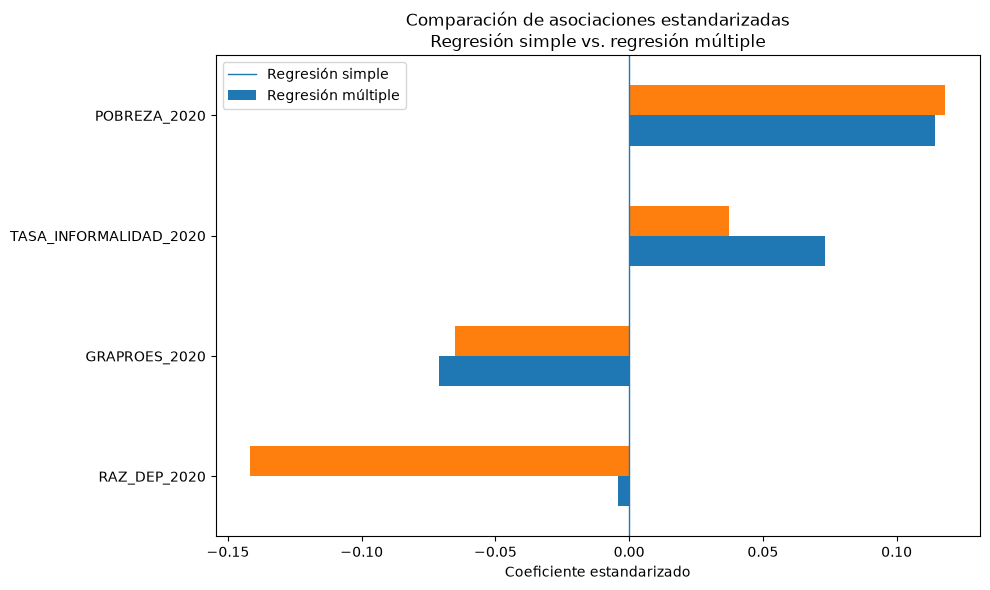

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\comparacion_betas_estandarizados_simple_multiple.png


In [93]:
# ============================================================
# 13.4 Comparación gráfica de betas estandarizados
# ============================================================

tabla_plot = (
    tabla_beta_std_comparacion
    .set_index("Variable")
)

ax = tabla_plot[
    [
        "Beta estandarizado simple",
        "Beta estandarizado múltiple"
    ]
].plot(
    kind="barh",
    figsize=(10, 6)
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "Coeficiente estandarizado"
)

ax.set_ylabel("")

ax.set_title(
    "Comparación de asociaciones estandarizadas\n"
    "Regresión simple vs. regresión múltiple"
)

ax.legend(
    [
        "Regresión simple",
        "Regresión múltiple"
    ]
)

plt.tight_layout()

ruta_beta_comparacion = (
    OUTPUT_DIR /
    "comparacion_betas_estandarizados_simple_multiple.png"
)

plt.savefig(
    ruta_beta_comparacion,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: "
    f"{ruta_beta_comparacion}"
)

In [94]:
# ============================================================
# 13.5 Comparación de capacidad explicativa
# ============================================================

comparacion_ajuste = []

for variable in X:

    modelo_simple = modelos_simples[variable]

    comparacion_ajuste.append({
        "Modelo": f"Simple — {variable}",
        "Número de predictores": 1,
        "R²": modelo_simple.rsquared,
        "R² ajustado":
            modelo_simple.rsquared_adj
    })

comparacion_ajuste.append({
    "Modelo": "Múltiple — 4 predictores",
    "Número de predictores": 4,
    "R²": modelo_mco.rsquared,
    "R² ajustado":
        modelo_mco.rsquared_adj
})

tabla_ajuste_comparado = pd.DataFrame(
    comparacion_ajuste
)

display(
    tabla_ajuste_comparado.round(4)
)

,Modelo,Número de predictores,R²,R² ajustado
0,Simple — RAZ_DEP_2020,1,0.0000,-0.0004
1,Simple — GRAPROES_2020,1,0.0050,0.0046
2,Simple — TASA_INFORMALIDAD_2020,1,0.0054,0.0050
3,Simple — POBREZA_2020,1,0.0130,0.0126
4,Múltiple — 4 predictores,4,0.0215,0.0199


In [95]:
# ============================================================
# 13.6 Ganancia respecto al mejor modelo simple
# ============================================================

filas_simples = (
    tabla_ajuste_comparado[
        tabla_ajuste_comparado[
            "Número de predictores"
        ] == 1
    ]
)

indice_mejor = (
    filas_simples["R²"]
    .idxmax()
)

mejor_simple = (
    tabla_ajuste_comparado
    .loc[indice_mejor]
)

r2_multiple = modelo_mco.rsquared
r2_adj_multiple = modelo_mco.rsquared_adj

ganancia_r2 = (
    r2_multiple
    - mejor_simple["R²"]
)

ganancia_r2_adj = (
    r2_adj_multiple
    - mejor_simple["R² ajustado"]
)

print("MEJOR MODELO SIMPLE")
print("=" * 55)

print(
    f"Modelo: {mejor_simple['Modelo']}"
)

print(
    f"R²: {mejor_simple['R²']:.4f}"
)

print(
    f"R² ajustado: "
    f"{mejor_simple['R² ajustado']:.4f}"
)

print("\nMODELO MÚLTIPLE")
print("=" * 55)

print(
    f"R²: {r2_multiple:.4f}"
)

print(
    f"R² ajustado: "
    f"{r2_adj_multiple:.4f}"
)

print("\nGANANCIA")
print("=" * 55)

print(
    f"Incremento R²: {ganancia_r2:.4f}"
)

print(
    "Incremento en puntos porcentuales "
    "de variabilidad explicada: "
    f"{ganancia_r2 * 100:.2f}"
)

print(
    f"Incremento R² ajustado: "
    f"{ganancia_r2_adj:.4f}"
)

MEJOR MODELO SIMPLE
Modelo: Simple — POBREZA_2020
R²: 0.0130
R² ajustado: 0.0126

MODELO MÚLTIPLE
R²: 0.0215
R² ajustado: 0.0199

GANANCIA
Incremento R²: 0.0084
Incremento en puntos porcentuales de variabilidad explicada: 0.84
Incremento R² ajustado: 0.0072


## 13.7. Aporte de la regresión múltiple

La principal aportación del modelo múltiple no consiste únicamente en aumentar el \(R^2\).

Su ventaja fundamental es permitir separar parcialmente la información compartida entre las características municipales y estimar la asociación de cada predictor condicionada a la presencia de los demás.

Los modelos simples mostraban únicamente relaciones bivariadas. Por ello, una variable podía aparecer significativa porque representaba tanto información propia como características relacionadas con otros predictores.

La regresión múltiple modifica esta perspectiva. Los resultados muestran que:

- la razón de dependencia adquiere una asociación negativa claramente identificable al controlar por las demás variables;
- escolaridad mantiene una asociación negativa de magnitud similar, aunque con evidencia inferencial cercana al umbral del 5%;
- informalidad reduce considerablemente su coeficiente y deja de presentar significancia en el modelo principal;
- pobreza conserva una asociación positiva muy estable.

Estos cambios muestran que las relaciones bivariadas y las asociaciones parciales no son equivalentes.

## 13.8. Cambio en la razón de dependencia

Uno de los resultados más notorios aparece en la razón de dependencia.

En la regresión simple, su asociación con el crecimiento comercial era prácticamente nula. Sin embargo, en el modelo múltiple el coeficiente se vuelve claramente negativo y estadísticamente significativo.

Este cambio no constituye una contradicción. La regresión simple mide una relación bivariada, mientras que el coeficiente múltiple representa la asociación de razón de dependencia después de controlar por escolaridad, informalidad y pobreza.

Dado que razón de dependencia presenta correlaciones relativamente elevadas con varios de estos predictores, su relación parcial puede diferir sustancialmente de la relación observada cuando se analiza de manera aislada.

El patrón es compatible con la presencia de información compartida y posibles efectos de control o supresión estadística. Sin embargo, el análisis no permite atribuir el cambio de manera exclusiva a un único mecanismo causal.

## 13.9. Cambio en informalidad

La informalidad presenta el patrón opuesto al observado para razón de dependencia.

Cuando se analiza individualmente, muestra una asociación positiva y estadísticamente significativa con el crecimiento comercial. Sin embargo, al incorporar simultáneamente las demás características municipales, su coeficiente se reduce y deja de ser estadísticamente significativo.

Este comportamiento indica que parte de la relación bivariada de informalidad con el crecimiento comercial se encuentra compartida con las demás variables incluidas en el modelo.

El resultado no implica que informalidad carezca de relación con la dinámica comercial. Indica que, una vez controladas razón de dependencia, escolaridad y pobreza, la muestra completa no proporciona evidencia estadística suficiente para identificar una asociación parcial independiente de informalidad.

## 13.10. Estabilidad de pobreza

Pobreza presenta el comportamiento más estable entre las variables analizadas.

Su coeficiente pasa de aproximadamente 0.131 en la regresión simple a 0.136 en el modelo múltiple, manteniendo en ambos casos una dirección positiva y significancia estadística.

Esto indica que la asociación entre pobreza y crecimiento de la densidad comercial no desaparece después de considerar simultáneamente razón de dependencia, escolaridad e informalidad.

Aun así, el coeficiente debe interpretarse como una asociación parcial y no como un efecto causal.

## 13.11. Comparación de la capacidad explicativa

La regresión múltiple presenta una capacidad explicativa superior a la de cualquiera de los modelos simples. Sin embargo, la mejora es limitada en términos absolutos.

El mejor modelo simple explica alrededor de 1.3% de la variabilidad del crecimiento comercial, mientras que la especificación múltiple alcanza aproximadamente 2.15%.

Por tanto, considerar simultáneamente las cuatro características municipales aporta información adicional, pero no modifica la conclusión general de que la mayor parte de la heterogeneidad del crecimiento comercial se encuentra fuera de la explicación proporcionada por estas variables.

El \(R^2\) ajustado conduce a una conclusión similar, lo cual indica que la mejora no responde únicamente al aumento mecánico producido por agregar predictores.

In [96]:
# ============================================================
# 13.12 Tabla ejecutiva:
#       regresión simple vs. múltiple
# ============================================================

tabla_ejecutiva_13 = tabla_simple_multiple[
    [
        "Variable",
        "Beta simple",
        "Beta múltiple",
        "p simple HC3",
        "p múltiple HC3",
        "Significativa simple",
        "Significativa múltiple"
    ]
].copy()

display(
    tabla_ejecutiva_13.round(4)
)

,Variable,Beta simple,Beta múltiple,p simple HC3,p múltiple HC3,Significativa simple,Significativa múltiple
0,RAZ_DEP_2020,-0.0100,-0.3247,0.8350,0.0002,No,Sí
1,GRAPROES_2020,-1.1986,-1.1026,0.0001,0.0465,Sí,Sí
2,TASA_INFORMALIDAD_2020,0.1236,0.0626,0.0003,0.3266,Sí,No
3,POBREZA_2020,0.1312,0.1357,0.0000,0.0003,Sí,Sí


Cierre de la Fase 13

La comparación entre las regresiones simples y el modelo múltiple muestra que las conclusiones pueden cambiar de manera importante cuando las características municipales se consideran simultáneamente.

Los signos de los cuatro coeficientes permanecen estables. Sin embargo, la magnitud y la significancia de algunas relaciones cambian de forma considerable. La razón de dependencia pasa de una asociación prácticamente nula y no significativa en el modelo simple a una asociación parcial negativa y estadísticamente significativa en el modelo múltiple. En contraste, informalidad reduce aproximadamente a la mitad la magnitud de su coeficiente y deja de ser significativa cuando se controlan las demás variables.

Escolaridad conserva una asociación negativa de magnitud relativamente estable y presenta significancia al 5% bajo la inferencia HC3, aunque próxima al umbral convencional. Pobreza presenta el comportamiento más estable: mantiene una asociación positiva de magnitud similar y continúa siendo estadísticamente significativa después de incorporar los demás predictores.

La capacidad explicativa también mejora al pasar al modelo múltiple. El \(R^2\) aumenta de aproximadamente 0.0130 en el mejor modelo simple a 0.0215, lo que representa cerca de 0.84 puntos porcentuales adicionales de variabilidad explicada. El \(R^2\) ajustado también aumenta, aunque la capacidad explicativa absoluta del modelo continúa siendo reducida.

En consecuencia, el principal aporte de la regresión múltiple no consiste únicamente en mejorar el ajuste, sino en permitir estimar asociaciones parciales y distinguir qué relaciones permanecen después de considerar simultáneamente las características demográficas y socioeconómicas incluidas en el modelo.

# FASE 14 — Evaluación predictiva 80/20

El objetivo de esta fase es evaluar el comportamiento del modelo múltiple sobre observaciones que no fueron utilizadas durante su estimación.

La muestra se divide aleatoriamente en dos grupos:

- 80% para entrenamiento;
- 20% para prueba.

El modelo se reestima utilizando exclusivamente la muestra de entrenamiento. Posteriormente, los coeficientes obtenidos se emplean para generar predicciones sobre los municipios reservados para prueba.

Este procedimiento permite distinguir entre el ajuste dentro de la muestra y la capacidad del modelo para generalizar hacia observaciones no utilizadas en su estimación.

Debido a que los datos corresponden a un corte transversal municipal, el término predicción se utiliza en el sentido de evaluación fuera de muestra y no como pronóstico temporal de años futuros.

In [97]:
# ============================================================
# FASE 14 — EVALUACIÓN PREDICTIVA 80/20
# 14.1 Herramientas para partición y métricas
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("Herramientas predictivas cargadas correctamente.")

Herramientas predictivas cargadas correctamente.


In [98]:
# ============================================================
# 14.2 División 80/20 de la muestra
# ============================================================

df_train, df_test = train_test_split(
    df_estimacion,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

# Copias independientes
df_train = df_train.copy()
df_test = df_test.copy()

print("DIVISIÓN ENTRENAMIENTO / PRUEBA")
print("=" * 55)

print(f"Muestra total: {len(df_estimacion):,}")
print(f"Entrenamiento: {len(df_train):,}")
print(f"Prueba: {len(df_test):,}")

print(
    f"\nPorcentaje entrenamiento: "
    f"{100 * len(df_train) / len(df_estimacion):.2f}%"
)

print(
    f"Porcentaje prueba: "
    f"{100 * len(df_test) / len(df_estimacion):.2f}%"
)

DIVISIÓN ENTRENAMIENTO / PRUEBA
Muestra total: 2,440
Entrenamiento: 1,952
Prueba: 488

Porcentaje entrenamiento: 80.00%
Porcentaje prueba: 20.00%


In [99]:
# ============================================================
# 14.3 Verificación de independencia entre train y test
# ============================================================

cvegeo_train = set(df_train["CVEGEO"])
cvegeo_test = set(df_test["CVEGEO"])

traslape = cvegeo_train.intersection(
    cvegeo_test
)

print(
    f"Municipios repetidos entre train y test: "
    f"{len(traslape)}"
)

print(
    f"Total reconstruido: "
    f"{len(df_train) + len(df_test):,}"
)

if (
    len(traslape) == 0
    and len(df_train) + len(df_test) == len(df_estimacion)
):
    print(
        "\n✓ La partición es válida: "
        "no existe traslape entre entrenamiento y prueba."
    )

Municipios repetidos entre train y test: 0
Total reconstruido: 2,440

✓ La partición es válida: no existe traslape entre entrenamiento y prueba.


In [100]:
# ============================================================
# 14.4 Comparación descriptiva de Y:
#      entrenamiento vs. prueba
# ============================================================

def resumen_y(serie):

    return pd.Series({
        "N": serie.count(),
        "Media": serie.mean(),
        "Desv. estándar": serie.std(),
        "Mínimo": serie.min(),
        "P05": serie.quantile(0.05),
        "Q1": serie.quantile(0.25),
        "Mediana": serie.median(),
        "Q3": serie.quantile(0.75),
        "P95": serie.quantile(0.95),
        "Máximo": serie.max()
    })


tabla_comparacion_split = pd.DataFrame({
    "Entrenamiento":
        resumen_y(df_train[Y]),

    "Prueba":
        resumen_y(df_test[Y])
})

display(
    tabla_comparacion_split.round(4)
)

,Entrenamiento,Prueba
N,"1,952.0000",488.0000
Media,15.4351,16.1301
Desv. estándar,24.4408,27.6033
Mínimo,-62.9541,-61.0000
P05,-14.7013,-15.0238
Q1,3.7389,3.8203
Mediana,13.2764,13.9898
Q3,24.2004,24.1651
P95,46.8045,49.8517
Máximo,465.2009,420.0000


In [101]:
# ============================================================
# 14.5 Reestimación del modelo con muestra de entrenamiento
# ============================================================

modelo_train = smf.ols(
    formula=formula_modelo,
    data=df_train
).fit()

print("MODELO ENTRENADO")
print("=" * 55)

print(
    f"Observaciones utilizadas: "
    f"{int(modelo_train.nobs):,}"
)

print(
    f"R² entrenamiento: "
    f"{modelo_train.rsquared:.4f}"
)

print(
    f"R² ajustado entrenamiento: "
    f"{modelo_train.rsquared_adj:.4f}"
)

MODELO ENTRENADO
Observaciones utilizadas: 1,952
R² entrenamiento: 0.0183
R² ajustado entrenamiento: 0.0163


In [102]:
# ============================================================
# 14.6 Coeficientes estimados en entrenamiento
# ============================================================

tabla_coef_train = pd.DataFrame({
    "Coeficiente entrenamiento":
        modelo_train.params
})

tabla_coef_train.index.name = "Parámetro"

display(
    tabla_coef_train.round(4)
)

,Coeficiente entrenamiento
Parámetro,
Intercept,33.5854
RAZ_DEP_2020,-0.3165
GRAPROES_2020,-1.1691
TASA_INFORMALIDAD_2020,0.0424
POBREZA_2020,0.1202


In [103]:
# ============================================================
# 14.7 Predicciones fuera de muestra
# ============================================================

pred_test = modelo_train.predict(
    df_test
)

df_test["Y_PREDICHO_MULTIPLE"] = (
    pred_test.to_numpy()
)

df_test["RESIDUO_PREDICTIVO"] = (
    df_test[Y]
    - df_test["Y_PREDICHO_MULTIPLE"]
)

print("Predicciones generadas correctamente.")

print(
    f"N predicciones: "
    f"{df_test['Y_PREDICHO_MULTIPLE'].notna().sum():,}"
)

print(
    f"Predicciones faltantes: "
    f"{df_test['Y_PREDICHO_MULTIPLE'].isna().sum():,}"
)

Predicciones generadas correctamente.
N predicciones: 488
Predicciones faltantes: 0


In [104]:
# ============================================================
# 14.8 Ejemplo de predicciones
# ============================================================

columnas_pred = [
    "CVEGEO",
    "entidad",
    "municipio",
    Y,
    "Y_PREDICHO_MULTIPLE",
    "RESIDUO_PREDICTIVO"
]

display(
    df_test[
        columnas_pred
    ]
    .head(10)
    .round(4)
)

,CVEGEO,entidad,municipio,CREC_DENSIDAD_RETAIL_2020_2025,Y_PREDICHO_MULTIPLE,RESIDUO_PREDICTIVO
1583,21027,PUEBLA,Caltepec,4.3908,15.6515,-11.2607
1173,20187,OAXACA,San Juan Coatzóspam,-20.1816,21.3126,-41.4941
2144,30081,VERACRUZ DE IGNACIO DE LA LLAVE,Ixhuatlancillo,15.2167,19.3855,-4.1688
1477,20491,OAXACA,Santiago Textitlán,60.2851,16.0221,44.2630
1151,20165,OAXACA,San José Ayuquila,-10.8907,15.6509,-26.5416
1580,21024,PUEBLA,Axutla,-1.7372,11.7957,-13.5330
495,13059,HIDALGO,Tecozautla,48.6757,15.6177,33.0580
554,14034,JALISCO,Ejutla,0.5010,7.6999,-7.1988
2203,30140,VERACRUZ DE IGNACIO DE LA LLAVE,San Andrés Tenejapan,-14.2792,23.4528,-37.7320
1104,20118,OAXACA,San Bartolomé Quialana,37.6969,20.8961,16.8008


In [105]:
# ============================================================
# 14.9 Métricas predictivas fuera de muestra
# ============================================================

y_test = df_test[Y].to_numpy()
y_pred = df_test["Y_PREDICHO_MULTIPLE"].to_numpy()

# ------------------------------------------------------------
# Métricas principales
# ------------------------------------------------------------

mse_test = mean_squared_error(
    y_test,
    y_pred
)

rmse_test = np.sqrt(
    mse_test
)

mae_test = mean_absolute_error(
    y_test,
    y_pred
)

r2_test = r2_score(
    y_test,
    y_pred
)

# ------------------------------------------------------------
# Métricas porcentuales
# ------------------------------------------------------------

mask_no_cero = y_test != 0

mpe_test = (
    np.mean(
        (
            y_test[mask_no_cero]
            - y_pred[mask_no_cero]
        )
        / y_test[mask_no_cero]
    )
    * 100
)

mape_test = (
    np.mean(
        np.abs(
            (
                y_test[mask_no_cero]
                - y_pred[mask_no_cero]
            )
            / y_test[mask_no_cero]
        )
    )
    * 100
)

wape_test = (
    np.sum(
        np.abs(
            y_test - y_pred
        )
    )
    / np.sum(
        np.abs(y_test)
    )
    * 100
)

# ------------------------------------------------------------
# Tabla
# ------------------------------------------------------------

tabla_metricas_test = pd.DataFrame({
    "Métrica": [
        "MSE",
        "RMSE",
        "MAE",
        "R² test",
        "MPE (%)",
        "MAPE (%)",
        "WAPE (%)"
    ],

    "Resultado": [
        mse_test,
        rmse_test,
        mae_test,
        r2_test,
        mpe_test,
        mape_test,
        wape_test
    ]
})

display(
    tabla_metricas_test.round(4)
)

,Métrica,Resultado
0,MSE,738.0624
1,RMSE,27.1673
2,MAE,14.7159
3,R² test,0.0293
4,MPE (%),-269.3434
5,MAPE (%),637.3772
6,WAPE (%),74.1335


In [106]:
# ============================================================
# 14.10 Diagnóstico de valores cercanos a cero
# ============================================================

n_cero = np.sum(
    y_test == 0
)

n_menor_1 = np.sum(
    np.abs(y_test) < 1
)

n_menor_5 = np.sum(
    np.abs(y_test) < 5
)

print("DIAGNÓSTICO DE Y EN MUESTRA DE PRUEBA")
print("=" * 55)

print(
    f"Y exactamente igual a 0: "
    f"{n_cero}"
)

print(
    f"|Y| < 1: "
    f"{n_menor_1}"
)

print(
    f"|Y| < 5: "
    f"{n_menor_5}"
)

DIAGNÓSTICO DE Y EN MUESTRA DE PRUEBA
Y exactamente igual a 0: 0
|Y| < 1: 18
|Y| < 5: 85


## 14.10. Precaución con las métricas porcentuales

MPE y MAPE se calculan dividiendo el error entre el valor realmente observado. Por esta razón, cuando la variable dependiente toma valores cercanos a cero, estas métricas pueden alcanzar magnitudes muy elevadas aun cuando el error absoluto no sea excepcionalmente grande.

Además, el crecimiento de la densidad comercial puede tomar valores negativos, lo que dificulta todavía más la interpretación directa de MPE.

Por esta razón, MPE y MAPE se reportan para cumplir y complementar la evaluación predictiva, pero no se utilizan como criterios principales para valorar el desempeño del modelo.

La interpretación se concentrará principalmente en RMSE, MAE, \(R^2\) fuera de muestra y WAPE.

In [107]:
# ============================================================
# 14.11 Sesgo promedio de predicción
# ============================================================

media_residuo_pred = (
    df_test["RESIDUO_PREDICTIVO"]
    .mean()
)

mediana_residuo_pred = (
    df_test["RESIDUO_PREDICTIVO"]
    .median()
)

print(
    f"Media del residuo predictivo: "
    f"{media_residuo_pred:.4f}"
)

print(
    f"Mediana del residuo predictivo: "
    f"{mediana_residuo_pred:.4f}"
)

Media del residuo predictivo: 0.5048
Mediana del residuo predictivo: -2.1575


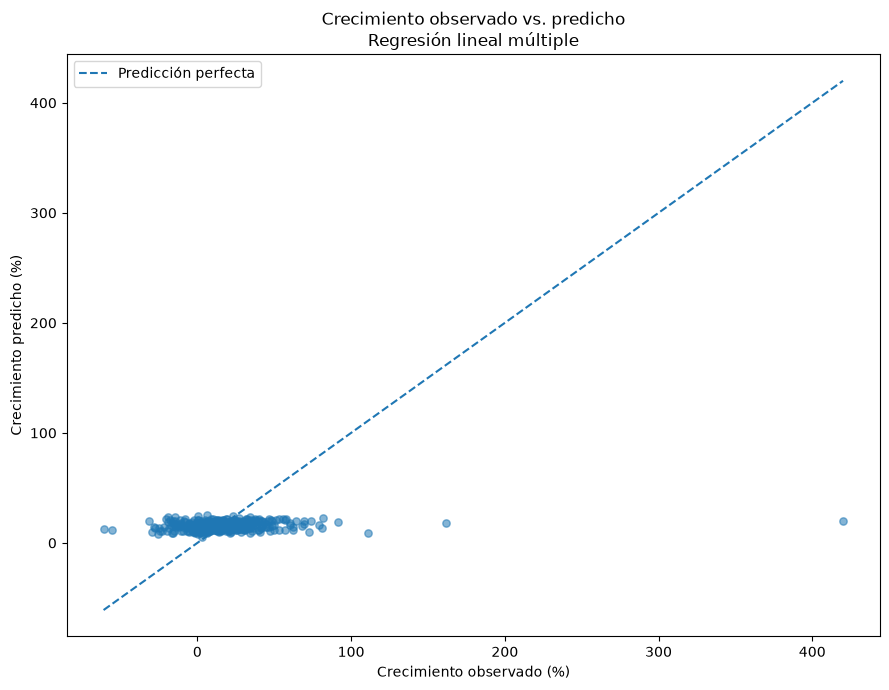

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\observado_vs_predicho_regresion_multiple.png


In [108]:
# ============================================================
# 14.12 Observado vs. predicho
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.scatter(
    y_test,
    y_pred,
    alpha=0.55,
    s=28
)

lim_min = min(
    y_test.min(),
    y_pred.min()
)

lim_max = max(
    y_test.max(),
    y_pred.max()
)

ax.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--",
    linewidth=1.5,
    label="Predicción perfecta"
)

ax.set_xlabel(
    "Crecimiento observado (%)"
)

ax.set_ylabel(
    "Crecimiento predicho (%)"
)

ax.set_title(
    "Crecimiento observado vs. predicho\n"
    "Regresión lineal múltiple"
)

ax.legend()

plt.tight_layout()

ruta_obs_pred = (
    OUTPUT_DIR /
    "observado_vs_predicho_regresion_multiple.png"
)

plt.savefig(
    ruta_obs_pred,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: "
    f"{ruta_obs_pred}"
)

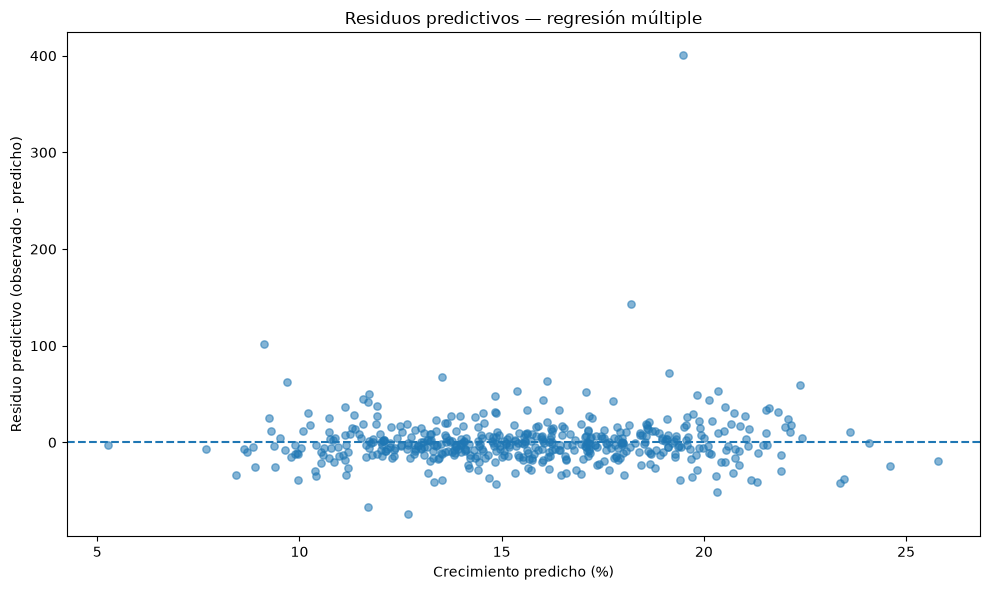

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\residuos_predictivos_regresion_multiple.png


In [109]:
# ============================================================
# 14.13 Residuos predictivos
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    df_test["Y_PREDICHO_MULTIPLE"],
    df_test["RESIDUO_PREDICTIVO"],
    alpha=0.55,
    s=28
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel(
    "Crecimiento predicho (%)"
)

ax.set_ylabel(
    "Residuo predictivo (observado - predicho)"
)

ax.set_title(
    "Residuos predictivos — regresión múltiple"
)

plt.tight_layout()

ruta_resid_pred = (
    OUTPUT_DIR /
    "residuos_predictivos_regresion_multiple.png"
)

plt.savefig(
    ruta_resid_pred,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: "
    f"{ruta_resid_pred}"
)

In [110]:
# ============================================================
# 14.14 Municipios con mayores errores predictivos
# ============================================================

df_test["ERROR_ABS"] = (
    df_test["RESIDUO_PREDICTIVO"]
    .abs()
)

top_errores = (
    df_test[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            Y,
            "Y_PREDICHO_MULTIPLE",
            "RESIDUO_PREDICTIVO",
            "ERROR_ABS"
        ]
    ]
    .sort_values(
        "ERROR_ABS",
        ascending=False
    )
    .head(15)
)

display(
    top_errores.round(4)
)

,CVEGEO,entidad,municipio,CREC_DENSIDAD_RETAIL_2020_2025,Y_PREDICHO_MULTIPLE,RESIDUO_PREDICTIVO,ERROR_ABS
1997,28036,TAMAULIPAS,San Nicolás,420.0000,19.4877,400.5123,400.5123
1125,20139,OAXACA,San Francisco Chapulapa,161.8486,18.1979,143.6507,143.6507
433,12078,GUERRERO,Cochoapa el Grande,110.8380,9.1305,101.7075,101.7075
1273,20287,OAXACA,San Miguel Tulancingo,-61.0000,12.6889,-73.6889,73.6889
2379,31104,YUCATÁN,Yaxcabá,91.2152,19.1263,72.0888,72.0888
2033,29029,TLAXCALA,Tepeyanco,81.0925,13.5361,67.5564,67.5564
1918,26046,SONORA,Oquitoa,-55.2395,11.6997,-66.9392,66.9392
109,07035,CHIAPAS,Frontera Hidalgo,79.2735,16.1230,63.1506,63.1506
1437,20451,OAXACA,Santiago Apoala,72.5393,9.7037,62.8356,62.8356
1456,20470,OAXACA,Santiago Lachiguiri,81.6609,22.3821,59.2788,59.2788


In [111]:
# ============================================================
# 14.15 Relación RMSE / MAE
# ============================================================

razon_rmse_mae = (
    rmse_test / mae_test
)

print(
    f"RMSE: {rmse_test:.4f}"
)

print(
    f"MAE: {mae_test:.4f}"
)

print(
    f"Razón RMSE / MAE: "
    f"{razon_rmse_mae:.4f}"
)

RMSE: 27.1673
MAE: 14.7159
Razón RMSE / MAE: 1.8461


In [112]:
# ============================================================
# 14.16 Resumen de evaluación predictiva
# ============================================================

resumen_predictivo = pd.DataFrame({
    "Indicador": [
        "N entrenamiento",
        "N prueba",
        "MSE",
        "RMSE",
        "MAE",
        "R² test",
        "MPE (%)",
        "MAPE (%)",
        "WAPE (%)",
        "Media residuo predictivo"
    ],

    "Resultado": [
        len(df_train),
        len(df_test),
        mse_test,
        rmse_test,
        mae_test,
        r2_test,
        mpe_test,
        mape_test,
        wape_test,
        media_residuo_pred
    ]
})

display(
    resumen_predictivo.round(4)
)

,Indicador,Resultado
0,N entrenamiento,"1,952.0000"
1,N prueba,488.0000
2,MSE,738.0624
3,RMSE,27.1673
4,MAE,14.7159
5,R² test,0.0293
6,MPE (%),-269.3434
7,MAPE (%),637.3772
8,WAPE (%),74.1335
9,Media residuo predictivo,0.5048


## 14.17. Alcance de la evaluación predictiva

Las métricas obtenidas en esta fase describen exclusivamente el desempeño fuera de muestra de la regresión múltiple.

El modelo se estimó únicamente con la muestra de entrenamiento y sus predicciones se evaluaron sobre municipios que no participaron en la estimación.

La comparación con un modelo de referencia y con el mejor modelo de regresión simple se realizará posteriormente utilizando exactamente la misma muestra de prueba. Esto permitirá determinar si el incremento de complejidad del modelo múltiple produce una mejora predictiva real.

##Cierre de la Fase 14

La evaluación predictiva se realizó utilizando 1,952 municipios para entrenamiento y 488 para prueba. Ambas muestras presentan características descriptivas razonablemente similares, aunque el conjunto de prueba registra una dispersión ligeramente mayor en el crecimiento de la densidad comercial.

El modelo estimado únicamente con la muestra de entrenamiento conserva los signos obtenidos con la muestra completa: razón de dependencia y escolaridad presentan coeficientes negativos, mientras que informalidad y pobreza mantienen coeficientes positivos. Esto aporta evidencia de estabilidad en la dirección de las asociaciones.

Sobre la muestra de prueba se obtuvo un RMSE de 27.1673, un MAE de 14.7159 y un \(R^2\) fuera de muestra de 0.0293. Por tanto, el modelo conserva una capacidad predictiva positiva fuera de muestra, pero explica solamente una proporción reducida de la variabilidad observada.

La diferencia entre RMSE y MAE, con una razón aproximada de 1.85, muestra que algunos errores de gran magnitud afectan considerablemente el desempeño global. Esto se observa especialmente en municipios con crecimientos extraordinarios, para los cuales el modelo genera predicciones mucho más cercanas al comportamiento central de la muestra.

La media del residuo predictivo es de 0.5048 puntos porcentuales, relativamente cercana a cero, por lo que el principal problema no corresponde a un fuerte sesgo promedio de predicción. La limitación principal se encuentra en la elevada dispersión de los errores y en la dificultad para representar observaciones extremas.

Las métricas porcentuales MPE y MAPE alcanzan valores muy elevados debido a la existencia de observaciones con crecimiento real cercano a cero. Por esta razón, su interpretación directa resulta inadecuada en este contexto. La evaluación se concentra principalmente en RMSE, MAE, \(R^2\) fuera de muestra y WAPE.

En conjunto, la regresión múltiple muestra capacidad para identificar patrones promedio, pero su precisión para anticipar el comportamiento de municipios individuales continúa siendo limitada. La siguiente fase incorporará intervalos de predicción para cuantificar explícitamente la incertidumbre asociada con estas estimaciones.

# FASE 15 — Intervalos de predicción

Las predicciones puntuales obtenidas en la fase anterior proporcionan un único valor estimado para cada municipio. Sin embargo, toda predicción contiene incertidumbre.

Por esta razón, en esta fase se calculan intervalos de predicción al 95% para los municipios de la muestra de prueba.

Un intervalo de predicción incorpora tanto la incertidumbre asociada con la estimación de la media esperada como la variabilidad individual de las observaciones. En consecuencia, suele ser más amplio que un intervalo de confianza para la media estimada.

El análisis permitirá evaluar:

- la amplitud de los intervalos;
- el porcentaje de valores reales contenidos dentro de ellos;
- los municipios cuyos valores observados quedan fuera del intervalo;
- el grado de incertidumbre asociado con las predicciones del modelo múltiple.

In [114]:
modelo_train

In [115]:
# ============================================================
# FASE 15 — INTERVALOS DE PREDICCIÓN
# 15.1 Obtención de intervalos al 95%
# ============================================================

prediccion_completa = modelo_train.get_prediction(
    df_test
)

tabla_intervalos = prediccion_completa.summary_frame(
    alpha=0.05
)

display(
    tabla_intervalos.head().round(4)
)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,15.6515,1.0900,13.5138,17.7892,-31.9370,63.2400
1,21.3126,1.3998,18.5673,24.0578,-26.3071,68.9322
2,19.3855,1.1167,17.1954,21.5756,-28.2054,66.9764
3,16.0221,1.6827,12.7220,19.3222,-31.6328,63.6770
4,15.6509,0.9711,13.7465,17.5554,-31.9277,63.2296


In [116]:
# ============================================================
# 15.2 Incorporación de intervalos a la muestra de prueba
# ============================================================

df_test["PRED_MEDIA"] = (
    tabla_intervalos["mean"].to_numpy()
)

df_test["IC_MEDIA_INF"] = (
    tabla_intervalos["mean_ci_lower"].to_numpy()
)

df_test["IC_MEDIA_SUP"] = (
    tabla_intervalos["mean_ci_upper"].to_numpy()
)

df_test["IP95_INF"] = (
    tabla_intervalos["obs_ci_lower"].to_numpy()
)

df_test["IP95_SUP"] = (
    tabla_intervalos["obs_ci_upper"].to_numpy()
)

print("Intervalos incorporados correctamente.")

Intervalos incorporados correctamente.


In [117]:
# ============================================================
# 15.3 Verificación de consistencia
# ============================================================

diferencia_pred = np.max(
    np.abs(
        df_test["PRED_MEDIA"]
        - df_test["Y_PREDICHO_MULTIPLE"]
    )
)

print(
    "Máxima diferencia entre las dos "
    f"predicciones puntuales: {diferencia_pred:.12f}"
)

if diferencia_pred < 1e-8:
    print(
        "\n✓ Las predicciones son consistentes."
    )

Máxima diferencia entre las dos predicciones puntuales: 0.000000000000

✓ Las predicciones son consistentes.


In [118]:
# ============================================================
# 15.4 Ejemplos de intervalos de predicción
# ============================================================

columnas_intervalos = [
    "CVEGEO",
    "entidad",
    "municipio",
    Y,
    "Y_PREDICHO_MULTIPLE",
    "IC_MEDIA_INF",
    "IC_MEDIA_SUP",
    "IP95_INF",
    "IP95_SUP"
]

display(
    df_test[
        columnas_intervalos
    ]
    .head(10)
    .round(4)
)

,CVEGEO,entidad,municipio,CREC_DENSIDAD_RETAIL_2020_2025,Y_PREDICHO_MULTIPLE,IC_MEDIA_INF,IC_MEDIA_SUP,IP95_INF,IP95_SUP
1583,21027,PUEBLA,Caltepec,4.3908,15.6515,13.5138,17.7892,-31.9370,63.2400
1173,20187,OAXACA,San Juan Coatzóspam,-20.1816,21.3126,18.5673,24.0578,-26.3071,68.9322
2144,30081,VERACRUZ DE IGNACIO DE LA LLAVE,Ixhuatlancillo,15.2167,19.3855,17.1954,21.5756,-28.2054,66.9764
1477,20491,OAXACA,Santiago Textitlán,60.2851,16.0221,12.7220,19.3222,-31.6328,63.6770
1151,20165,OAXACA,San José Ayuquila,-10.8907,15.6509,13.7465,17.5554,-31.9277,63.2296
1580,21024,PUEBLA,Axutla,-1.7372,11.7957,8.6958,14.8956,-35.8457,59.4372
495,13059,HIDALGO,Tecozautla,48.6757,15.6177,12.9833,18.2520,-31.9958,63.2311
554,14034,JALISCO,Ejutla,0.5010,7.6999,3.6801,11.7196,-40.0103,55.4100
2203,30140,VERACRUZ DE IGNACIO DE LA LLAVE,San Andrés Tenejapan,-14.2792,23.4528,20.4153,26.4904,-24.1846,71.0903
1104,20118,OAXACA,San Bartolomé Quialana,37.6969,20.8961,17.3760,24.4161,-26.7746,68.5667


## 15.5. Intervalo de confianza e intervalo de predicción

El intervalo de confianza de la media responde a una pregunta del tipo:

> ¿En qué rango se encuentra el crecimiento promedio esperado para municipios con determinadas características?

El intervalo de predicción responde a una pregunta diferente:

> ¿En qué rango podría ubicarse el crecimiento observado de un municipio individual con esas características?

El segundo intervalo incorpora una fuente adicional de variabilidad y, por ello, es necesariamente más amplio.

En este proyecto se dará mayor relevancia al intervalo de predicción, ya que el objetivo de esta fase es evaluar la incertidumbre asociada con predicciones municipales individuales.

In [119]:
# ============================================================
# 15.6 Cobertura de los intervalos de predicción
# ============================================================

df_test["DENTRO_IP95"] = (
    (df_test[Y] >= df_test["IP95_INF"])
    &
    (df_test[Y] <= df_test["IP95_SUP"])
)

n_dentro = df_test["DENTRO_IP95"].sum()
n_fuera = len(df_test) - n_dentro

cobertura_ip95 = (
    100 * n_dentro / len(df_test)
)

print("COBERTURA DEL INTERVALO DE PREDICCIÓN")
print("=" * 55)

print(
    f"Municipios dentro del IP95: {n_dentro:,}"
)

print(
    f"Municipios fuera del IP95: {n_fuera:,}"
)

print(
    f"Cobertura empírica: {cobertura_ip95:.2f}%"
)

COBERTURA DEL INTERVALO DE PREDICCIÓN
Municipios dentro del IP95: 471
Municipios fuera del IP95: 17
Cobertura empírica: 96.52%


In [120]:
# ============================================================
# 15.7 Amplitud de los intervalos de predicción
# ============================================================

df_test["ANCHO_IP95"] = (
    df_test["IP95_SUP"]
    - df_test["IP95_INF"]
)

resumen_ancho_ip = pd.Series({
    "Media": df_test["ANCHO_IP95"].mean(),
    "Mediana": df_test["ANCHO_IP95"].median(),
    "Mínimo": df_test["ANCHO_IP95"].min(),
    "P05": df_test["ANCHO_IP95"].quantile(0.05),
    "Q1": df_test["ANCHO_IP95"].quantile(0.25),
    "Q3": df_test["ANCHO_IP95"].quantile(0.75),
    "P95": df_test["ANCHO_IP95"].quantile(0.95),
    "Máximo": df_test["ANCHO_IP95"].max()
})

display(
    resumen_ancho_ip
    .to_frame("Ancho IP95")
    .round(4)
)

,Ancho IP95
Media,95.2049
Mediana,95.1799
Mínimo,95.1071
P05,95.1233
Q1,95.1510
Q3,95.2222
P95,95.3485
Máximo,95.8448


In [121]:
# ============================================================
# 15.8 Comparación de amplitudes:
#      intervalo de confianza vs. intervalo de predicción
# ============================================================

df_test["ANCHO_IC_MEDIA"] = (
    df_test["IC_MEDIA_SUP"]
    - df_test["IC_MEDIA_INF"]
)

comparacion_amplitud = pd.DataFrame({
    "Tipo de intervalo": [
        "IC 95% de la media",
        "IP 95% individual"
    ],

    "Ancho medio": [
        df_test["ANCHO_IC_MEDIA"].mean(),
        df_test["ANCHO_IP95"].mean()
    ],

    "Ancho mediano": [
        df_test["ANCHO_IC_MEDIA"].median(),
        df_test["ANCHO_IP95"].median()
    ]
})

display(
    comparacion_amplitud.round(4)
)

,Tipo de intervalo,Ancho medio,Ancho mediano
0,IC 95% de la media,4.6323,4.3382
1,IP 95% individual,95.2049,95.1799


In [122]:
# ============================================================
# 15.9 Municipios fuera del IP95
# ============================================================

municipios_fuera_ip = (
    df_test.loc[
        ~df_test["DENTRO_IP95"],
        [
            "CVEGEO",
            "entidad",
            "municipio",
            Y,
            "Y_PREDICHO_MULTIPLE",
            "IP95_INF",
            "IP95_SUP",
            "RESIDUO_PREDICTIVO"
        ]
    ]
    .copy()
)

municipios_fuera_ip["ERROR_ABS"] = (
    municipios_fuera_ip[
        "RESIDUO_PREDICTIVO"
    ].abs()
)

municipios_fuera_ip = (
    municipios_fuera_ip
    .sort_values(
        "ERROR_ABS",
        ascending=False
    )
)

print(
    f"Municipios fuera del IP95: "
    f"{len(municipios_fuera_ip)}"
)

display(
    municipios_fuera_ip
    .head(20)
    .round(4)
)

Municipios fuera del IP95: 17


,CVEGEO,entidad,municipio,CREC_DENSIDAD_RETAIL_2020_2025,Y_PREDICHO_MULTIPLE,IP95_INF,IP95_SUP,RESIDUO_PREDICTIVO,ERROR_ABS
1997,28036,TAMAULIPAS,San Nicolás,420.0000,19.4877,-28.0894,67.0649,400.5123,400.5123
1125,20139,OAXACA,San Francisco Chapulapa,161.8486,18.1979,-29.3926,65.7883,143.6507,143.6507
433,12078,GUERRERO,Cochoapa el Grande,110.8380,9.1305,-38.7919,57.0529,101.7075,101.7075
1273,20287,OAXACA,San Miguel Tulancingo,-61.0000,12.6889,-34.9280,60.3058,-73.6889,73.6889
2379,31104,YUCATÁN,Yaxcabá,91.2152,19.1263,-28.4543,66.7070,72.0888,72.0888
2033,29029,TLAXCALA,Tepeyanco,81.0925,13.5361,-34.0585,61.1306,67.5564,67.5564
1918,26046,SONORA,Oquitoa,-55.2395,11.6997,-36.0608,59.4602,-66.9392,66.9392
109,07035,CHIAPAS,Frontera Hidalgo,79.2735,16.1230,-31.4327,63.6786,63.1506,63.1506
1437,20451,OAXACA,Santiago Apoala,72.5393,9.7037,-38.0845,57.4919,62.8356,62.8356
1456,20470,OAXACA,Santiago Lachiguiri,81.6609,22.3821,-25.2693,70.0334,59.2788,59.2788


In [123]:
# ============================================================
# 15.10 Dirección de los casos fuera del intervalo
# ============================================================

n_superior = (
    df_test[Y]
    > df_test["IP95_SUP"]
).sum()

n_inferior = (
    df_test[Y]
    < df_test["IP95_INF"]
).sum()

tabla_fuera_direccion = pd.DataFrame({
    "Situación": [
        "Por encima del límite superior",
        "Por debajo del límite inferior"
    ],
    "N municipios": [
        n_superior,
        n_inferior
    ]
})

display(
    tabla_fuera_direccion
)

,Situación,N municipios
0,Por encima del límite superior,14
1,Por debajo del límite inferior,3


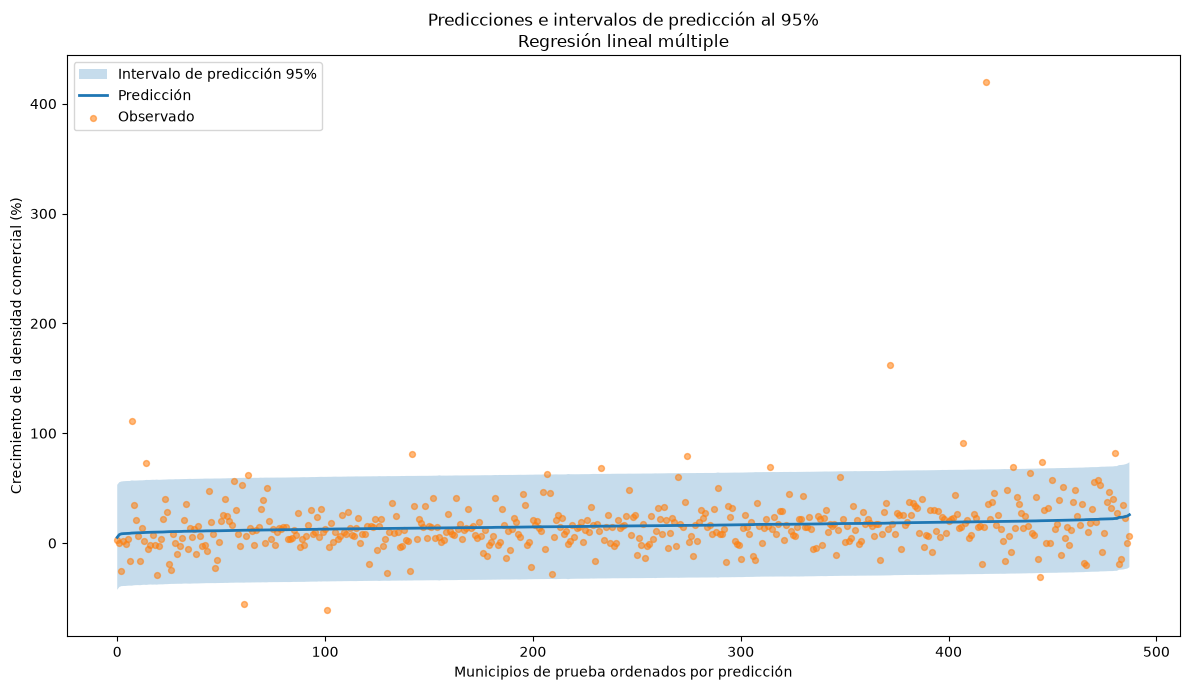

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\intervalos_prediccion_regresion_multiple.png


In [124]:
# ============================================================
# 15.11 Gráfica de intervalos de predicción
# ============================================================

graf_ip = (
    df_test[
        [
            Y,
            "Y_PREDICHO_MULTIPLE",
            "IP95_INF",
            "IP95_SUP"
        ]
    ]
    .sort_values(
        "Y_PREDICHO_MULTIPLE"
    )
    .reset_index(drop=True)
)

x_plot = np.arange(
    len(graf_ip)
)

fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.fill_between(
    x_plot,
    graf_ip["IP95_INF"].to_numpy(),
    graf_ip["IP95_SUP"].to_numpy(),
    alpha=0.25,
    label="Intervalo de predicción 95%"
)

ax.plot(
    x_plot,
    graf_ip["Y_PREDICHO_MULTIPLE"].to_numpy(),
    linewidth=2,
    label="Predicción"
)

ax.scatter(
    x_plot,
    graf_ip[Y].to_numpy(),
    s=18,
    alpha=0.55,
    label="Observado"
)

ax.set_xlabel(
    "Municipios de prueba ordenados por predicción"
)

ax.set_ylabel(
    "Crecimiento de la densidad comercial (%)"
)

ax.set_title(
    "Predicciones e intervalos de predicción al 95%\n"
    "Regresión lineal múltiple"
)

ax.legend()

plt.tight_layout()

ruta_ip95 = (
    OUTPUT_DIR /
    "intervalos_prediccion_regresion_multiple.png"
)

plt.savefig(
    ruta_ip95,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: {ruta_ip95}"
)

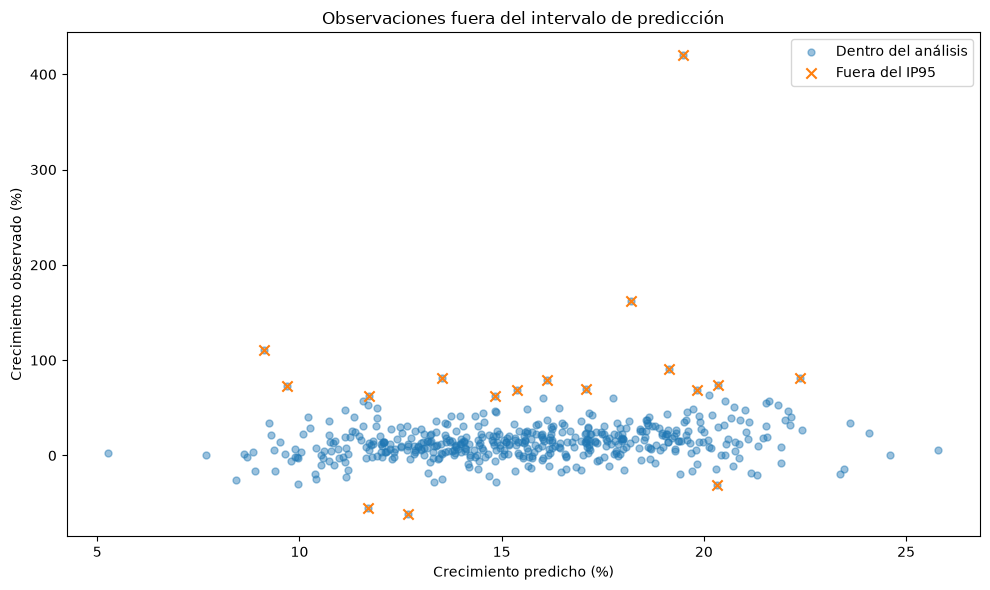

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\observaciones_fuera_ip95_regresion_multiple.png


In [125]:
# ============================================================
# 15.12 Casos no cubiertos por el intervalo
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    df_test["Y_PREDICHO_MULTIPLE"],
    df_test[Y],
    alpha=0.45,
    s=25,
    label="Dentro del análisis"
)

if len(municipios_fuera_ip) > 0:

    ax.scatter(
        municipios_fuera_ip[
            "Y_PREDICHO_MULTIPLE"
        ],
        municipios_fuera_ip[Y],
        s=55,
        marker="x",
        label="Fuera del IP95"
    )

ax.set_xlabel(
    "Crecimiento predicho (%)"
)

ax.set_ylabel(
    "Crecimiento observado (%)"
)

ax.set_title(
    "Observaciones fuera del intervalo de predicción"
)

ax.legend()

plt.tight_layout()

ruta_fuera_ip = (
    OUTPUT_DIR /
    "observaciones_fuera_ip95_regresion_multiple.png"
)

plt.savefig(
    ruta_fuera_ip,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: {ruta_fuera_ip}"
)

In [126]:
# ============================================================
# 15.13 Resumen de intervalos de predicción
# ============================================================

resumen_intervalos = pd.DataFrame({
    "Indicador": [
        "N prueba",
        "Municipios dentro IP95",
        "Municipios fuera IP95",
        "Cobertura IP95 (%)",
        "Ancho medio IP95",
        "Ancho mediano IP95",
        "Fuera por arriba",
        "Fuera por abajo"
    ],

    "Resultado": [
        len(df_test),
        n_dentro,
        n_fuera,
        cobertura_ip95,
        df_test["ANCHO_IP95"].mean(),
        df_test["ANCHO_IP95"].median(),
        n_superior,
        n_inferior
    ]
})

display(
    resumen_intervalos.round(4)
)

,Indicador,Resultado
0,N prueba,488.0000
1,Municipios dentro IP95,471.0000
2,Municipios fuera IP95,17.0000
3,Cobertura IP95 (%),96.5164
4,Ancho medio IP95,95.2049
5,Ancho mediano IP95,95.1799
6,Fuera por arriba,14.0000
7,Fuera por abajo,3.0000


## 15.14. Cobertura frente a precisión

La calidad de un intervalo de predicción no debe evaluarse únicamente por su porcentaje de cobertura.

Un intervalo muy amplio puede contener una proporción elevada de observaciones, pero proporcionar poca precisión para una decisión individual.

Por esta razón, la evaluación considera conjuntamente:

- la cobertura empírica;
- la amplitud media y mediana;
- la distribución de los casos que quedan fuera del intervalo.

Una cobertura próxima al nivel nominal del 95% será favorable desde el punto de vista probabilístico, pero deberá interpretarse junto con el ancho de los intervalos para valorar su utilidad práctica.

## 15.15. Limitaciones de los intervalos

Los intervalos de predicción se construyen a partir del modelo lineal estimado y de sus supuestos estadísticos.

En este proyecto se detectó una fuerte desviación de la normalidad de los residuos, asociada principalmente con observaciones extremas. Por ello, los intervalos deben interpretarse como una aproximación basada en la especificación MCO y no como límites exactos para todos los municipios.

La cobertura empírica sobre la muestra de prueba proporciona una comprobación adicional de su comportamiento real fuera de muestra.

Los intervalos de predicción al 95% permiten incorporar explícitamente la incertidumbre asociada con las predicciones individuales del modelo múltiple. Sobre los 488 municipios de prueba, 471 valores observados quedaron dentro de sus respectivos intervalos, lo que representa una cobertura empírica de 96.52%.

Esta cobertura es cercana y ligeramente superior al nivel nominal del 95%. Sin embargo, debe interpretarse conjuntamente con la amplitud de los intervalos. El ancho promedio fue de 95.20 puntos porcentuales y la mediana de 95.18 puntos, lo que evidencia una incertidumbre considerable al intentar anticipar el crecimiento de un municipio individual.

En contraste, el intervalo de confianza para el crecimiento promedio presenta una amplitud media de aproximadamente 4.63 puntos porcentuales. Esta diferencia muestra que el modelo estima con mayor precisión el comportamiento promedio asociado con determinadas características municipales que el resultado particular de un municipio.

De los 17 municipios no cubiertos por los intervalos, 14 se ubicaron por encima del límite superior y 3 por debajo del límite inferior. Este patrón confirma que la principal dificultad del modelo se encuentra en anticipar comportamientos extremos, particularmente tasas de crecimiento excepcionalmente elevadas.

Los resultados son consistentes con los diagnósticos anteriores: la variable dependiente presenta una fuerte cola derecha, existen observaciones influyentes y los mayores errores predictivos se concentran en municipios con comportamientos alejados del patrón central.

Por tanto, aunque los intervalos presentan una cobertura empírica adecuada, su amplitud limita la precisión práctica de las predicciones municipales individuales. El modelo resulta más informativo para estudiar asociaciones y comportamientos promedio que para realizar pronósticos puntuales de alta precisión sobre municipios específicos.

# FASE 16 — Comparación con benchmark y modelo simple

El desempeño predictivo de una regresión no debe evaluarse de manera aislada. Para determinar si la complejidad adicional del modelo múltiple aporta una mejora real, sus resultados se comparan con dos referencias.

La primera es un benchmark sencillo que predice para todos los municipios de prueba el promedio del crecimiento observado en la muestra de entrenamiento.

La segunda corresponde al mejor modelo de regresión lineal simple identificado previamente, basado en pobreza.

Los tres modelos se evalúan sobre exactamente los mismos 488 municipios de prueba mediante RMSE, MAE, \(R^2\) fuera de muestra y WAPE.

La comparación permitirá determinar si incorporar simultáneamente las cuatro características municipales produce una mejora predictiva suficiente respecto a alternativas más sencillas.

In [127]:
# ============================================================
# FASE 16 — COMPARACIÓN CON BENCHMARK Y MODELO SIMPLE
# 16.1 Benchmark: media de entrenamiento
# ============================================================

media_y_train = df_train[Y].mean()

pred_benchmark = np.repeat(
    media_y_train,
    len(df_test)
)

print("BENCHMARK")
print("=" * 55)

print(
    f"Media de Y en entrenamiento: "
    f"{media_y_train:.4f}"
)

print(
    f"N predicciones benchmark: "
    f"{len(pred_benchmark):,}"
)

BENCHMARK
Media de Y en entrenamiento: 15.4351
N predicciones benchmark: 488


In [128]:
# ============================================================
# 16.2 Mejor modelo simple:
#      pobreza
# ============================================================

formula_simple_pobreza = (
    f"{Y} ~ POBREZA_2020"
)

modelo_simple_train = smf.ols(
    formula=formula_simple_pobreza,
    data=df_train
).fit()

pred_simple = modelo_simple_train.predict(
    df_test
).to_numpy()

print("MODELO SIMPLE — POBREZA")
print("=" * 55)

print(
    f"N entrenamiento: "
    f"{int(modelo_simple_train.nobs):,}"
)

print(
    f"R² entrenamiento: "
    f"{modelo_simple_train.rsquared:.4f}"
)

print("\nCoeficientes:")

display(
    modelo_simple_train.params
    .to_frame("Coeficiente")
    .round(4)
)

MODELO SIMPLE — POBREZA
N entrenamiento: 1,952
R² entrenamiento: 0.0097

Coeficientes:


,Coeficiente
Intercept,8.5997
POBREZA_2020,0.1104


In [129]:
# ============================================================
# 16.3 Verificación
# ============================================================

print(
    f"Benchmark: {len(pred_benchmark):,} predicciones"
)

print(
    f"Modelo simple: {len(pred_simple):,} predicciones"
)

print(
    f"Modelo múltiple: {len(y_pred):,} predicciones"
)

if (
    len(pred_benchmark)
    == len(pred_simple)
    == len(y_pred)
    == len(y_test)
):
    print(
        "\n✓ Los tres modelos se evaluarán "
        "sobre exactamente la misma muestra."
    )

Benchmark: 488 predicciones
Modelo simple: 488 predicciones
Modelo múltiple: 488 predicciones

✓ Los tres modelos se evaluarán sobre exactamente la misma muestra.


In [130]:
# ============================================================
# 16.4 Función común de evaluación predictiva
# ============================================================

def evaluar_prediccion(y_real, y_estimado):

    mse = mean_squared_error(
        y_real,
        y_estimado
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_real,
        y_estimado
    )

    r2 = r2_score(
        y_real,
        y_estimado
    )

    wape = (
        np.sum(
            np.abs(
                y_real - y_estimado
            )
        )
        /
        np.sum(
            np.abs(y_real)
        )
        * 100
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R² test": r2,
        "WAPE (%)": wape
    }

In [131]:
# ============================================================
# 16.5 Comparación de desempeño
# ============================================================

metricas_benchmark = evaluar_prediccion(
    y_test,
    pred_benchmark
)

metricas_simple = evaluar_prediccion(
    y_test,
    pred_simple
)

metricas_multiple = evaluar_prediccion(
    y_test,
    y_pred
)

tabla_comparacion_predictiva = pd.DataFrame(
    [
        {
            "Modelo": "Benchmark — media train",
            **metricas_benchmark
        },
        {
            "Modelo": "Simple — Pobreza",
            **metricas_simple
        },
        {
            "Modelo": "Múltiple — 4 predictores",
            **metricas_multiple
        }
    ]
)

display(
    tabla_comparacion_predictiva.round(4)
)

,Modelo,MSE,RMSE,MAE,R² test,WAPE (%)
0,Benchmark — media train,760.8616,27.5837,15.1847,-0.0006,76.4954
1,Simple — Pobreza,743.9791,27.2760,14.7773,0.0216,74.4429
2,Múltiple — 4 predictores,738.0624,27.1673,14.7159,0.0293,74.1335


In [132]:
# ============================================================
# 16.6 Mejora de la regresión múltiple
#      respecto al benchmark
# ============================================================

mejora_benchmark = {
    "RMSE (%)": (
        (
            metricas_benchmark["RMSE"]
            - metricas_multiple["RMSE"]
        )
        / metricas_benchmark["RMSE"]
        * 100
    ),

    "MAE (%)": (
        (
            metricas_benchmark["MAE"]
            - metricas_multiple["MAE"]
        )
        / metricas_benchmark["MAE"]
        * 100
    ),

    "WAPE (%)": (
        (
            metricas_benchmark["WAPE (%)"]
            - metricas_multiple["WAPE (%)"]
        )
        / metricas_benchmark["WAPE (%)"]
        * 100
    )
}

tabla_mejora_benchmark = pd.DataFrame(
    mejora_benchmark.items(),
    columns=[
        "Métrica",
        "Mejora del múltiple (%)"
    ]
)

display(
    tabla_mejora_benchmark.round(4)
)

,Métrica,Mejora del múltiple (%)
0,RMSE (%),1.5096
1,MAE (%),3.0877
2,WAPE (%),3.0877


In [133]:
# ============================================================
# 16.7 Mejora frente al mejor modelo simple
# ============================================================

mejora_simple = {
    "RMSE (%)": (
        (
            metricas_simple["RMSE"]
            - metricas_multiple["RMSE"]
        )
        / metricas_simple["RMSE"]
        * 100
    ),

    "MAE (%)": (
        (
            metricas_simple["MAE"]
            - metricas_multiple["MAE"]
        )
        / metricas_simple["MAE"]
        * 100
    ),

    "WAPE (%)": (
        (
            metricas_simple["WAPE (%)"]
            - metricas_multiple["WAPE (%)"]
        )
        / metricas_simple["WAPE (%)"]
        * 100
    )
}

tabla_mejora_simple = pd.DataFrame(
    mejora_simple.items(),
    columns=[
        "Métrica",
        "Mejora del múltiple (%)"
    ]
)

display(
    tabla_mejora_simple.round(4)
)

,Métrica,Mejora del múltiple (%)
0,RMSE (%),0.3984
1,MAE (%),0.4156
2,WAPE (%),0.4156


In [134]:
# ============================================================
# 16.8 Comparación del R² fuera de muestra
# ============================================================

ganancia_r2_vs_benchmark = (
    metricas_multiple["R² test"]
    - metricas_benchmark["R² test"]
)

ganancia_r2_vs_simple = (
    metricas_multiple["R² test"]
    - metricas_simple["R² test"]
)

print("GANANCIA EN R² TEST")
print("=" * 55)

print(
    "Múltiple vs. benchmark: "
    f"{ganancia_r2_vs_benchmark:.4f}"
)

print(
    "Múltiple vs. modelo simple: "
    f"{ganancia_r2_vs_simple:.4f}"
)

GANANCIA EN R² TEST
Múltiple vs. benchmark: 0.0300
Múltiple vs. modelo simple: 0.0078


In [ ]:
# ============================================================
# 16.9 Comparación gráfica de errores
# ============================================================

tabla_errores_plot = (
    tabla_comparacion_predictiva[
        [
            "Modelo",
            "RMSE",
            "MAE"
        ]
    ]
    .set_index("Modelo")
)

ax = tabla_errores_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_ylabel(
    "Error (puntos porcentuales)"
)

ax.set_xlabel("")

ax.set_title(
    "Desempeño predictivo fuera de muestra"
)

ax.tick_params(
    axis="x",
    rotation=0
)

plt.tight_layout()

ruta_comparacion_errores = (
    OUTPUT_DIR /
    "comparacion_predictiva_modelos.png"
)

plt.savefig(
    ruta_comparacion_errores,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: "
    f"{ruta_comparacion_errores}"
)

In [135]:
# ============================================================
# 16.10 Comparación del sesgo promedio
# ============================================================

residuos_benchmark = (
    y_test - pred_benchmark
)

residuos_simple = (
    y_test - pred_simple
)

residuos_multiple = (
    y_test - y_pred
)

tabla_sesgo = pd.DataFrame({
    "Modelo": [
        "Benchmark",
        "Simple — Pobreza",
        "Múltiple"
    ],

    "Media residuo": [
        residuos_benchmark.mean(),
        residuos_simple.mean(),
        residuos_multiple.mean()
    ],

    "Mediana residuo": [
        np.median(residuos_benchmark),
        np.median(residuos_simple),
        np.median(residuos_multiple)
    ]
})

display(
    tabla_sesgo.round(4)
)

,Modelo,Media residuo,Mediana residuo
0,Benchmark,0.6950,-1.4453
1,Simple — Pobreza,0.6427,-1.7069
2,Múltiple,0.5048,-2.1575


In [136]:
# ============================================================
# 16.11 Intervalos del modelo simple
# ============================================================

pred_simple_completa = (
    modelo_simple_train
    .get_prediction(df_test)
    .summary_frame(alpha=0.05)
)

ip_simple_inf = (
    pred_simple_completa[
        "obs_ci_lower"
    ].to_numpy()
)

ip_simple_sup = (
    pred_simple_completa[
        "obs_ci_upper"
    ].to_numpy()
)

dentro_simple = (
    (y_test >= ip_simple_inf)
    &
    (y_test <= ip_simple_sup)
)

cobertura_simple = (
    100
    * dentro_simple.mean()
)

ancho_simple = (
    ip_simple_sup
    - ip_simple_inf
)

print(
    f"Cobertura IP95 modelo simple: "
    f"{cobertura_simple:.2f}%"
)

print(
    f"Ancho medio IP95 modelo simple: "
    f"{ancho_simple.mean():.4f}"
)

Cobertura IP95 modelo simple: 96.52%
Ancho medio IP95 modelo simple: 95.4729


In [137]:
# ============================================================
# 16.12 Comparación de intervalos predictivos
# ============================================================

tabla_comparacion_intervalos = pd.DataFrame({
    "Modelo": [
        "Simple — Pobreza",
        "Múltiple"
    ],

    "Cobertura IP95 (%)": [
        cobertura_simple,
        cobertura_ip95
    ],

    "Ancho medio IP95": [
        ancho_simple.mean(),
        df_test["ANCHO_IP95"].mean()
    ],

    "Ancho mediano IP95": [
        np.median(ancho_simple),
        df_test["ANCHO_IP95"].median()
    ]
})

display(
    tabla_comparacion_intervalos.round(4)
)

,Modelo,Cobertura IP95 (%),Ancho medio IP95,Ancho mediano IP95
0,Simple — Pobreza,96.5164,95.4729,95.4656
1,Múltiple,96.5164,95.2049,95.1799


## 16.13. Criterio de comparación

La selección entre modelos no se basa únicamente en identificar cuál presenta el menor error.

También debe evaluarse la magnitud de la mejora obtenida respecto a alternativas más sencillas.

Si la regresión múltiple reduce ligeramente RMSE y MAE pero la diferencia respecto al modelo simple es mínima, la mejora predictiva deberá describirse como marginal.

En ese escenario, la principal aportación de la regresión múltiple continuaría siendo inferencial: permitir estimar asociaciones parciales entre las características municipales y el crecimiento comercial, más que producir un incremento sustancial de la precisión predictiva.

## 16.14. Desempeño relativo y desempeño absoluto

Es importante distinguir entre desempeño relativo y desempeño absoluto.

Un modelo puede presentar mejores métricas que las alternativas y, al mismo tiempo, conservar una capacidad predictiva limitada.

En este proyecto, la comparación permitirá determinar cuál de las especificaciones produce los menores errores sobre la muestra de prueba. Sin embargo, la valoración final deberá considerar también el nivel absoluto de RMSE, MAE, WAPE y \(R^2\) fuera de muestra.

Por tanto, identificar al modelo múltiple como la mejor alternativa relativa no será equivalente a afirmar que posee una elevada precisión para predecir el crecimiento de municipios individuales.

In [138]:
# ============================================================
# 16.15 Tabla ejecutiva de comparación predictiva
# ============================================================

tabla_ejecutiva_pred = (
    tabla_comparacion_predictiva[
        [
            "Modelo",
            "RMSE",
            "MAE",
            "R² test",
            "WAPE (%)"
        ]
    ]
    .copy()
)

display(
    tabla_ejecutiva_pred.round(4)
)

,Modelo,RMSE,MAE,R² test,WAPE (%)
0,Benchmark — media train,27.5837,15.1847,-0.0006,76.4954
1,Simple — Pobreza,27.2760,14.7773,0.0216,74.4429
2,Múltiple — 4 predictores,27.1673,14.7159,0.0293,74.1335


Cierre de la Fase 16

La comparación predictiva se realizó sobre los mismos 488 municipios de prueba, utilizando como referencias un benchmark basado en la media del conjunto de entrenamiento, el mejor modelo simple —pobreza— y la regresión múltiple con cuatro predictores.

La regresión múltiple presenta el mejor desempeño relativo. Su RMSE fue de 27.1673, frente a 27.2760 en el modelo simple y 27.5837 en el benchmark. De manera similar, el MAE disminuyó a 14.7159 y el WAPE a 74.1335%, mientras que el \(R^2\) fuera de muestra alcanzó 0.0293.

Frente al benchmark, el modelo múltiple reduce el RMSE aproximadamente 1.51% y el MAE y WAPE alrededor de 3.09%. Sin embargo, frente al modelo simple de pobreza, las mejoras son considerablemente menores: aproximadamente 0.40% en RMSE y 0.42% en MAE y WAPE.

Los intervalos de predicción muestran una conclusión similar. Ambos modelos alcanzan una cobertura empírica de 96.52%, mientras que el intervalo del modelo múltiple presenta una amplitud media ligeramente menor, de 95.20 puntos porcentuales, frente a 95.47 en el modelo simple.

En consecuencia, incorporar simultáneamente las cuatro variables produce una mejora predictiva consistente, pero de magnitud reducida. El modelo múltiple supera al benchmark y al modelo simple en todas las métricas principales, aunque la diferencia respecto al modelo de pobreza es marginal y la precisión absoluta continúa siendo limitada.

Por ello, la principal aportación de la regresión múltiple en este proyecto no radica en un incremento sustancial de la capacidad predictiva, sino en su valor inferencial: permite distinguir asociaciones bivariadas de asociaciones parciales y evaluar cuáles relaciones se mantienen después de considerar simultáneamente las características municipales.

# FASE 17 — Comparación de especificaciones ampliadas

El modelo múltiple base permitió analizar conjuntamente razón de dependencia, escolaridad, informalidad y pobreza. Sin embargo, su capacidad explicativa y predictiva continúa siendo reducida.

Esta fase evalúa si incorporar características estructurales del municipio mejora la especificación. Se consideran dos controles disponibles para 2020:

1. el tamaño poblacional inicial, expresado mediante el logaritmo natural de la población;
2. la densidad comercial inicial.

Se comparan cuatro especificaciones:

\[
M_1:
Y=f(Dependencia,Escolaridad,Informalidad,Pobreza)
\]

\[
M_2:
M_1+\ln(POB_{2020})
\]

\[
M_3:
M_1+DENSIDAD_{2020}
\]

\[
M_4:
M_1+\ln(POB_{2020})+DENSIDAD_{2020}
\]

El propósito es determinar si estos controles aportan información adicional, modifican las asociaciones socioeconómicas previamente estimadas o mejoran el desempeño predictivo fuera de muestra.

Los modelos ampliados se interpretarán como análisis de especificación y sensibilidad. En particular, la densidad comercial inicial y la población de 2020 están relacionadas con la construcción de la variable dependiente, por lo que sus coeficientes no serán interpretados como efectos causales.

In [139]:
# ============================================================
# FASE 17 — COMPARACIÓN DE ESPECIFICACIONES AMPLIADAS
# 17.1 Preparación de controles adicionales
# ============================================================

controles_2020 = (
    df[
        [
            "CVEGEO",
            "POB_2020",
            "DENSIDAD_RETAIL_2020"
        ]
    ]
    .drop_duplicates(subset="CVEGEO")
)

df_especificaciones = (
    df_estimacion
    .merge(
        controles_2020,
        on="CVEGEO",
        how="left",
        validate="one_to_one",
        sort=False
    )
)

print("VERIFICACIÓN DE CONTROLES")
print("=" * 60)

print(
    f"Observaciones: "
    f"{len(df_especificaciones):,}"
)

print(
    "Nulos POB_2020:",
    df_especificaciones["POB_2020"].isna().sum()
)

print(
    "Nulos DENSIDAD_RETAIL_2020:",
    df_especificaciones[
        "DENSIDAD_RETAIL_2020"
    ].isna().sum()
)

print(
    "POB_2020 <= 0:",
    (
        df_especificaciones["POB_2020"] <= 0
    ).sum()
)

print(
    "DENSIDAD_RETAIL_2020 <= 0:",
    (
        df_especificaciones[
            "DENSIDAD_RETAIL_2020"
        ] <= 0
    ).sum()
)

VERIFICACIÓN DE CONTROLES
Observaciones: 2,440
Nulos POB_2020: 0
Nulos DENSIDAD_RETAIL_2020: 0
POB_2020 <= 0: 0
DENSIDAD_RETAIL_2020 <= 0: 0


In [140]:
# ============================================================
# 17.1.1 Transformación logarítmica de población
# ============================================================

if (
    df_especificaciones["POB_2020"] <= 0
).any():

    raise ValueError(
        "Existen valores de POB_2020 <= 0. "
        "No puede calcularse el logaritmo."
    )

df_especificaciones[
    "LN_POB_2020"
] = np.log(
    df_especificaciones["POB_2020"]
)

print(
    "Variable LN_POB_2020 creada correctamente."
)

print(
    f"Mínimo: "
    f"{df_especificaciones['LN_POB_2020'].min():.4f}"
)

print(
    f"Máximo: "
    f"{df_especificaciones['LN_POB_2020'].max():.4f}"
)

Variable LN_POB_2020 creada correctamente.
Mínimo: 4.3944
Máximo: 14.4892


In [141]:
# ============================================================
# 17.1.2 Descriptivos de nuevos controles
# ============================================================

variables_nuevas = [
    "POB_2020",
    "LN_POB_2020",
    "DENSIDAD_RETAIL_2020"
]

tabla_controles = (
    df_especificaciones[
        variables_nuevas
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95
        ]
    )
    .T
)

display(
    tabla_controles.round(4)
)

,count,mean,std,min,5%,25%,50%,75%,95%,max
POB_2020,"2,440.0000","50,352.3139","145,909.4438",81.0000,956.6000,"4,486.5000","13,553.0000","35,390.5000","189,328.8000","1,961,388.0000"
LN_POB_2020,"2,440.0000",9.4805,1.5907,4.3944,6.8634,8.4088,9.5144,10.4742,12.1512,14.4892
DENSIDAD_RETAIL_2020,"2,440.0000",17.0392,9.0308,0.5220,4.4391,10.6950,16.1914,21.8642,33.1297,105.9441


In [142]:
# ============================================================
# 17.1.3 Correlación descriptiva con Y
# ============================================================

resultados_controles = []

for variable in [
    "LN_POB_2020",
    "DENSIDAD_RETAIL_2020"
]:

    r, p = stats.pearsonr(
        df_especificaciones[Y],
        df_especificaciones[variable]
    )

    resultados_controles.append({
        "Variable": variable,
        "r Pearson": r,
        "Valor-p": p
    })

tabla_corr_controles = pd.DataFrame(
    resultados_controles
)

display(
    tabla_corr_controles.round(4)
)

,Variable,r Pearson,Valor-p
0,LN_POB_2020,0.0254,0.2102
1,DENSIDAD_RETAIL_2020,-0.2007,0.0000


In [143]:
# ============================================================
# 17.2 Definición de especificaciones
# ============================================================

formula_m1 = (
    f"{Y} ~ "
    "RAZ_DEP_2020 + "
    "GRAPROES_2020 + "
    "TASA_INFORMALIDAD_2020 + "
    "POBREZA_2020"
)

formula_m2 = (
    formula_m1
    + " + LN_POB_2020"
)

formula_m3 = (
    formula_m1
    + " + DENSIDAD_RETAIL_2020"
)

formula_m4 = (
    formula_m1
    + " + LN_POB_2020"
    + " + DENSIDAD_RETAIL_2020"
)

formulas = {
    "M1 Base": formula_m1,
    "M2 + ln(Población)": formula_m2,
    "M3 + Densidad inicial": formula_m3,
    "M4 + Población + Densidad": formula_m4
}

for nombre, formula in formulas.items():

    print(f"\n{nombre}")
    print(formula)


M1 Base
CREC_DENSIDAD_RETAIL_2020_2025 ~ RAZ_DEP_2020 + GRAPROES_2020 + TASA_INFORMALIDAD_2020 + POBREZA_2020

M2 + ln(Población)
CREC_DENSIDAD_RETAIL_2020_2025 ~ RAZ_DEP_2020 + GRAPROES_2020 + TASA_INFORMALIDAD_2020 + POBREZA_2020 + LN_POB_2020

M3 + Densidad inicial
CREC_DENSIDAD_RETAIL_2020_2025 ~ RAZ_DEP_2020 + GRAPROES_2020 + TASA_INFORMALIDAD_2020 + POBREZA_2020 + DENSIDAD_RETAIL_2020

M4 + Población + Densidad
CREC_DENSIDAD_RETAIL_2020_2025 ~ RAZ_DEP_2020 + GRAPROES_2020 + TASA_INFORMALIDAD_2020 + POBREZA_2020 + LN_POB_2020 + DENSIDAD_RETAIL_2020


In [144]:
# ============================================================
# 17.3 - 17.5 Estimación de las cuatro especificaciones
# ============================================================

modelos_especificacion = {}

for nombre, formula in formulas.items():

    modelo = smf.ols(
        formula=formula,
        data=df_especificaciones
    ).fit()

    modelos_especificacion[nombre] = modelo

print("MODELOS ESTIMADOS")
print("=" * 65)

for nombre, modelo in modelos_especificacion.items():

    print(
        f"{nombre:<30} "
        f"N={int(modelo.nobs):,}  "
        f"R²={modelo.rsquared:.4f}  "
        f"R²aj={modelo.rsquared_adj:.4f}"
    )

MODELOS ESTIMADOS
M1 Base                        N=2,440  R²=0.0215  R²aj=0.0199
M2 + ln(Población)             N=2,440  R²=0.0250  R²aj=0.0230
M3 + Densidad inicial          N=2,440  R²=0.0669  R²aj=0.0650
M4 + Población + Densidad      N=2,440  R²=0.0670  R²aj=0.0647


In [145]:
# ============================================================
# 17.6 Comparación de coeficientes socioeconómicos
# ============================================================

variables_base = [
    "RAZ_DEP_2020",
    "GRAPROES_2020",
    "TASA_INFORMALIDAD_2020",
    "POBREZA_2020"
]

comparacion_betas = []

for variable in variables_base:

    fila = {
        "Variable": variable
    }

    for nombre, modelo in modelos_especificacion.items():

        fila[nombre] = (
            modelo.params[variable]
        )

    comparacion_betas.append(fila)

tabla_betas_especificaciones = pd.DataFrame(
    comparacion_betas
)

display(
    tabla_betas_especificaciones.round(4)
)

,Variable,M1 Base,M2 + ln(Población),M3 + Densidad inicial,M4 + Población + Densidad
0,RAZ_DEP_2020,-0.3247,-0.2921,-0.3624,-0.3571
1,GRAPROES_2020,-1.1026,-1.3698,0.0610,0.0091
2,TASA_INFORMALIDAD_2020,0.0626,0.1178,0.0563,0.0646
3,POBREZA_2020,0.1357,0.1174,0.1963,0.1929


In [146]:
# ============================================================
# 17.7 Comparación de R² y R² ajustado
# ============================================================

comparacion_ajuste = []

for nombre, modelo in modelos_especificacion.items():

    comparacion_ajuste.append({
        "Modelo": nombre,
        "N": int(modelo.nobs),
        "Número predictores":
            int(modelo.df_model),
        "R²":
            modelo.rsquared,
        "R² ajustado":
            modelo.rsquared_adj
    })

tabla_r2_especificaciones = pd.DataFrame(
    comparacion_ajuste
)

display(
    tabla_r2_especificaciones.round(4)
)

,Modelo,N,Número predictores,R²,R² ajustado
0,M1 Base,2440,4,0.0215,0.0199
1,M2 + ln(Población),2440,5,0.0250,0.0230
2,M3 + Densidad inicial,2440,5,0.0669,0.0650
3,M4 + Población + Densidad,2440,6,0.0670,0.0647


In [147]:
# ============================================================
# 17.8 Comparación de AIC y BIC
# ============================================================

tabla_ic_modelos = pd.DataFrame({
    "Modelo":
        list(modelos_especificacion.keys()),

    "AIC": [
        modelo.aic
        for modelo
        in modelos_especificacion.values()
    ],

    "BIC": [
        modelo.bic
        for modelo
        in modelos_especificacion.values()
    ]
})

display(
    tabla_ic_modelos.round(2)
)

,Modelo,AIC,BIC
0,M1 Base,"22,608.2000","22,637.2000"
1,M2 + ln(Población),"22,601.3000","22,636.1000"
2,M3 + Densidad inicial,"22,494.2600","22,529.0600"
3,M4 + Población + Densidad,"22,496.0600","22,536.6600"


In [148]:
# ============================================================
# 17.8.1 Pruebas F entre modelos anidados
# ============================================================

m1 = modelos_especificacion[
    "M1 Base"
]

m2 = modelos_especificacion[
    "M2 + ln(Población)"
]

m3 = modelos_especificacion[
    "M3 + Densidad inicial"
]

m4 = modelos_especificacion[
    "M4 + Población + Densidad"
]

comparaciones_f = []

pares = [
    ("M1 vs M2", m2, m1),
    ("M1 vs M3", m3, m1),
    ("M1 vs M4", m4, m1),
    ("M2 vs M4", m4, m2),
    ("M3 vs M4", m4, m3)
]

for nombre, completo, restringido in pares:

    f_stat, p_value, df_diff = (
        completo.compare_f_test(
            restringido
        )
    )

    comparaciones_f.append({
        "Comparación": nombre,
        "F": f_stat,
        "Valor-p": p_value,
        "gl diferencia": df_diff
    })

tabla_comparacion_f = pd.DataFrame(
    comparaciones_f
)

display(
    tabla_comparacion_f.round(6)
)

,Comparación,F,Valor-p,gl diferencia
0,M1 vs M2,8.8984,0.0029,1.0000
1,M1 vs M3,118.4488,0.0000,1.0000
2,M1 vs M4,59.3036,0.0000,2.0000
3,M2 vs M4,109.3128,0.0000,1.0000
4,M3 vs M4,0.1974,0.6569,1.0000


In [149]:
# ============================================================
# 17.9 Función para calcular VIF
# ============================================================

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

def calcular_vif(data, predictores):

    matriz = sm.add_constant(
        data[predictores]
    )

    resultados = []

    for i, variable in enumerate(
        matriz.columns
    ):

        if variable == "const":
            continue

        vif = variance_inflation_factor(
            matriz.values,
            i
        )

        resultados.append({
            "Variable": variable,
            "VIF": vif,
            "Tolerancia": 1 / vif
        })

    return pd.DataFrame(resultados)

In [150]:
# ============================================================
# 17.9.1 VIF por especificación
# ============================================================

predictores_modelos = {
    "M1 Base":
        variables_base,

    "M2 + ln(Población)":
        variables_base
        + ["LN_POB_2020"],

    "M3 + Densidad inicial":
        variables_base
        + ["DENSIDAD_RETAIL_2020"],

    "M4 + Población + Densidad":
        variables_base
        + [
            "LN_POB_2020",
            "DENSIDAD_RETAIL_2020"
        ]
}

tablas_vif = []

for nombre, predictores in predictores_modelos.items():

    tmp = calcular_vif(
        df_especificaciones,
        predictores
    )

    tmp.insert(
        0,
        "Modelo",
        nombre
    )

    tablas_vif.append(tmp)

tabla_vif_especificaciones = pd.concat(
    tablas_vif,
    ignore_index=True
)

display(
    tabla_vif_especificaciones.round(4)
)

,Modelo,Variable,VIF,Tolerancia
0,M1 Base,RAZ_DEP_2020,2.4373,0.4103
1,M1 Base,GRAPROES_2020,3.3217,0.3011
2,M1 Base,TASA_INFORMALIDAD_2020,2.9987,0.3335
3,M1 Base,POBREZA_2020,2.3533,0.4249
4,M2 + ln(Población),RAZ_DEP_2020,2.4941,0.4009
5,M2 + ln(Población),GRAPROES_2020,3.3919,0.2948
6,M2 + ln(Población),TASA_INFORMALIDAD_2020,3.2995,0.3031
7,M2 + ln(Población),POBREZA_2020,2.4246,0.4124
8,M2 + ln(Población),LN_POB_2020,1.6126,0.6201
9,M3 + Densidad inicial,RAZ_DEP_2020,2.4432,0.4093


In [151]:
# ============================================================
# 17.10 Inferencia robusta HC3
# ============================================================

modelos_hc3 = {}

tablas_hc3 = []

for nombre, modelo in modelos_especificacion.items():

    robusto = modelo.get_robustcov_results(
        cov_type="HC3"
    )

    modelos_hc3[nombre] = robusto

    parametros = list(
        modelo.params.index
    )

    ic = robusto.conf_int(
        alpha=0.05
    )

    tmp = pd.DataFrame({
        "Modelo": nombre,
        "Variable": parametros,
        "Coeficiente": robusto.params,
        "SE HC3": robusto.bse,
        "t HC3": robusto.tvalues,
        "p HC3": robusto.pvalues,
        "IC inferior": ic[:, 0],
        "IC superior": ic[:, 1]
    })

    tablas_hc3.append(tmp)

tabla_hc3_especificaciones = pd.concat(
    tablas_hc3,
    ignore_index=True
)

display(
    tabla_hc3_especificaciones.round(4)
)

,Modelo,Variable,Coeficiente,SE HC3,t HC3,p HC3,IC inferior,IC superior
0,M1 Base,Intercept,31.1577,9.2870,3.3550,0.0008,12.9465,49.3689
1,M1 Base,RAZ_DEP_2020,-0.3247,0.0856,-3.7913,0.0002,-0.4927,-0.1568
2,M1 Base,GRAPROES_2020,-1.1026,0.5537,-1.9915,0.0465,-2.1883,-0.0169
3,M1 Base,TASA_INFORMALIDAD_2020,0.0626,0.0638,0.9811,0.3266,-0.0625,0.1878
4,M1 Base,POBREZA_2020,0.1357,0.0373,3.6332,0.0003,0.0625,0.2089
5,M2 + ln(Población),Intercept,16.7489,11.0637,1.5139,0.1302,-4.9464,38.4442
6,M2 + ln(Población),RAZ_DEP_2020,-0.2921,0.0866,-3.3723,0.0008,-0.4619,-0.1222
7,M2 + ln(Población),GRAPROES_2020,-1.3698,0.5647,-2.4259,0.0153,-2.4771,-0.2625
8,M2 + ln(Población),TASA_INFORMALIDAD_2020,0.1178,0.0684,1.7230,0.0850,-0.0163,0.2518
9,M2 + ln(Población),POBREZA_2020,0.1174,0.0396,2.9610,0.0031,0.0396,0.1951


In [152]:
# ============================================================
# 17.11 Estabilidad de signos y significancia HC3
# ============================================================

estabilidad = []

for variable in variables_base:

    fila = {
        "Variable": variable
    }

    for nombre in modelos_especificacion.keys():

        subset = (
            tabla_hc3_especificaciones[
                (
                    tabla_hc3_especificaciones[
                        "Modelo"
                    ] == nombre
                )
                &
                (
                    tabla_hc3_especificaciones[
                        "Variable"
                    ] == variable
                )
            ]
            .iloc[0]
        )

        fila[
            f"Beta {nombre}"
        ] = subset["Coeficiente"]

        fila[
            f"p {nombre}"
        ] = subset["p HC3"]

    estabilidad.append(fila)

tabla_estabilidad = pd.DataFrame(
    estabilidad
)

display(
    tabla_estabilidad.round(4)
)

,Variable,Beta M1 Base,p M1 Base,Beta M2 + ln(Población),p M2 + ln(Población),Beta M3 + Densidad inicial,p M3 + Densidad inicial,Beta M4 + Población + Densidad,p M4 + Población + Densidad
0,RAZ_DEP_2020,-0.3247,0.0002,-0.2921,0.0008,-0.3624,0.0000,-0.3571,0.0000
1,GRAPROES_2020,-1.1026,0.0465,-1.3698,0.0153,0.0610,0.9129,0.0091,0.9879
2,TASA_INFORMALIDAD_2020,0.0626,0.3266,0.1178,0.0850,0.0563,0.3654,0.0646,0.3496
3,POBREZA_2020,0.1357,0.0003,0.1174,0.0031,0.1963,0.0000,0.1929,0.0000


In [153]:
# ============================================================
# 17.12 Preparación de train/test
#       manteniendo exactamente la misma partición
# ============================================================

control_lookup = (
    controles_2020
    .set_index("CVEGEO")
)

df_train_17 = df_train.copy()
df_test_17 = df_test.copy()

for variable in [
    "POB_2020",
    "DENSIDAD_RETAIL_2020"
]:

    df_train_17[variable] = (
        df_train_17["CVEGEO"]
        .map(
            control_lookup[variable]
        )
    )

    df_test_17[variable] = (
        df_test_17["CVEGEO"]
        .map(
            control_lookup[variable]
        )
    )

df_train_17["LN_POB_2020"] = np.log(
    df_train_17["POB_2020"]
)

df_test_17["LN_POB_2020"] = np.log(
    df_test_17["POB_2020"]
)

print(
    f"Train: {len(df_train_17):,}"
)

print(
    f"Test: {len(df_test_17):,}"
)

print(
    "Nulos nuevos en train:",
    df_train_17[
        [
            "LN_POB_2020",
            "DENSIDAD_RETAIL_2020"
        ]
    ].isna().sum().sum()
)

print(
    "Nulos nuevos en test:",
    df_test_17[
        [
            "LN_POB_2020",
            "DENSIDAD_RETAIL_2020"
        ]
    ].isna().sum().sum()
)

Train: 1,952
Test: 488
Nulos nuevos en train: 0
Nulos nuevos en test: 0


In [154]:
# ============================================================
# 17.13 Evaluación predictiva de las cuatro especificaciones
# ============================================================

modelos_train_17 = {}
predicciones_17 = {}
metricas_17 = []

for nombre, formula in formulas.items():

    modelo_train_17 = smf.ols(
        formula=formula,
        data=df_train_17
    ).fit()

    pred = modelo_train_17.predict(
        df_test_17
    ).to_numpy()

    metricas = evaluar_prediccion(
        y_test,
        pred
    )

    modelos_train_17[nombre] = (
        modelo_train_17
    )

    predicciones_17[nombre] = pred

    metricas_17.append({
        "Modelo": nombre,
        **metricas
    })

tabla_predictiva_17 = pd.DataFrame(
    metricas_17
)

display(
    tabla_predictiva_17.round(4)
)

,Modelo,MSE,RMSE,MAE,R² test,WAPE (%)
0,M1 Base,738.0624,27.1673,14.7159,0.0293,74.1335
1,M2 + ln(Población),734.5882,27.1033,14.7138,0.0339,74.1231
2,M3 + Densidad inicial,693.5093,26.3346,14.4773,0.0879,72.9315
3,M4 + Población + Densidad,693.3863,26.3322,14.4724,0.0881,72.9071


In [155]:
# ============================================================
# 17.14 Comparación de intervalos de predicción
# ============================================================

resultados_ip_17 = []

for nombre, modelo in modelos_train_17.items():

    pred_frame = (
        modelo
        .get_prediction(
            df_test_17
        )
        .summary_frame(alpha=0.05)
    )

    inferior = (
        pred_frame["obs_ci_lower"]
        .to_numpy()
    )

    superior = (
        pred_frame["obs_ci_upper"]
        .to_numpy()
    )

    dentro = (
        (y_test >= inferior)
        &
        (y_test <= superior)
    )

    ancho = (
        superior - inferior
    )

    resultados_ip_17.append({
        "Modelo": nombre,
        "Cobertura IP95 (%)":
            dentro.mean() * 100,
        "Ancho medio IP95":
            ancho.mean(),
        "Ancho mediano IP95":
            np.median(ancho)
    })

tabla_intervalos_17 = pd.DataFrame(
    resultados_ip_17
)

display(
    tabla_intervalos_17.round(4)
)

,Modelo,Cobertura IP95 (%),Ancho medio IP95,Ancho mediano IP95
0,M1 Base,96.5164,95.2049,95.1799
1,M2 + ln(Población),96.9262,95.0957,95.0673
2,M3 + Densidad inicial,96.9262,93.2368,93.2015
3,M4 + Población + Densidad,96.9262,93.2822,93.2412


In [156]:
# ============================================================
# 17.15 Tabla integral para selección
# ============================================================

resumen_modelos = []

for nombre, modelo in modelos_especificacion.items():

    vif_modelo = (
        tabla_vif_especificaciones[
            tabla_vif_especificaciones[
                "Modelo"
            ] == nombre
        ]
    )

    metrica_modelo = (
        tabla_predictiva_17[
            tabla_predictiva_17[
                "Modelo"
            ] == nombre
        ]
        .iloc[0]
    )

    ip_modelo = (
        tabla_intervalos_17[
            tabla_intervalos_17[
                "Modelo"
            ] == nombre
        ]
        .iloc[0]
    )

    resumen_modelos.append({
        "Modelo": nombre,

        "R²":
            modelo.rsquared,

        "R² ajustado":
            modelo.rsquared_adj,

        "AIC":
            modelo.aic,

        "BIC":
            modelo.bic,

        "VIF máximo":
            vif_modelo["VIF"].max(),

        "RMSE test":
            metrica_modelo["RMSE"],

        "MAE test":
            metrica_modelo["MAE"],

        "R² test":
            metrica_modelo["R² test"],

        "WAPE (%)":
            metrica_modelo["WAPE (%)"],

        "Cobertura IP95 (%)":
            ip_modelo[
                "Cobertura IP95 (%)"
            ],

        "Ancho medio IP95":
            ip_modelo[
                "Ancho medio IP95"
            ]
    })

tabla_seleccion_17 = pd.DataFrame(
    resumen_modelos
)

display(
    tabla_seleccion_17.round(4)
)

,Modelo,R²,R² ajustado,AIC,BIC,VIF máximo,RMSE test,MAE test,R² test,WAPE (%),Cobertura IP95 (%),Ancho medio IP95
0,M1 Base,0.0215,0.0199,"22,608.2029","22,637.2017",3.3217,27.1673,14.7159,0.0293,74.1335,96.5164,95.2049
1,M2 + ln(Población),0.0250,0.0230,"22,601.2989","22,636.0974",3.3919,27.1033,14.7138,0.0339,74.1231,96.9262,95.0957
2,M3 + Densidad inicial,0.0669,0.0650,"22,494.2609","22,529.0595",3.4261,26.3346,14.4773,0.0879,72.9315,96.9262,93.2368
3,M4 + Población + Densidad,0.0670,0.0647,"22,496.0630","22,536.6613",3.5508,26.3322,14.4724,0.0881,72.9071,96.9262,93.2822


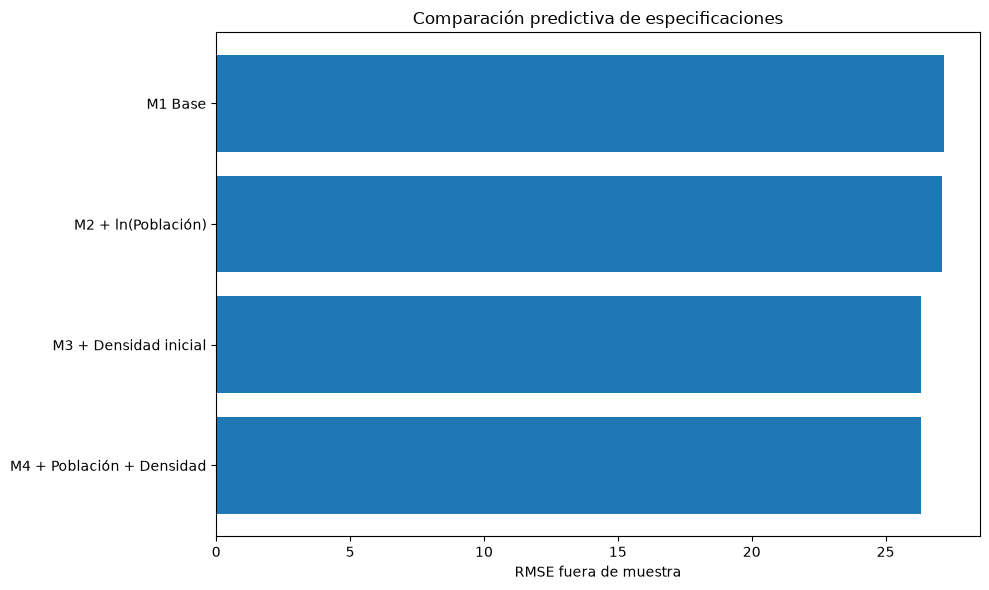

Gráfica guardada en: c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas_Regresion_multiple\comparacion_rmse_especificaciones_ampliadas.png


In [157]:
# ============================================================
# 17.15.1 Comparación gráfica de RMSE
# ============================================================

orden_plot = (
    tabla_seleccion_17[
        [
            "Modelo",
            "RMSE test"
        ]
    ]
    .sort_values(
        "RMSE test"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    orden_plot["Modelo"],
    orden_plot["RMSE test"]
)

ax.set_xlabel(
    "RMSE fuera de muestra"
)

ax.set_title(
    "Comparación predictiva de especificaciones"
)

plt.tight_layout()

ruta_rmse_especificaciones = (
    OUTPUT_DIR /
    "comparacion_rmse_especificaciones_ampliadas.png"
)

plt.savefig(
    ruta_rmse_especificaciones,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Gráfica guardada en: "
    f"{ruta_rmse_especificaciones}"
)

## 17.16. Limitaciones de las especificaciones ampliadas

La incorporación de población y densidad comercial inicial permite evaluar si el tamaño municipal y las condiciones comerciales de partida aportan información adicional al modelo socioeconómico base.

Sin embargo, estos controles presentan una limitación importante. La variable dependiente se construye a partir de las densidades comerciales de 2020 y 2025, y la densidad de 2020 depende a su vez de la población y del número de establecimientos iniciales.

Por esta razón, densidad inicial y población de 2020 no pueden considerarse completamente independientes de la construcción de la variable dependiente.

Una eventual mejora importante del ajuste, especialmente al incorporar densidad inicial, deberá interpretarse parcialmente como evidencia de un efecto de base o de estructura matemática de la variable de crecimiento.

En consecuencia, los modelos ampliados cumplen principalmente una función de sensibilidad y control. Para desarrollar una especificación sustantivamente más rica sería preferible incorporar en trabajos posteriores variables adicionales de 2020 que no formen parte de la construcción de la variable dependiente, como ingreso, urbanización, empleo formal, estructura productiva o accesibilidad territorial.

In [158]:
# ============================================================
# FASE 18 — RESUMEN EJECUTIVO FINAL
# ============================================================

resumen_final = pd.DataFrame({
    "Aspecto": [
        "Muestra",
        "Modelo principal",
        "R² modelo principal",
        "R² ajustado principal",
        "VIF máximo",
        "Prueba BP/Koenker",
        "Durbin-Watson",
        "RMSE test principal",
        "MAE test principal",
        "R² test principal",
        "WAPE principal",
        "Cobertura IP95",
        "Ancho medio IP95",
        "Modelo ampliado preferido",
        "R² ajustado ampliado",
        "R² test ampliado",
        "RMSE test ampliado"
    ],

    "Resultado": [
        "2,440 municipios",
        "M1 — 4 predictores socioeconómicos",
        0.0215,
        0.0199,
        3.3217,
        "p = 0.5623",
        1.9100,
        27.1673,
        14.7159,
        0.0293,
        "74.1335%",
        "96.5164%",
        95.2049,
        "M3 — Base + densidad inicial",
        0.0650,
        0.0879,
        26.3346
    ]
})

display(resumen_final)

,Aspecto,Resultado
0,Muestra,"2,440 municipios"
1,Modelo principal,M1 — 4 predictores socioeconómicos
2,R² modelo principal,0.0215
3,R² ajustado principal,0.0199
4,VIF máximo,3.3217
5,Prueba BP/Koenker,p = 0.5623
6,Durbin-Watson,1.9100
7,RMSE test principal,27.1673
8,MAE test principal,14.7159
9,R² test principal,0.0293
